# ***Análisis Exploratorio de Indicadores de Salud y Factores Asociados a enfermedades cardíacas en la encuesta de BRFSS 2015***

## ***Introducción***


Las enfermedades cardíacas representan la principal causa de muerte en Estados Unidos, cobrando aproximadamente 647.000 vidas cada año y generando una de las mayores cargas económicas y sanitarias del país. A diferencia de otras enfermedades, la cardiopatía coronaria avanza de forma silenciosa: la acumulación de placa en las arterias, la inflamación crónica, la hipertensión y la diabetes deterioran el sistema cardiovascular durante años antes de que aparezca cualquier síntoma visible. La mayoría de las personas solo descubren que padecen una cardiopatía cuando ya ocurre un evento grave, como un infarto de miocardio o un paro cardíaco súbito.

La situación se agrava con una tendencia preocupante en la población joven. Un estudio reciente de la American Heart Association reportó que las muertes hospitalarias por infarto severo en adultos menores de 55 años aumentaron un 57% entre 2011 y 2022, analizando casi un millón de hospitalizaciones. Las mujeres jóvenes presentaron tasas de mortalidad más altas que los hombres del mismo grupo etario, frecuentemente asociadas a factores no tradicionales como los bajos ingresos, lo que subraya la necesidad de herramientas de detección temprana más amplias e integrales.

En este contexto, las encuestas poblacionales de salud representan una fuente valiosa de información. El Sistema de Vigilancia de Factores de Riesgo Conductuales (BRFSS), administrado anualmente por el CDC desde 1984, recoge respuestas de más de 400.000 estadounidenses sobre conductas de riesgo, enfermedades crónicas y uso de servicios preventivos. El dataset empleado en este análisis corresponde a la versión depurada del BRFSS 2015, con 253.680 registros y 21 variables que incluyen indicadores como el índice de masa corporal, actividad física, tabaquismo, consumo de alcohol, presión arterial, colesterol, diabetes, acceso a atención médica y características sociodemográficas.

## ***Objetivo general***


Examinar, a través de técnicas de análisis exploratorio y modelado predictivo, qué factores conductuales, clínicos y sociodemográficos presentan mayor asociación con el riesgo de enfermedad cardíaca en adultos estadounidenses, detectando patrones, contrastes entre grupos y construyendo un clasificador capaz de predecir la presencia de la enfermedad a partir de respuestas de encuesta poblacional.

### ***Objetivos especificos***
- Describir la distribución de las variables clínicas, conductuales y sociodemográficas presentes en el conjunto de datos BRFSS 2015, identificando frecuencias, proporciones y posibles valores atípicos.
- Analizar el desbalance de clases en la variable objetivo (HeartDiseaseorAttack) y evaluar su implicación para el análisis y la futura modelación.
- Examinar la relación entre los factores de riesgo cardiovascular —como hipertensión, colesterol elevado, tabaquismo, diabetes e índice de masa corporal— y la presencia de enfermedad cardíaca en la población encuestada.
- Comparar el perfil de salud y los hábitos de vida entre individuos con y sin enfermedad cardíaca, identificando contrastes estadísticamente relevantes entre ambos grupos.
- Construir y comparar modelos de clasificación supervisada para predecir el riesgo de enfermedad cardíaca, seleccionando el modelo con mayor capacidad de detección de casos positivos.

## ***Marco Teórico***

### *Enfermedades cardíacas e insuficiencia cardíaca*

La insuficiencia cardíaca es un trastorno en el que el corazón es incapaz de satisfacer las demandas del organismo, lo que genera una reducción del flujo sanguíneo y congestión en venas y pulmones. Puede originarse por causas directas —como el debilitamiento o rigidez del músculo cardíaco— o indirectas, producto de condiciones como la hipertensión arterial, la diabetes o valvulopatías. En muchos casos, los síntomas como la disnea y el cansancio se desarrollan gradualmente, lo que dificulta su detección temprana y refuerza la importancia de la vigilancia poblacional continua.

### *El sistema BRFSS como fuente de datos*

El Sistema de Vigilancia de Factores de Riesgo Conductuales (BRFSS) es el principal sistema nacional de encuestas telefónicas sobre salud en Estados Unidos, administrado por los CDC desde 1984. Recopila datos en los 50 estados, el Distrito de Columbia y territorios participantes, con más de 400.000 entrevistas a adultos cada año, siendo el sistema de encuestas telefónicas de salud continua más grande del mundo. Su objetivo es monitorear conductas de riesgo, enfermedades crónicas, acceso a atención médica y uso de servicios preventivos, convirtiéndose en una herramienta clave para la planificación de políticas de salud pública a nivel estatal y local.


### *Análisis exploratorio de datos (EDA)*

El análisis exploratorio de datos (EDA, por sus siglas en inglés) es un enfoque metodológico que permite examinar conjuntos de datos para resumir sus características principales, descubrir patrones, detectar anomalías y evaluar supuestos antes de aplicar técnicas de modelado formal. Desarrollado por el matemático John Tukey en la década de 1970, el EDA emplea principalmente métodos de visualización estadística para revelar relaciones entre variables y orientar decisiones sobre el análisis posterior. En el contexto de datos de salud, resulta especialmente valioso para identificar factores de riesgo relevantes y comprender la estructura del problema antes de construir modelos predictivos.

### *Métricas estadísticas por utilizar*
- Chi-cuadrado (χ²) es una prueba de hipótesis que evalúa si existe una asociación estadísticamente significativa entre dos variables categóricas. Compara las frecuencias observadas en una tabla de contingencia contra las que se esperarían si las variables fueran independientes. En este análisis se aplica para determinar si cada variable binaria u ordinal tiene una relación no aleatoria con la variable objetivo HeartDiseaseorAttack.
- V de Cramér es una medida de efecto derivada del estadístico Chi-cuadrado, normalizada en un rango de 0 a 1, donde 0 indica ausencia total de asociación y 1 asociación perfecta. Se utiliza porque Chi-cuadrado por sí solo no informa la magnitud de la relación —solo su significancia—, y porque la V de Cramér permite comparar la fuerza de asociación entre variables con diferente número de categorías.
- Mann-Whitney U es una prueba no paramétrica que compara las distribuciones de una variable continua entre dos grupos independientes, sin asumir normalidad. 
- Correlación de Pearson (r) mide la fuerza y dirección de la relación lineal entre dos variables numéricas, en un rango de −1 a 1. Se utiliza como medida complementaria para las variables continuas y como resumen global de la asociación de todas las variables con la variable objetivo, permitiendo identificar de forma rápida qué predictores se relacionan positiva o negativamente con el riesgo cardíaco.

### *Algoritmo KNN*
El algoritmo de k-nearest neighbors (KNN) es un clasificador de aprendizaje supervisado no paramétrico, que emplea la proximidad para realizar clasificaciones o predicciones sobre la agrupación de un punto de datos individual. Es uno de los clasificadores de clasificación y regression más populares y sencillos que se emplean actualmente en machine learning.
Si bien el algoritmo KNN se puede usar para problemas de regresión o clasificación, generalmente se usa como un algoritmo de clasificación, partiendo del supuesto de que se pueden encontrar puntos similares cerca uno del otro.

### *Random forest*
Random forest, o bosque aleatorio, es un algoritmo de aprendizaje automático registrado por Leo Breiman y Adele Cutler que combina los resultados de múltiples árboles de decisión para producir un único resultado más preciso; su facilidad de uso y flexibilidad lo han convertido en una herramienta popular tanto para problemas de clasificación como de regresión. Los árboles de decisión que lo componen funcionan haciendo una serie de preguntas que dividen los datos en nodos hasta llegar a una decisión final en el nodo hoja, y se entrenan típicamente mediante el algoritmo CART, usando métricas como la impureza de Gini, la ganancia de información o el error cuadrático medio para evaluar la calidad de cada división. Aunque los árboles de decisión individuales son propensos a sesgos y sobreajuste, cuando se combinan en un bosque aleatorio con árboles no correlacionados entre sí, el conjunto logra predicciones significativamente más precisas y robustas.

### *Máquinas de vectores de soporte (SVM)*
Una máquina de vectores de soporte (SVM) es un algoritmo de machine learning supervisado desarrollado por Vladimir N. Vapnik y sus colegas en la década de 1990, que clasifica los datos buscando un hiperplano óptimo que maximice la distancia entre clases en un espacio N-dimensional; cuando los datos son linealmente separables, este hiperplano puede ser una línea en 2D o un plano en dimensiones superiores, y los puntos de datos más cercanos a él se denominan vectores de soporte, pues son los que determinan el margen máximo. Dado que maximizar dicho margen permite al modelo generalizar mejor ante datos nuevos, las SVM son especialmente valoradas por su precisión en tareas de clasificación. Cuando los datos no son separables linealmente, se recurre al llamado "truco de kernel", que consiste en aplicar funciones de núcleo —como los kernels lineal, polinómico, RBF o sigmoide— para transformar los datos a un espacio de mayor dimensión donde sí sea posible separar las clases linealmente, lo que convierte a las SVM en un algoritmo versátil capaz de abordar tanto problemas lineales como no lineales.

### *Regresión logística*
La regresión logística es un algoritmo de machine learning supervisado que, a diferencia de predecir valores continuos, se enfoca en clasificar resultados discretos o categóricos —como determinar si un préstamo es aprobado o no según variables como ingresos, ahorros y puntuación crediticia— lo que la convierte en uno de los algoritmos de clasificación más utilizados tanto en machine learning como en inteligencia artificial. Sus fundamentos matemáticos siguen siendo relevantes incluso en la era de la IA generativa, donde desempeñan un papel importante en la orquestación de modelos complejos de redes neuronales, y también mantiene vigencia en la investigación en ciencias sociales y del comportamiento como herramienta de análisis estadístico. Su implementación es accesible y práctica, pudiendo realizarse fácilmente a través del módulo scikit-learn en Python.

### *XGBoost*

XGBoost (eXtreme Gradient Boosting) es una biblioteca de aprendizaje automático de código abierto basada en árboles de decisión potenciados mediante gradiente, destacada por su alta velocidad, eficiencia y capacidad de escalabilidad en grandes volúmenes de datos. Entre sus principales características se encuentran la computación paralela y distribuida, un algoritmo optimizado que aprovecha la memoria caché para acelerar el procesamiento, la regularización integrada que mejora el rendimiento del modelo y la capacidad de manejar valores faltantes de forma eficiente, lo que la convierte en una herramienta robusta para problemas de aprendizaje supervisado.

### *Clases desequilibradas*

Los problemas de clasificación con clases desequilibradas (imbalanced data) ocurren cuando en un conjunto de datos una o más clases tienen muchas menos muestras que otras, como sucede en casos de detección de enfermedades o fraude, donde predominan los ejemplos negativos frente a pocos positivos. Este desbalance afecta el aprendizaje de los modelos, ya que tienden a favorecer la clase mayoritaria y a ignorar la minoritaria, lo que puede generar resultados engañosos, como altas tasas de acierto general pero bajo rendimiento en la detección de los casos más importantes.

### *Validación cruzada estratificada (k-fold)*

La validación cruzada K-fold estratificada es una técnica de evaluación de modelos que mantiene la proporción original de las clases en cada partición del conjunto de datos, lo que resulta especialmente útil en problemas de clasificación con datos desbalanceados. A diferencia de la división aleatoria tradicional, que puede generar conjuntos de entrenamiento y prueba con distribuciones desiguales, esta técnica asegura que cada pliegue refleje adecuadamente las clases, evitando resultados engañosos y permitiendo obtener métricas más confiables y representativas del desempeño real del modelo.

### *Pipeline*

Un pipeline de machine learning es un flujo de trabajo estructurado que organiza las etapas necesarias para desarrollar y poner en funcionamiento un modelo de aprendizaje automático de manera eficiente. Este proceso incluye tres fases principales: el procesamiento de datos (recolección, limpieza y preparación), el desarrollo del modelo (selección, entrenamiento y validación del algoritmo) y el despliegue (integración en producción y monitoreo). Los pipelines facilitan la automatización y gestión de estas etapas, siendo fundamentales dentro de las prácticas de MLOps.

### *La curva ROC (Receiver Operating Characteristic) y el AUC (Área Bajo la Curva)*

La curva ROC (Receiver Operating Characteristic) y el AUC (Área Bajo la Curva) son herramientas clave para evaluar modelos de clasificación binaria, ya que permiten analizar su rendimiento a través de distintos umbrales de decisión. Mientras que métricas como precisión o F1 se calculan en un único umbral, el AUC-ROC mide la capacidad del modelo para distinguir entre clases considerando todos los posibles umbrales, lo que lo hace especialmente útil en conjuntos de datos desbalanceados y en la comparación de distintos modelos.

### *Threshold tuning*

El threshold tuning (ajuste de umbral) es el proceso de modificar los valores límite que determinan cuándo se activa una decisión o alerta en un sistema o modelo, con el fin de optimizar su rendimiento. En el contexto de machine learning, implica ajustar el punto de corte de clasificación para equilibrar métricas como precisión y recall según las necesidades del problema. En sistemas como OMEGAMON, también se utiliza para controlar la recolección de datos y el uso de recursos, permitiendo definir distintos niveles de alerta (como advertencias o estados críticos) y mejorar la eficiencia operativa.



## ***Metodologías de los análisis***
Para alcanzar los objetivos propuestos, vamos a seguir dos metodologías según el tipo de análisis que se realizará, a continuación explicamos cuáles son estas dos metodologías: 
- ### ***Metodología del análisis univariado***
El análisis univariado se realizará según la naturaleza estadística de cada variable, aplicando técnicas descriptivas diferenciadas para tres grupos.

- **Variables binarias**: Se calcularán frecuencias absolutas y relativas con `value_counts()`, visualizadas en gráficos de barras verticales con el porcentaje anotado sobre cada barra. Cada gráfico fue seguido de una interpretación narrativa con énfasis clínico.
- **Variables ordinales**: Mismo cálculo de frecuencias, pero representadas con barras horizontales para acomodar las etiquetas. Se busca preservar el orden natural de las categorías y se usarán paletas diferenciadas por nivel para reforzar el carácter ordinal de la escala.
- **Variables continuas**: Se construirá una tabla descriptiva con media, mediana, desviación estándar, cuartiles, IQR y conteo de outliers por criterio de Tukey. La visualización varia según la variable: BMI se graficará con histograma de 50 bins con líneas de media y mediana superpuestas; MentHlth y PhysHlth, al tomar valores enteros de 0 a 30, se representarán con barras por valor exacto para identificar picos y concentración en el cero.

### ***Metodología del Análisis Bivariado***

Para examinar la relación entre cada variable predictora y la variable objetivo `HeartDiseaseorAttack`, se emplean tres estrategias según el tipo estadístico de la variable:

- **Variables binarias y ordinales → Chi-cuadrado + V de Cramér**: La prueba χ² evalúa si existe asociación estadísticamente significativa; la V de Cramér cuantifica la magnitud de dicha asociación en un rango [0, 1].  

- **Variables continuas → Mann-Whitney U**: Dado el sesgo pronunciado de BMI, MentHlth y PhysHlth, la prueba no paramétrica de Mann-Whitney es más robusta que la t de Student para comparar las distribuciones entre los dos grupos de la variable objetivo.  

- **Tasas de incidencia por grupo**: Se calcula el porcentaje de personas con enfermedad cardíaca dentro de cada categoría, ofreciendo una interpretación clínica directa.  

- **Mapa de calor de correlaciones de Pearson**: Como síntesis visual de la fuerza lineal de asociación de todas las variables con el target.

### ***Metodología de la selección del modelo***

Para la etapa de modelado predictivo se implementó un pipeline reproducible que integra preprocesamiento y clasificación en un único objeto, garantizando que ninguna transformación sobre los datos de entrenamiento contamine el conjunto de test. El preprocesamiento aplicó MinMaxScaler exclusivamente a las tres variables continuas (BMI, MentHlth, PhysHlth), dejando las variables binarias y ordinales sin transformación dado que ya se encuentran en escalas numéricas naturales. Se evaluaron cinco algoritmos de clasificación: Regresión Logística, Random Forest, K-Nearest Neighbors, Linear SVC y XGBoost. Para compensar el desbalance de clases (90.6% vs 9.4%), se aplicó class_weight="balanced" en los modelos de scikit-learn y scale_pos_weight=9.62 en XGBoost. 

La búsqueda de hiperparámetros se realizó con GridSearchCV de 5 folds estratificados optimizando el Recall, dado que en un contexto de detección preventiva el error más costoso es no identificar a un paciente enfermo. La evaluación final se realizó sobre un conjunto de test estratificado del 20% con las métricas Accuracy, Precision, Recall, F1 y AUC-ROC. Adicionalmente se analizó el trade-off entre Recall y Precision mediante threshold tuning y se compararon los modelos con curvas ROC y curvas Precision-Recall.

## ***1. Carga y estructura del dataset***


In [5]:
# Librerías importantes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
nude_palette = ["#C0392B", "#2C3E6B"]


# 1. CARGA DE DATOS
df = pd.read_csv("C:/Users/MSI TRUE GAMING/Desktop/Semestre 2026/viz/EDA_heartorigin/heart_disease_health_indicators_BRFSS2015.csv")

# visualización inicial
#print("Shape:", df.shape)
#print("\nPrimeras filas:")
#df.head()

In [6]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

El dataset cargado contiene 253.680 registros y 22 variables resultado del proceso de limpieza y selección aplicado sobre el BRFSS 2015 original de 441.456 filas y 330 columnas. De las 22 variables, 1 corresponde a la variable objetivo (HeartDiseaseorAttack) y las 21 restantes representan los factores de riesgo seleccionados, distribuidos entre variables binarias (como HighBP, Smoker o Stroke), variables ordinales (GenHlth, Age, Education, Income) y variables continuas (BMI, MentHlth, PhysHlth).

### ***1.1 Estructura***


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

El hecho de que todas sean float64 es solo el formato de almacenamiento, no su naturaleza estadística. Por ejemplo, Sex toma valores 0 y 1, lo que la hace nominal, no continua; Age va de 1 a 13 en categorías ordenadas, lo que la hace ordinal; y BMI sí es una medida continua real. Clasificarlas correctamente es importante porque determina qué tipo de visualizaciones y estadísticas aplicar en el EDA.

#### ***1.2 Definir variables numéricas, binarias y ordinales***

Se realizará la correcta clasificación conceptual en los tres grupos: numéricas, binarias y ordinales. Esto evitará interprestaciones incorrectas y la selección de graficos adecuados.

In [8]:
# Clasificación de variables por tipo estadístico

target = ['HeartDiseaseorAttack']

binary_vars = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
    'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

ordinal_vars = ['GenHlth', 'Age', 'Education', 'Income', 'Diabetes']

continuous_vars = ['BMI', 'MentHlth', 'PhysHlth']

print("Variable objetivo   :", target)
print("Binarias            :", binary_vars)
print("Ordinales           :", ordinal_vars)
print("Continuas           :", continuous_vars)
print("\nTotal variables clasificadas:", len(target) + len(binary_vars) + len(ordinal_vars) + len(continuous_vars))

Variable objetivo   : ['HeartDiseaseorAttack']
Binarias            : ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Ordinales           : ['GenHlth', 'Age', 'Education', 'Income', 'Diabetes']
Continuas           : ['BMI', 'MentHlth', 'PhysHlth']

Total variables clasificadas: 22


#### ***1.3 Conversión***

In [9]:
df_1 = df.copy()

#  1. Variable objetivo 
df_1["HeartDiseaseorAttack"] = df_1["HeartDiseaseorAttack"].map({
    0: "Sin enfermedad cardíaca",
    1: "Con enfermedad cardíaca"
}).astype("category")

#  2. Variables binarias 
binary_mappings = {
    "HighBP":             {0: "Sin hipertensión",          1: "Con hipertensión"},
    "HighChol":           {0: "Sin colesterol alto",        1: "Con colesterol alto"},
    "CholCheck":          {0: "Sin chequeo en 5 años",      1: "Con chequeo en 5 años"},
    "Smoker":             {0: "No fumador",                 1: "Fumador"},
    "Stroke":             {0: "Sin ACV",                    1: "Con ACV"},
    "PhysActivity":       {0: "Sin actividad física",       1: "Con actividad física"},
    "Fruits":             {0: "No consume frutas diario",   1: "Consume frutas diario"},
    "Veggies":            {0: "No consume verduras diario", 1: "Consume verduras diario"},
    "HvyAlcoholConsump":  {0: "No consumo alto alcohol",    1: "Consumo alto alcohol"},
    "AnyHealthcare":      {0: "Sin cobertura médica",       1: "Con cobertura médica"},
    "NoDocbcCost":        {0: "Sin barrera económica",      1: "Con barrera económica"},
    "DiffWalk":           {0: "Sin dificultad al caminar",  1: "Con dificultad al caminar"},
    "Sex":                {0: "Mujer",                      1: "Hombre"},
}

for col, mapping in binary_mappings.items():
    df_1[col] = df_1[col].map(mapping).astype("category")

#  3. Diabetes (ordinal 3 niveles) 
df_1["Diabetes"] = df_1["Diabetes"].map({
    0: "Sin diabetes",
    1: "Prediabetes",
    2: "Diabetes confirmada"
}).astype("category")

df_1["Diabetes"] = df_1["Diabetes"].cat.reorder_categories(
    ["Sin diabetes", "Prediabetes", "Diabetes confirmada"],
    ordered=True
)

#  4. GenHlth (ordinal 1–5) 
df_1["GenHlth"] = df_1["GenHlth"].map({
    1: "Excelente",
    2: "Muy buena",
    3: "Buena",
    4: "Regular",
    5: "Mala"
}).astype("category")

df_1["GenHlth"] = df_1["GenHlth"].cat.reorder_categories(
    ["Excelente", "Muy buena", "Buena", "Regular", "Mala"],
    ordered=True
)

#  5. Age (ordinal 1–13) 
age_mapping = {
    1:  "18–24",
    2:  "25–29",
    3:  "30–34",
    4:  "35–39",
    5:  "40–44",
    6:  "45–49",
    7:  "50–54",
    8:  "55–59",
    9:  "60–64",
    10: "65–69",
    11: "70–74",
    12: "75–79",
    13: "80+"
}

df_1["Age"] = df_1["Age"].map(age_mapping).astype("category")
df_1["Age"] = df_1["Age"].cat.reorder_categories(
    list(age_mapping.values()),
    ordered=True
)

#  6. Education (ordinal 1–6) 
education_mapping = {
    1: "Nunca asistió",
    2: "Primaria incompleta",
    3: "Secundaria incompleta",
    4: "Secundaria completa",
    5: "Universidad incompleta",
    6: "Universidad completa"
}

df_1["Education"] = df_1["Education"].map(education_mapping).astype("category")
df_1["Education"] = df_1["Education"].cat.reorder_categories(
    list(education_mapping.values()),
    ordered=True
)

#  7. Income (ordinal 1–8) 
income_mapping = {
    1: "< $10,000",
    2: "$10,000–15,000",
    3: "$15,000–20,000",
    4: "$20,000–25,000",
    5: "$25,000–35,000",
    6: "$35,000–50,000",
    7: "$50,000–75,000",
    8: "$75,000+"
}

df_1["Income"] = df_1["Income"].map(income_mapping).astype("category")
df_1["Income"] = df_1["Income"].cat.reorder_categories(
    list(income_mapping.values()),
    ordered=True
)

#  Verificación 
print("Tipos de datos en df_1:")
print(df_1.dtypes)
print("\nValores únicos por variable categórica:")
cat_cols = df_1.select_dtypes("category").columns
for col in cat_cols:
    print(f"\n{col}: {list(df_1[col].cat.categories)}")

Tipos de datos en df_1:
HeartDiseaseorAttack    category
HighBP                  category
HighChol                category
CholCheck               category
BMI                      float64
Smoker                  category
Stroke                  category
Diabetes                category
PhysActivity            category
Fruits                  category
Veggies                 category
HvyAlcoholConsump       category
AnyHealthcare           category
NoDocbcCost             category
GenHlth                 category
MentHlth                 float64
PhysHlth                 float64
DiffWalk                category
Sex                     category
Age                     category
Education               category
Income                  category
dtype: object

Valores únicos por variable categórica:

HeartDiseaseorAttack: ['Con enfermedad cardíaca', 'Sin enfermedad cardíaca']

HighBP: ['Con hipertensión', 'Sin hipertensión']

HighChol: ['Con colesterol alto', 'Sin colesterol alto']

CholChec

#### ***1.4 Diccionario de los datos***

El diccionario de variables es un paso fundamental en cualquier análisis exploratorio, ya que documenta de forma clara y estructurada el significado, tipo estadístico y valores posibles de cada variable del dataset.

In [10]:
# Diccionario de variables
variable_info = {
    "HeartDiseaseorAttack": {"tipo": "Binaria (objetivo)", "escala": "0 / 1", "descripcion": "Reportó enfermedad coronaria o infarto"},
    "HighBP":               {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Diagnóstico de presión arterial alta"},
    "HighChol":             {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Diagnóstico de colesterol alto"},
    "CholCheck":            {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Revisión de colesterol en últimos 5 años"},
    "BMI":                  {"tipo": "Continua",           "escala": "12 – 98", "descripcion": "Índice de masa corporal"},
    "Smoker":               {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Fumó al menos 100 cigarrillos en su vida"},
    "Stroke":               {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Diagnóstico de derrame cerebral (ACV)"},
    "Diabetes":             {"tipo": "Ordinal (3 niveles)","escala": "0 / 1 / 2", "descripcion": "0=Sin diabetes · 1=Prediabetes · 2=Diabetes confirmada"},
    "PhysActivity":         {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Realizó actividad física en últimos 30 días"},
    "Fruits":               {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Consume frutas 1 o más veces al día"},
    "Veggies":              {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Consume verduras 1 o más veces al día"},
    "HvyAlcoholConsump":    {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Consumo excesivo de alcohol"},
    "AnyHealthcare":        {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Tiene cobertura o seguro médico"},
    "NoDocbcCost":          {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "No fue al médico en el último año por costo"},
    "GenHlth":              {"tipo": "Ordinal",            "escala": "1–5", "descripcion": "Autopercepción de salud general (1=Excelente · 5=Mala)"},
    "MentHlth":             {"tipo": "Continua",           "escala": "0–30 días", "descripcion": "Días con mala salud mental en el último mes"},
    "PhysHlth":             {"tipo": "Continua",           "escala": "0–30 días", "descripcion": "Días con mala salud física en el último mes"},
    "DiffWalk":             {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "Dificultad seria para caminar o subir escaleras"},
    "Sex":                  {"tipo": "Binaria",            "escala": "0 / 1", "descripcion": "0 = Mujer · 1 = Hombre"},
    "Age":                  {"tipo": "Ordinal",            "escala": "1–13", "descripcion": "Grupo etario en intervalos de 5 años (1=18–24 · 13=80+)"},
    "Education":            {"tipo": "Ordinal",            "escala": "1–6", "descripcion": "Nivel educativo (1=Sin escolaridad · 6=Universitario)"},
    "Income":               {"tipo": "Ordinal",            "escala": "1–8", "descripcion": "Ingreso anual del hogar (1=<$10k · 8=≥$75k)"},
}

dict_df = pd.DataFrame(variable_info).T.reset_index()
dict_df.columns = ["Variable", "Tipo", "Escala", "Descripción"]

display(dict_df.style.hide(axis="index"))

Variable,Tipo,Escala,Descripción
HeartDiseaseorAttack,Binaria (objetivo),0 / 1,Reportó enfermedad coronaria o infarto
HighBP,Binaria,0 / 1,Diagnóstico de presión arterial alta
HighChol,Binaria,0 / 1,Diagnóstico de colesterol alto
CholCheck,Binaria,0 / 1,Revisión de colesterol en últimos 5 años
BMI,Continua,12 – 98,Índice de masa corporal
Smoker,Binaria,0 / 1,Fumó al menos 100 cigarrillos en su vida
Stroke,Binaria,0 / 1,Diagnóstico de derrame cerebral (ACV)
Diabetes,Ordinal (3 niveles),0 / 1 / 2,0=Sin diabetes · 1=Prediabetes · 2=Diabetes confirmada
PhysActivity,Binaria,0 / 1,Realizó actividad física en últimos 30 días
Fruits,Binaria,0 / 1,Consume frutas 1 o más veces al día


## ***2. Limpieza***


Antes de iniciar el análisis exploratorio, es fundamental verificar la integridad del dataset para garantizar que los datos se encuentren en condiciones óptimas. Aunque el conjunto de datos BRFSS 2015 ya fue sometido a un proceso de limpieza previo eliminando valores nulos, respuestas inválidas y recodificando las variables, se realizará una validación exhaustiva que confirme la ausencia de valores faltantes, registros duplicados y valores fuera del rango esperado para cada variable. Este paso asegura que los resultados del análisis sean confiables y reproducibles.

In [11]:
# 1. Valores nulos 
print("VALORES NULOS POR VARIABLE")
nulos = df.isnull().sum()
print(nulos)
print(f"\nTotal de valores nulos: {nulos.sum()}")

VALORES NULOS POR VARIABLE
HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total de valores nulos: 0


### ***2.1 Duplicados***


In [12]:
# 2. Registros duplicados
print("REGISTROS DUPLICADOS")
duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {duplicados}")

REGISTROS DUPLICADOS
Total de filas duplicadas: 23899


In [13]:
total = df.shape[0]
duplicados = df.duplicated().sum()
porcentaje = (duplicados / total) * 100

print(f"Total de registros    : {total:,}")
print(f"Registros duplicados  : {duplicados:,}")
print(f"Porcentaje            : {porcentaje:.2f}%")

Total de registros    : 253,680
Registros duplicados  : 23,899
Porcentaje            : 9.42%


Tras la verificación de integridad del dataset, se confirmó la ausencia total de valores nulos en las 22 variables, resultado consistente con el proceso de limpieza previo aplicado sobre el BRFSS 2015. En cuanto a los 23.899 registros identificados como duplicados, se tomó la decisión de mantenerlos en el análisis. Esta decisión se fundamenta en la naturaleza del dataset: al tratarse de una encuesta poblacional con mayoría de variables binarias, es estadísticamente esperable que múltiples individuos compartan exactamente el mismo perfil de respuestas sin que esto represente un error de captura. Eliminar estos registros implicaría descartar observaciones legítimas de personas reales, lo que podría introducir sesgos en la distribución de la muestra y afectar la representatividad del análisis. Por tanto, el dataset continúa con sus 253.680 registros originales, listos para el análisis exploratorio.

### ***2.2 Verificación de rangos esperados***

In [14]:
# Verificación de rangos esperados por variable 

rangos_esperados = {
    "HeartDiseaseorAttack": (0, 1),
    "HighBP":               (0, 1),
    "HighChol":             (0, 1),
    "CholCheck":            (0, 1),
    "BMI":                  (12, 98),
    "Smoker":               (0, 1),
    "Stroke":               (0, 1),
    "Diabetes":             (0, 2),
    "PhysActivity":         (0, 1),
    "Fruits":               (0, 1),
    "Veggies":              (0, 1),
    "HvyAlcoholConsump":    (0, 1),
    "AnyHealthcare":        (0, 1),
    "NoDocbcCost":          (0, 1),
    "GenHlth":              (1, 5),
    "MentHlth":             (0, 30),
    "PhysHlth":             (0, 30),
    "DiffWalk":             (0, 1),
    "Sex":                  (0, 1),
    "Age":                  (1, 13),
    "Education":            (1, 6),
    "Income":               (1, 8),
}

print(f"{'Variable':<25} {'Min esp':>8} {'Max esp':>8} {'Min real':>10} {'Max real':>10} ")

todos_ok = True
for col, (min_esp, max_esp) in rangos_esperados.items():
    min_real = df[col].min()
    max_real = df[col].max()
    ok = (min_real >= min_esp) and (max_real <= max_esp)
    if not ok:
        todos_ok = False
    print(f"{col:<25} {min_esp:>8} {max_esp:>8} {min_real:>10.1f} {max_real:>10.1f} ")

if todos_ok:
    print("Todas las variables están dentro del rango esperado.")
else:
    print("Hay variables fuera de rango. Revisar las marcadas con ✗")

Variable                   Min esp  Max esp   Min real   Max real 
HeartDiseaseorAttack             0        1        0.0        1.0 
HighBP                           0        1        0.0        1.0 
HighChol                         0        1        0.0        1.0 
CholCheck                        0        1        0.0        1.0 
BMI                             12       98       12.0       98.0 
Smoker                           0        1        0.0        1.0 
Stroke                           0        1        0.0        1.0 
Diabetes                         0        2        0.0        2.0 
PhysActivity                     0        1        0.0        1.0 
Fruits                           0        1        0.0        1.0 
Veggies                          0        1        0.0        1.0 
HvyAlcoholConsump                0        1        0.0        1.0 
AnyHealthcare                    0        1        0.0        1.0 
NoDocbcCost                      0        1        0.0        

Las 22 variables del dataset se encuentran dentro de los rangos esperados, sin excepción. Cada variable binaria contiene únicamente los valores 0 y 1, las variables ordinales respetan sus escalas definidas (GenHlth de 1 a 5, Age de 1 a 13, Education de 1 a 6, Income de 1 a 8), Diabetes presenta sus tres niveles correctos (0, 1 y 2), y las variables continuas BMI, MentHlth y PhysHlth se mantienen dentro de límites clínicamente plausibles. Con esto se concluye que el dataset no presenta problemas de integridad y se encuentra en condiciones óptimas para proceder con el análisis exploratorio de datos.

### ***2.3 Análisis y tratamiento de datos atípicos***

El análisis de valores atípicos aplica únicamente a las variables continuas **BMI**, **MentHlth** y **PhysHlth**, ya que las variables binarias (0/1) y ordinales (escalas discretas acotadas) no pueden presentar outliers en el sentido estadístico del término. Se emplea el criterio de Tukey: un valor se considera atípico si cae por debajo de Q1 − 1.5·IQR o por encima de Q3 + 1.5·IQR.

In [15]:
# ── Detección de outliers con criterio de Tukey ──
continuous_vars = ['BMI', 'MentHlth', 'PhysHlth']

resumen_outliers = []
for v in continuous_vars:
    q1  = df[v].quantile(0.25)
    q3  = df[v].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_out = df[(df[v] < lo) | (df[v] > hi)].shape[0]
    resumen_outliers.append({
        "Variable"        : v,
        "Q1"              : q1,
        "Q3"              : q3,
        "IQR"             : iqr,
        "Límite inferior" : round(lo, 2),
        "Límite superior" : round(hi, 2),
        "N° datos atípicos"     : n_out,
        "% datos atípicos"      : round(n_out / len(df) * 100, 2)
    })

df_out = pd.DataFrame(resumen_outliers)
display(df_out.style.hide(axis="index"))


Variable,Q1,Q3,IQR,Límite inferior,Límite superior,N° datos atípicos,% datos atípicos
BMI,24.000000,31.000000,7.000000,13.500000,41.500000,9847,3.880000
MentHlth,0.000000,2.000000,2.000000,-3.000000,5.000000,36208,14.270000
PhysHlth,0.000000,3.000000,3.000000,-4.500000,7.500000,40949,16.140000


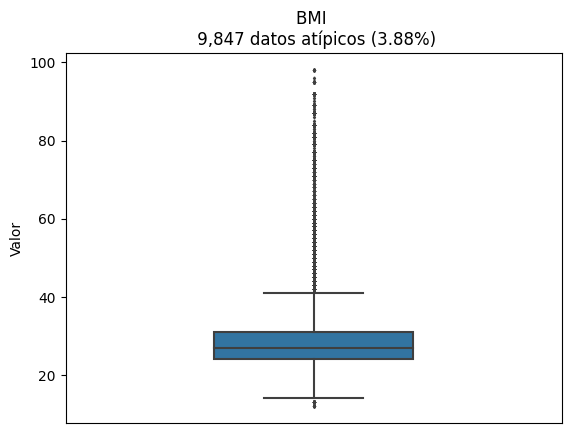

In [16]:
sns.boxplot(df['BMI'],fliersize=1.5,width=0.4)
n_out = df_out['N° datos atípicos'][0]
p_out = df_out['% datos atípicos'][0]
plt.title(f'BMI \n {n_out:,} datos atípicos ({p_out}%)')
plt.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
plt.ylabel('Valor');

BMI: Se detectaron 9.847 valores atípicos (3.88%). 
Los valores extremos superiores llegan hasta 98, que si bien son clínicamente posibles en casos de obesidad mórbida severa, 
representan una minoría del dataset.
De forma similar, los valores extremos inferiores llegan hasta 12, estos son casos raros aunque posibles y se ven en situaciones de desnutrición extrema.
Dado que son valores reales y no errores de registro, se conservan sin modificación 
para no distorsionar el análisis de un factor de riesgo cardiovascular relevante.


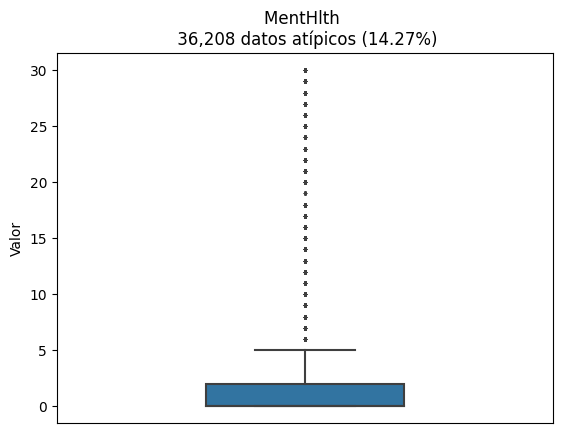

In [17]:
sns.boxplot(df['MentHlth'],fliersize=1.5,width=0.4)
n_out = df_out['N° datos atípicos'][1]
p_out = df_out['% datos atípicos'][1]
plt.title(f'MentHlth \n {n_out:,} datos atípicos ({p_out}%)')
plt.ylabel('Valor')
plt.tick_params(axis='x', which='both', bottom=False, labelbottom=False)


MentHlth Presenta un alto porcentaje de datos atípicos por criterio de Tukey (14.27%). 
Esto se debe a que esta variable tiene una distribución extremadamente asimétrica con mediana igual a 0: el IQR es 
muy pequeño (2 días), lo que hace que el límite superior de Tukey sea apenas 5 días. Sin embargo, 
valores como 10, 15 o 30 días de mala salud son respuestas legítimas de la encuesta y no constituyen errores. 
Se conservan sin tratamiento, ya que eliminarlos o imputarlos eliminaría información clínica valiosa sobre 
los grupos de mayor carga de enfermedad.

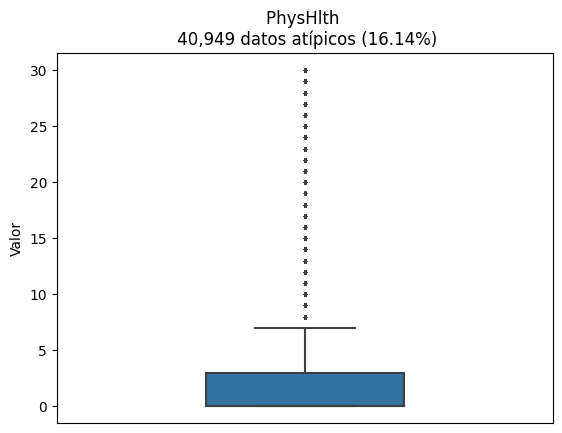

In [18]:
sns.boxplot(df['PhysHlth'],fliersize=1.5,width=0.4)
n_out = df_out['N° datos atípicos'][2]
p_out = df_out['% datos atípicos'][2]
plt.title(f'PhysHlth \n {n_out:,} datos atípicos ({p_out}%)')
plt.ylabel('Valor')
plt.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

PhysHlth: El caso de PhysHlth es muy similar alde MenHlth, en donde el porcentaje de datos atípicos es alto (16.14%) con una distribución muy asimétrica y media igual a 0, así como también cuenta con un IQR muy pequeño de 3 días, pero como con la variable anterior, una respuesta de como máximo 30 días de mala salud física sigue siendo algo posible dentro del contexto de los datos, por esta razón se conservan sin tratamientos.

Decisión general: No se aplica ningún tratamiento de eliminación ni imputación sobre los datos atípicos. La naturaleza 
de encuesta poblacional del BRFSS 2015 implica que los valores extremos corresponden a individuos reales con 
perfiles de salud severos. Su exclusión introduciría un sesgo de selección que afectaría la validez del análisis 
y la futura modelación predictiva.

## ***3. Analisis Univariado***


### ***3.1. Variable Objetivo***


#### ***3.1.1 HeartDiseaseorAttack: Enfermedad cardiaca***

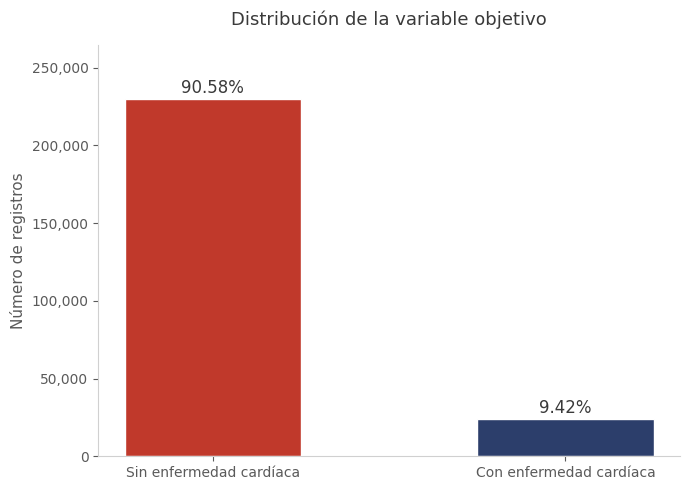

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
conteos = df["HeartDiseaseorAttack"].value_counts().sort_index()
etiquetas = ["Sin enfermedad cardíaca", "Con enfermedad cardíaca"]
porcentajes = (conteos / conteos.sum() * 100).round(2)
bars = ax.bar(etiquetas, conteos.values, color=nude_palette, width=0.5, edgecolor="white")

# Solo porcentaje encima de cada barra
for bar, pct in zip(bars, porcentajes):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1500,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de la variable objetivo", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_xlabel("")
ax.set_ylim(0, conteos.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

In [20]:
tabla_objetivo = pd.DataFrame({
    "Clase": ["Sin enfermedad cardíaca", "Con enfermedad cardíaca"],
    "Conteo": [conteos[0], conteos[1]],
})

display(tabla_objetivo.style.hide(axis="index"))

Clase,Conteo
Sin enfermedad cardíaca,229787
Con enfermedad cardíaca,23893


La variable objetivo HeartDiseaseorAttack presenta un marcado desbalance de clases: el 90.6% de los encuestados (229.787 personas) no reportó enfermedad cardíaca, frente a apenas el 9.42% (23.893 personas) que sí lo hizo. Este desbalance es un aspecto crítico a considerar en la etapa de modelado, ya que un clasificador podría alcanzar alta exactitud simplemente prediciendo siempre la clase mayoritaria, sin detectar realmente los casos positivos. Por ello, será necesario evaluar estrategias como el uso de métricas ajustadas (F1, AUC-ROC) y técnicas de balanceo como SMOTE o ajuste de pesos de clase.

### ***3.2. Variables binarias***


#### ***3.2.1 HighBP: Presión arterial alta***

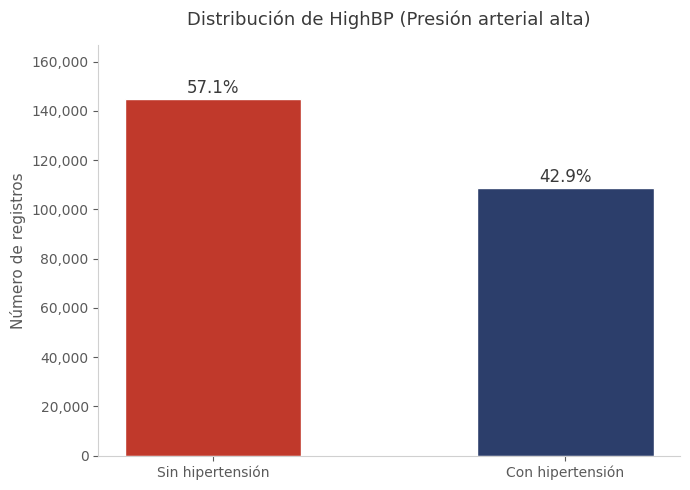

Clase,Conteo
Sin hipertensión,144851
Con hipertensión,108829


In [21]:
# HighBP 
conteos_bp = df["HighBP"].value_counts().sort_index()
etiquetas_bp = ["Sin hipertensión", "Con hipertensión"]
porcentajes_bp = (conteos_bp / conteos_bp.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_bp, conteos_bp.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_bp):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de HighBP (Presión arterial alta)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_bp.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_bp = pd.DataFrame({
    "Clase": etiquetas_bp,
    "Conteo": conteos_bp.values,
})
display(tabla_bp.style.hide(axis="index"))

El 57.1% de los encuestados (144.851 personas) no presenta hipertensión, mientras que el 42.9% (108.829 personas) sí ha recibido un diagnóstico de presión arterial alta. Esta distribución es notable: casi la mitad de la muestra convive con hipertensión, lo que es consistente con la evidencia clínica que la identifica como uno de los principales factores de riesgo cardiovascular.


#### ***3.2.2 HighChol: Colesterol alto***

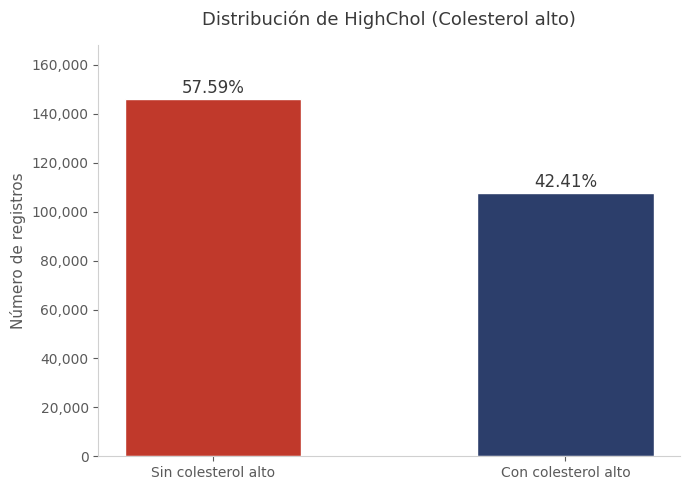

Clase,Conteo
Sin colesterol alto,146089
Con colesterol alto,107591


In [22]:
#  HighChol 
conteos_chol = df["HighChol"].value_counts().sort_index()
etiquetas_chol = ["Sin colesterol alto", "Con colesterol alto"]
porcentajes_chol = (conteos_chol / conteos_chol.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_chol, conteos_chol.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_chol):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de HighChol (Colesterol alto)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_chol.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_chol = pd.DataFrame({
    "Clase": etiquetas_chol,
    "Conteo": conteos_chol.values,
})
display(tabla_chol.style.hide(axis="index"))

El 57.59% de los encuestados (146.089 personas) no presenta colesterol alto, mientras que el 42.41% (107.591 personas) sí ha recibido un diagnóstico de colesterol elevado. La distribución es bastante similar a la observada en HighBP, con cerca de cuatro de cada diez participantes afectados.

#### ***3.2.3 CholCheck: Chequeo del colesterol***

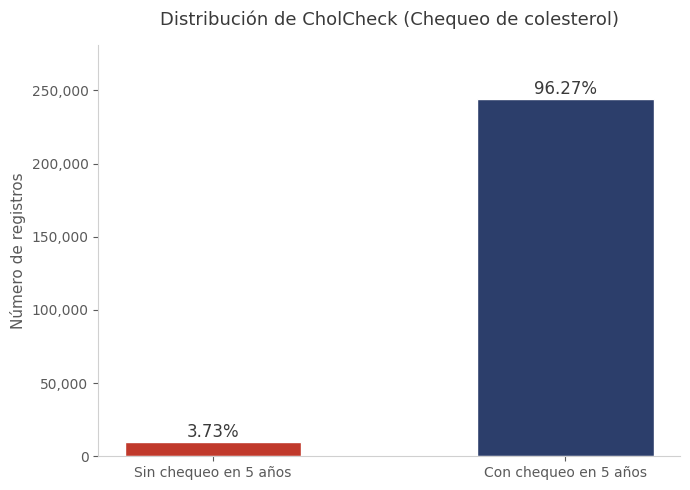

Clase,Conteo
Sin chequeo en 5 años,9470
Con chequeo en 5 años,244210


In [23]:
# CholCheck 
conteos_cc = df["CholCheck"].value_counts().sort_index()
etiquetas_cc = ["Sin chequeo en 5 años", "Con chequeo en 5 años"]
porcentajes_cc = (conteos_cc / conteos_cc.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_cc, conteos_cc.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_cc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de CholCheck (Chequeo de colesterol)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_cc.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_cc = pd.DataFrame({
    "Clase": etiquetas_cc,
    "Conteo": conteos_cc.values,
})
display(tabla_cc.style.hide(axis="index"))

El 96.27% de los encuestados (244.210 personas) se realizó un chequeo de colesterol en los últimos 5 años, mientras que apenas el 3.73% (9.470 personas) no lo hizo. Esta distribución es marcadamente asimétrica y refleja un alto nivel de acceso y adherencia a servicios preventivos de salud en la muestra.

#### ***3.2.4 Smoker: Fumador***

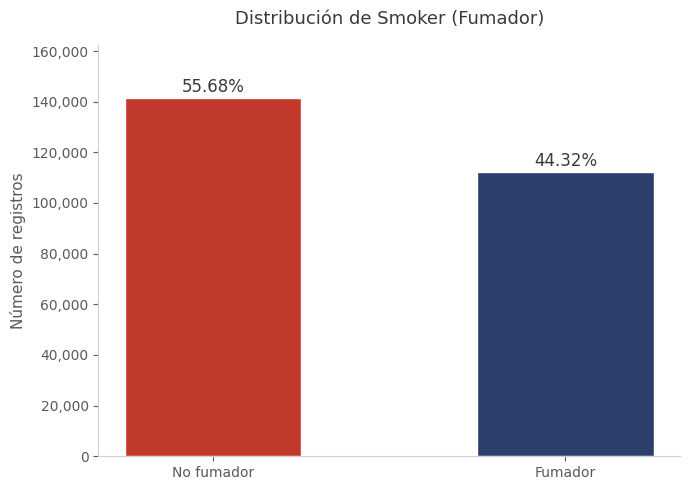

Clase,Conteo
No fumador,141257
Fumador,112423


In [24]:
# Smoker 
conteos_sm = df["Smoker"].value_counts().sort_index()
etiquetas_sm = ["No fumador", "Fumador"]
porcentajes_sm = (conteos_sm / conteos_sm.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_sm, conteos_sm.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_sm):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de Smoker (Fumador)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_sm.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_sm = pd.DataFrame({
    "Clase": etiquetas_sm,
    "Conteo": conteos_sm.values,
})
display(tabla_sm.style.hide(axis="index"))

El 55.68% de los encuestados (141.257 personas) nunca ha fumado en su vida, mientras que el 44.32% (112.423 personas) sí lo ha hecho. La distribución es relativamente equilibrada, con casi la mitad de la muestra clasificada como fumadora. Este hallazgo es relevante dado que el tabaquismo es uno de los tres factores de riesgo cardiovascular clave identificados por los CDC.

#### ***3.2.5 Stroke: Derrame cerebral***

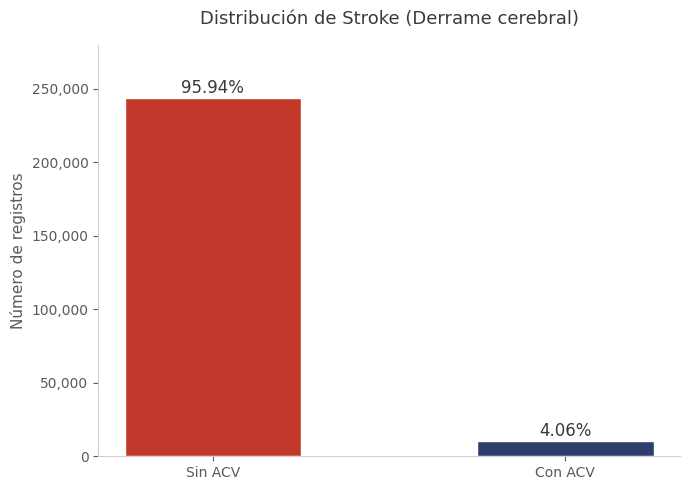

Clase,Conteo
Sin ACV,243388
Con ACV,10292


In [25]:
#  Stroke 
conteos_st = df["Stroke"].value_counts().sort_index()
etiquetas_st = ["Sin ACV", "Con ACV"]
porcentajes_st = (conteos_st / conteos_st.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_st, conteos_st.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_st):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de Stroke (Derrame cerebral)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_st.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_st = pd.DataFrame({
    "Clase": etiquetas_st,
    "Conteo": conteos_st.values,
})
display(tabla_st.style.hide(axis="index"))

El 95.94% de los encuestados (243.388 personas) no ha sufrido un derrame cerebral, mientras que apenas el 4.06% (10.292 personas) sí lo ha reportado. La distribución es muy similar a la observada en CholCheck, con una marcada concentración en la clase negativa. Aunque su baja prevalencia podría limitar su variabilidad como predictor individual, clínicamente el ACV y la enfermedad cardíaca comparten múltiples factores de riesgo.

#### ***3.2.6 PhysActivity: Actividad física***

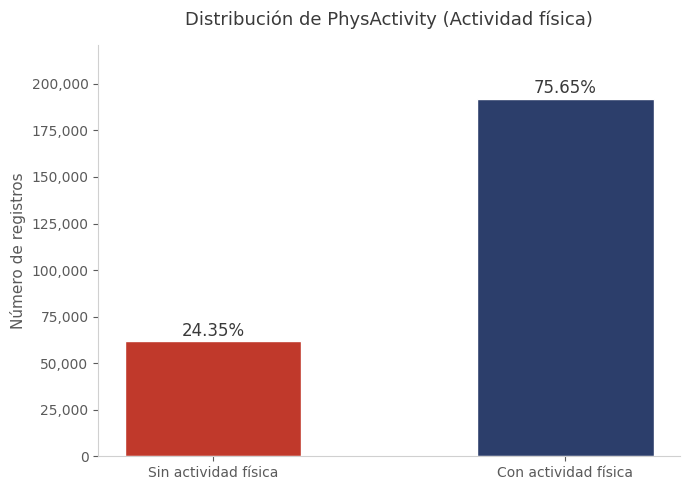

Clase,Conteo
Sin actividad física,61760
Con actividad física,191920


In [26]:
# PhysActivity 
conteos_pa = df["PhysActivity"].value_counts().sort_index()
etiquetas_pa = ["Sin actividad física", "Con actividad física"]
porcentajes_pa = (conteos_pa / conteos_pa.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_pa, conteos_pa.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_pa):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de PhysActivity (Actividad física)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_pa.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_pa = pd.DataFrame({
    "Clase": etiquetas_pa,
    "Conteo": conteos_pa.values,
})
display(tabla_pa.style.hide(axis="index"))

El 75.65% de los encuestados (191.920 personas) reportó haber realizado actividad física en los últimos 30 días, mientras que el 24.35% (61.760 personas) no lo hizo. La mayoría de la muestra mantiene algún nivel de actividad física, lo cual es un indicador positivo desde el punto de vista preventivo. Sin embargo, el cuarto de la población que no realiza ninguna actividad representa un grupo de interés, dado que el sedentarismo es reconocido como un factor de riesgo cardiovascular relevante. 

#### ***3.2.7 Fruits: Consumo de Frutas***

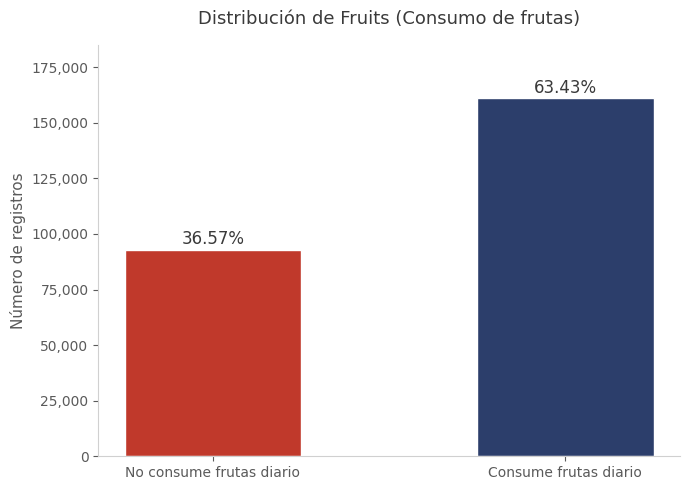

Clase,Conteo
No consume frutas diario,92782
Consume frutas diario,160898


In [27]:
# Fruits 
conteos_fr = df["Fruits"].value_counts().sort_index()
etiquetas_fr = ["No consume frutas diario", "Consume frutas diario"]
porcentajes_fr = (conteos_fr / conteos_fr.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_fr, conteos_fr.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_fr):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de Fruits (Consumo de frutas)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_fr.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_fr = pd.DataFrame({
    "Clase": etiquetas_fr,
    "Conteo": conteos_fr.values,
})
display(tabla_fr.style.hide(axis="index"))

El 63.43% de los encuestados (160.898 personas) consume frutas al menos una vez al día, mientras que el 36.57% (92.782 personas) no lo hace. La mayoría de la muestra mantiene un hábito alimenticio favorable en cuanto al consumo de frutas. No obstante, más de un tercio de la población no alcanza este mínimo dietético recomendado, lo que podría estar relacionado con un mayor riesgo cardiovascular.

#### ***3.2.8 Veggies: Consumo de Vegetales***

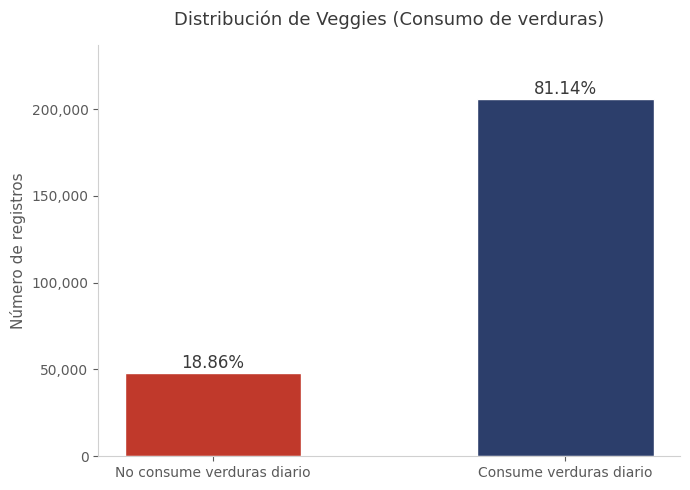

Clase,Conteo
No consume verduras diario,47839
Consume verduras diario,205841


In [28]:
# Veggies 
conteos_vg = df["Veggies"].value_counts().sort_index()
etiquetas_vg = ["No consume verduras diario", "Consume verduras diario"]
porcentajes_vg = (conteos_vg / conteos_vg.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_vg, conteos_vg.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_vg):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de Veggies (Consumo de verduras)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_vg.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_vg = pd.DataFrame({
    "Clase": etiquetas_vg,
    "Conteo": conteos_vg.values,
})
display(tabla_vg.style.hide(axis="index"))

El 81.14% de los encuestados (205.841 personas) consume verduras al menos una vez al día, mientras que solo el 18.86% (47.839 personas) no lo hace. Comparado con el consumo de frutas (63.43%), el hábito de consumir verduras está significativamente más extendido en la muestra, lo que sugiere una mayor adherencia a este componente de la dieta saludable. 

#### ***3.2.9 HvyAlcoholConsump: Consumo de alcohol***

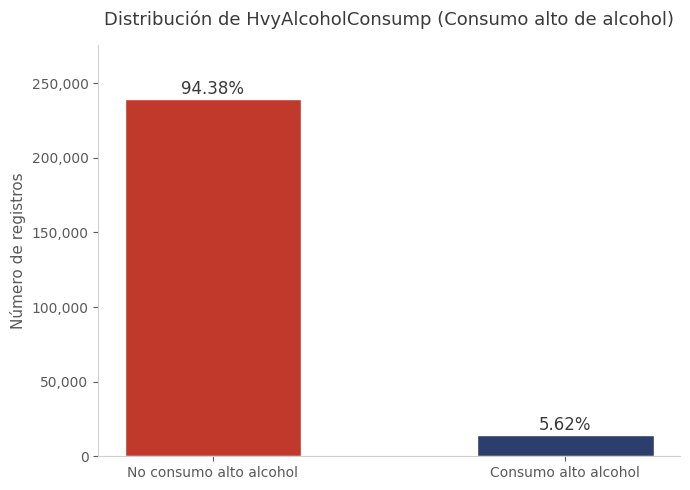

Clase,Conteo
No consumo alto alcohol,239424
Consumo alto alcohol,14256


In [29]:
# HvyAlcoholConsump 
conteos_alc = df["HvyAlcoholConsump"].value_counts().sort_index()
etiquetas_alc = ["No consumo alto alcohol", "Consumo alto alcohol"]
porcentajes_alc = (conteos_alc / conteos_alc.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_alc, conteos_alc.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_alc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de HvyAlcoholConsump (Consumo alto de alcohol)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_alc.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_alc = pd.DataFrame({
    "Clase": etiquetas_alc,
    "Conteo": conteos_alc.values,
})
display(tabla_alc.style.hide(axis="index"))

El 94.38% de los encuestados (239.424 personas) no presenta un patrón de consumo excesivo de alcohol, mientras que apenas el 5.62% (14.256 personas) sí lo hace. La distribución es muy asimétrica, con una gran concentración en la clase negativa, similar a lo observado en variables como Stroke y CholCheck.

#### ***3.2.10 AnyHealthcare: Cobertura médica***

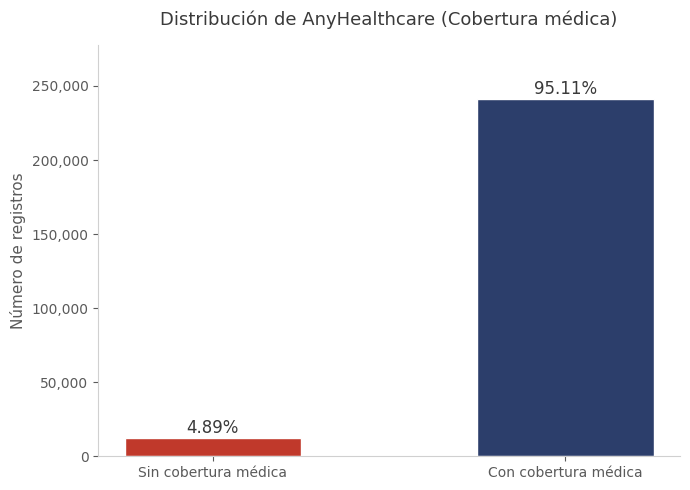

Clase,Conteo
Sin cobertura médica,12417
Con cobertura médica,241263


In [30]:
# AnyHealthcare 
conteos_hc = df["AnyHealthcare"].value_counts().sort_index()
etiquetas_hc = ["Sin cobertura médica", "Con cobertura médica"]
porcentajes_hc = (conteos_hc / conteos_hc.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_hc, conteos_hc.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_hc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de AnyHealthcare (Cobertura médica)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_hc.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_hc = pd.DataFrame({
    "Clase": etiquetas_hc,
    "Conteo": conteos_hc.values,
})
display(tabla_hc.style.hide(axis="index"))

El 95.11% de los encuestados (241.263 personas) cuenta con algún tipo de cobertura médica — ya sea seguro privado, planes prepagados o programas gubernamentales como Medicare —, mientras que solo el 4.89% (12.417 personas) no tiene acceso a ningún tipo de cobertura. La distribución es muy concentrada en la clase positiva, lo que refleja un alto nivel de aseguramiento en la muestra.

#### ***3.2.11 NoDocbcCost: Barrera económica***

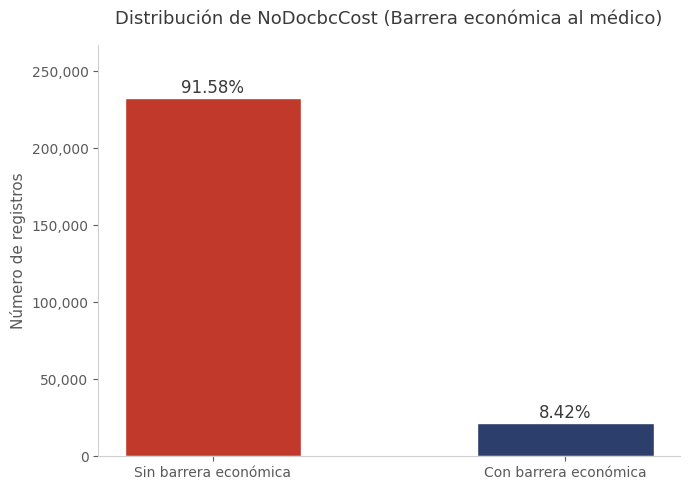

Clase,Conteo
Sin barrera económica,232326
Con barrera económica,21354


In [31]:
#  NoDocbcCost 
conteos_nd = df["NoDocbcCost"].value_counts().sort_index()
etiquetas_nd = ["Sin barrera económica", "Con barrera económica"]
porcentajes_nd = (conteos_nd / conteos_nd.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_nd, conteos_nd.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_nd):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de NoDocbcCost (Barrera económica al médico)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_nd.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_nd = pd.DataFrame({
    "Clase": etiquetas_nd,
    "Conteo": conteos_nd.values,
})
display(tabla_nd.style.hide(axis="index"))

El 91.58% de los encuestados (232.326 personas) no enfrentó barreras económicas para acceder al médico en el último año, mientras que el 8.42% (21.354 personas) sí dejó de consultar un médico por razones de costo. Aunque la mayoría de la muestra no reporta esta dificultad, el grupo afectado no es despreciable — representa más de 21.000 personas que potencialmente dejaron de recibir atención médica oportuna.

#### ***3.2.12 DiffWalk: Dificultad al caminar***

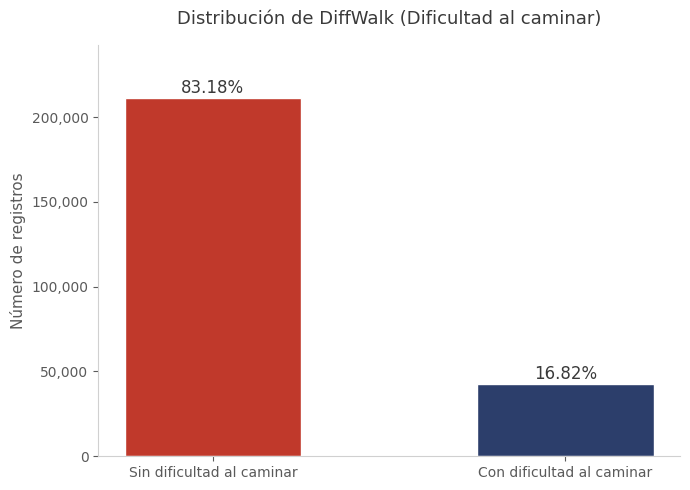

Clase,Conteo
Sin dificultad al caminar,211005
Con dificultad al caminar,42675


In [32]:
# DiffWalk 
conteos_dw = df["DiffWalk"].value_counts().sort_index()
etiquetas_dw = ["Sin dificultad al caminar", "Con dificultad al caminar"]
porcentajes_dw = (conteos_dw / conteos_dw.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_dw, conteos_dw.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_dw):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de DiffWalk (Dificultad al caminar)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_dw.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_dw = pd.DataFrame({
    "Clase": etiquetas_dw,
    "Conteo": conteos_dw.values,
})
display(tabla_dw.style.hide(axis="index"))

El 83.18% de los encuestados (211.005 personas) no presenta dificultad seria para caminar o subir escaleras, mientras que el 16.82% (42.675 personas) sí la reporta. Este porcentaje es considerablemente más alto que el de variables como Stroke o HvyAlcoholConsump, lo que le otorga mayor variabilidad y potencial discriminatorio. 

#### ***3.2.13 Sex: Sexo***

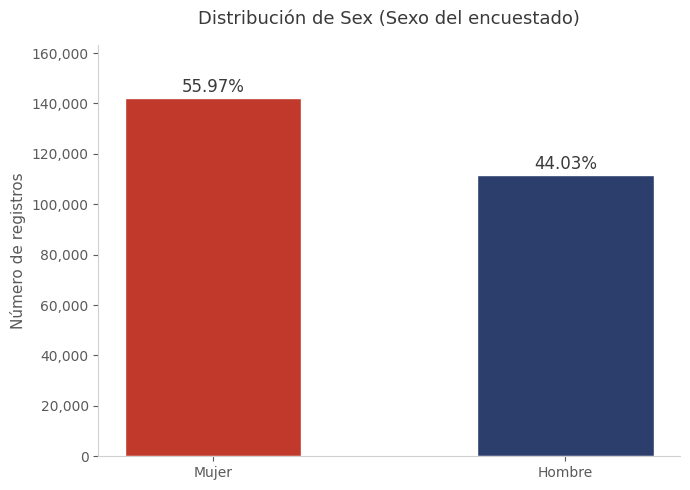

Clase,Conteo
Mujer,141974
Hombre,111706


In [33]:
# Sex 
conteos_sx = df["Sex"].value_counts().sort_index()
etiquetas_sx = ["Mujer", "Hombre"]
porcentajes_sx = (conteos_sx / conteos_sx.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(etiquetas_sx, conteos_sx.values, color=nude_palette, width=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_sx):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 800,
            f"{pct}%",
            ha="center", va="bottom", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de Sex (Sexo del encuestado)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_ylabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_ylim(0, conteos_sx.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_sx = pd.DataFrame({
    "Clase": etiquetas_sx,
    "Conteo": conteos_sx.values,
})
display(tabla_sx.style.hide(axis="index"))

El 55.97% de los encuestados (141.974 personas) son mujeres y el 44.03% (111.706 personas) son hombres. La muestra presenta una distribución relativamente equilibrada entre sexos, con una leve mayoría femenina, lo cual es consistente con patrones típicos de participación en encuestas de salud poblacional donde las mujeres tienden a responder en mayor proporción.

### ***3.3 Variables Ordinales***

#### ***3.3.1 Diabetes***

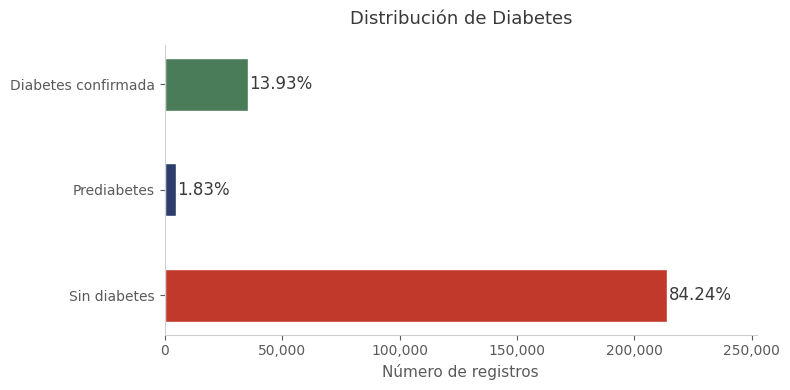

Clase,Conteo
Sin diabetes,213703
Prediabetes,4631
Diabetes confirmada,35346


In [34]:
# Diabetes 
conteos_db = df["Diabetes"].value_counts().sort_index()
etiquetas_db = ["Sin diabetes", "Prediabetes", "Diabetes confirmada"]
porcentajes_db = (conteos_db / conteos_db.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(etiquetas_db, conteos_db.values, color=nude_palette + ["#4A7C59"], height=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_db):
    ax.text(bar.get_width() + 800,
            bar.get_y() + bar.get_height() / 2,
            f"{pct}%",
            ha="left", va="center", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de Diabetes", fontsize=13, pad=15, color="#3a3a3a")
ax.set_xlabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_xlim(0, conteos_db.max() * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_db = pd.DataFrame({
    "Clase": etiquetas_db,
    "Conteo": conteos_db.values,
})
display(tabla_db.style.hide(axis="index"))

El 84.24% de los encuestados (213.703 personas) no presenta diabetes, el 13.93% (35.346 personas) tiene diabetes confirmada y apenas el 1.83% (4.631 personas) se encuentra en estado de prediabetes. Es notable que el grupo de prediabetes sea tan pequeño en comparación con el de diabetes confirmada, lo que podría reflejar un subdiagnóstico de esta condición en la población o una menor conciencia sobre el estado de prediabetes. Esta variable es especialmente relevante para el análisis dado que la diabetes y la enfermedad cardíaca comparten una estrecha relación clínica — la diabetes es uno de los principales factores de riesgo cardiovascular y la principal causa de muerte entre los pacientes diabéticos es precisamente una complicación cardíaca.

#### ***3.3.2 GenHlth: La autopercepción del estado de salud general***

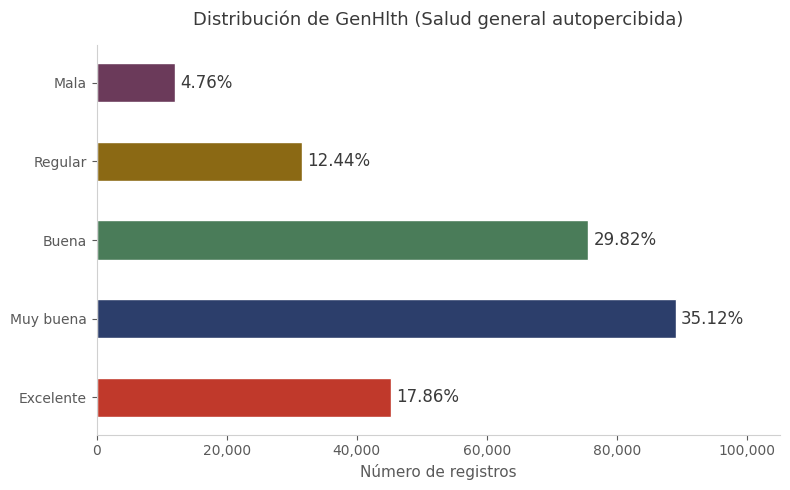

Clase,Conteo
Excelente,45299
Muy buena,89084
Buena,75646
Regular,31570
Mala,12081


In [35]:
# GenHlth 
conteos_gh = df["GenHlth"].value_counts().sort_index()
etiquetas_gh = ["Excelente", "Muy buena", "Buena", "Regular", "Mala"]
porcentajes_gh = (conteos_gh / conteos_gh.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(etiquetas_gh, conteos_gh.values,
               color=[nude_palette[0], nude_palette[1], "#4A7C59", "#8B6914", "#6B3A5A"],
               height=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_gh):
    ax.text(bar.get_width() + 800,
            bar.get_y() + bar.get_height() / 2,
            f"{pct}%",
            ha="left", va="center", fontsize=12, color="#3a3a3a")

ax.set_title("Distribución de GenHlth (Salud general autopercibida)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_xlabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_xlim(0, conteos_gh.max() * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_gh = pd.DataFrame({
    "Clase": etiquetas_gh,
    "Conteo": conteos_gh.values,
})
display(tabla_gh.style.hide(axis="index"))

La autopercepción del estado de salud general muestra una distribución sesgada hacia los valores positivos: el 35.12% de los encuestados (89.084 personas) califica su salud como muy buena y el 17.86% (45.299 personas) como excelente, sumando más de la mitad de la muestra (52.98%) en las dos categorías más favorables. El 29.82% (75.646 personas) la percibe como buena, mientras que los extremos negativos — regular y mala — representan el 12.44% (31.570 personas) y el 4.76% (12.081 personas) respectivamente. 

#### ***3.3.3 Age: Edad***

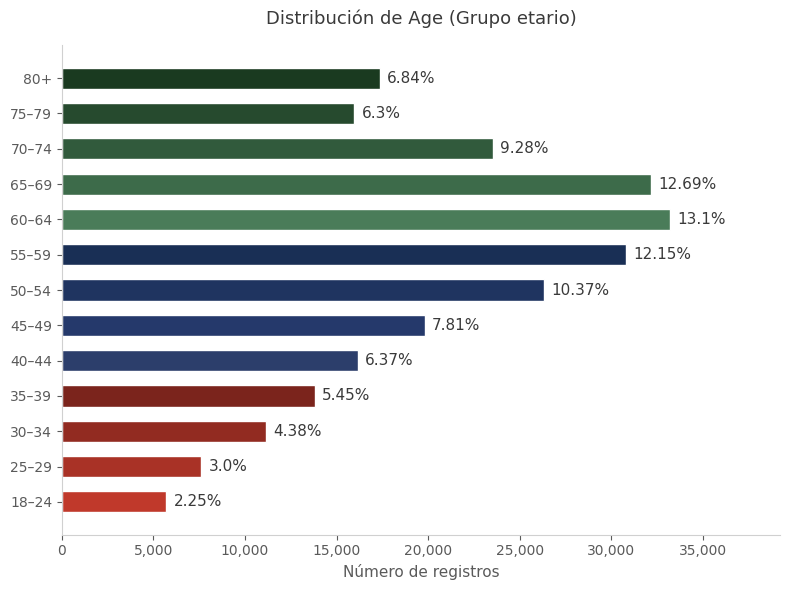

Grupo etario,Conteo
18–24,5700
25–29,7598
30–34,11123
35–39,13823
40–44,16157
45–49,19819
50–54,26314
55–59,30832
60–64,33244
65–69,32194


In [36]:
#  Age 
conteos_age = df["Age"].value_counts().sort_index()
etiquetas_age = ["18–24", "25–29", "30–34", "35–39", "40–44",
                 "45–49", "50–54", "55–59", "60–64", "65–69",
                 "70–74", "75–79", "80+"]
porcentajes_age = (conteos_age / conteos_age.sum() * 100).round(2)

colores_age = ["#C0392B", "#A93226", "#922B21", "#7B241C", "#2C3E6B",
               "#25396B", "#1F3460", "#192F55", "#4A7C59", "#3D6B4A",
               "#315A3C", "#264A2E", "#1A3A20"]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(etiquetas_age, conteos_age.values,
               color=colores_age, height=0.6, edgecolor="white")

for bar, pct in zip(bars, porcentajes_age):
    ax.text(bar.get_width() + 400,
            bar.get_y() + bar.get_height() / 2,
            f"{pct}%",
            ha="left", va="center", fontsize=11, color="#3a3a3a")

ax.set_title("Distribución de Age (Grupo etario)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_xlabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_xlim(0, conteos_age.max() * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_age = pd.DataFrame({
    "Grupo etario": etiquetas_age,
    "Conteo": conteos_age.values,
})
display(tabla_age.style.hide(axis="index"))

La distribución por grupos etarios muestra un patrón claramente sesgado hacia los adultos de mediana edad y mayores. Los grupos con mayor representación son 60–64 años (13.10%), 55–59 años (12.15%) y 65–69 años (12.69%), concentrando entre los tres casi el 38% de la muestra. En contraste, los grupos más jóvenes — 18–24 y 25–29 años — representan apenas el 2.25% y 3.00% respectivamente, siendo los menos representados. Esta distribución es consistente con el perfil típico de encuestas de salud como el BRFSS, donde la participación tiende a aumentar con la edad. 

#### ***3.3.4 Education: Educación***

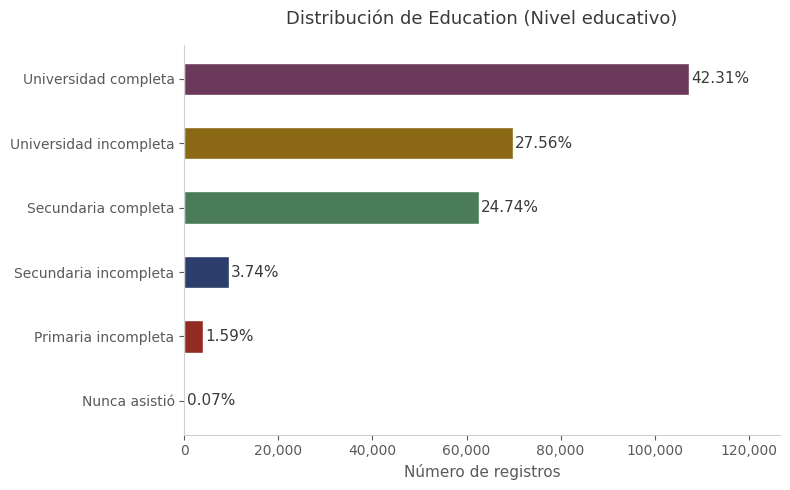

Nivel educativo,Conteo
Nunca asistió,174
Primaria incompleta,4043
Secundaria incompleta,9478
Secundaria completa,62750
Universidad incompleta,69910
Universidad completa,107325


In [37]:
# Education 
conteos_ed = df["Education"].value_counts().sort_index()
etiquetas_ed = ["Nunca asistió", "Primaria incompleta",
                "Secundaria incompleta", "Secundaria completa",
                "Universidad incompleta", "Universidad completa"]
porcentajes_ed = (conteos_ed / conteos_ed.sum() * 100).round(2)

colores_ed = ["#C0392B", "#922B21", "#2C3E6B", "#4A7C59", "#8B6914", "#6B3A5A"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(etiquetas_ed, conteos_ed.values,
               color=colores_ed, height=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_ed):
    ax.text(bar.get_width() + 400,
            bar.get_y() + bar.get_height() / 2,
            f"{pct}%",
            ha="left", va="center", fontsize=11, color="#3a3a3a")

ax.set_title("Distribución de Education (Nivel educativo)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_xlabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_xlim(0, conteos_ed.max() * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_ed = pd.DataFrame({
    "Nivel educativo": etiquetas_ed,
    "Conteo": conteos_ed.values,
})
display(tabla_ed.style.hide(axis="index"))

La distribución del nivel educativo muestra un claro sesgo hacia los niveles más altos de escolaridad. El 42.31% de los encuestados (107.325 personas) completó la universidad, siendo el grupo más numeroso, seguido por quienes tienen universidad incompleta con el 27.56% (69.910 personas). Juntos, estos dos grupos representan casi el 70% de la muestra. En el extremo opuesto, quienes nunca asistieron a la escuela representan apenas el 0.07% (174 personas) y primaria incompleta el 1.59% (4.043 personas), siendo grupos marginales dentro del dataset. Esta distribución sugiere que la muestra está compuesta predominantemente por personas con alto nivel educativo, lo cual es un sesgo de selección típico en encuestas telefónicas donde la participación tiende a correlacionarse positivamente con la escolaridad.

#### ***3.3.5 Income: Ingreso Anual***

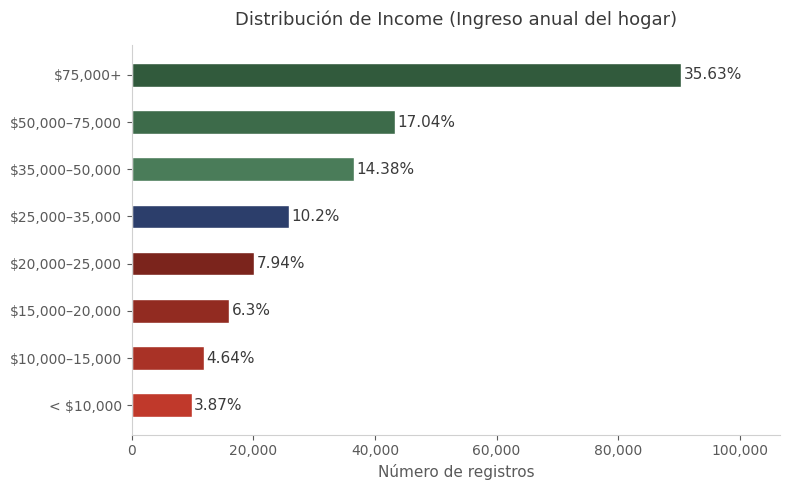

Ingreso anual,Conteo
"< $10,000",9811
"$10,000–15,000",11783
"$15,000–20,000",15994
"$20,000–25,000",20135
"$25,000–35,000",25883
"$35,000–50,000",36470
"$50,000–75,000",43219
"$75,000+",90385


In [38]:
# Income 
conteos_inc = df["Income"].value_counts().sort_index()
etiquetas_inc = ["< $10,000", "$10,000–15,000", "$15,000–20,000",
                 "$20,000–25,000", "$25,000–35,000", "$35,000–50,000",
                 "$50,000–75,000", "$75,000+"]
porcentajes_inc = (conteos_inc / conteos_inc.sum() * 100).round(2)

colores_inc = ["#C0392B", "#A93226", "#922B21", "#7B241C",
               "#2C3E6B", "#4A7C59", "#3D6B4A", "#315A3C"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(etiquetas_inc, conteos_inc.values,
               color=colores_inc, height=0.5, edgecolor="white")

for bar, pct in zip(bars, porcentajes_inc):
    ax.text(bar.get_width() + 400,
            bar.get_y() + bar.get_height() / 2,
            f"{pct}%",
            ha="left", va="center", fontsize=11, color="#3a3a3a")

ax.set_title("Distribución de Income (Ingreso anual del hogar)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_xlabel("Número de registros", fontsize=11, color="#5a5a5a")
ax.set_xlim(0, conteos_inc.max() * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

# Tabla
tabla_inc = pd.DataFrame({
    "Ingreso anual": etiquetas_inc,
    "Conteo": conteos_inc.values,
})
display(tabla_inc.style.hide(axis="index"))

La distribución del ingreso anual del hogar muestra un marcado sesgo hacia los niveles más altos, con el 35.63% de los encuestados (90.385 personas) reportando ingresos de $75.000 o más, siendo con amplia diferencia el grupo más numeroso. A partir de ahí, la frecuencia disminuye progresivamente hacia los tramos más bajos, donde los hogares con ingresos menores a $10.000 representan apenas el 3.87% (9.811 personas). Este patrón es consistente con el sesgo observado en Education, reforzando la idea de que la muestra está sobrerrepresentada por personas de mayor nivel socioeconómico, lo cual es característico de encuestas telefónicas. 

### ***3.4 Variables Continuas***

#### ***3.4.1 BMI: Indice de Masa Corporal***

In [39]:
q1_bmi = df["BMI"].quantile(0.25)
q3_bmi = df["BMI"].quantile(0.75)
iqr_bmi = q3_bmi - q1_bmi
limite_inf_bmi = q1_bmi - 1.5 * iqr_bmi
limite_sup_bmi = q3_bmi + 1.5 * iqr_bmi
outliers_bmi = df[(df["BMI"] < limite_inf_bmi) | (df["BMI"] > limite_sup_bmi)]

resumen_bmi = pd.DataFrame({
    "Métrica": ["Conteo", "Media", "Desv. estándar", "Mínimo", "Q1 (25%)",
                "Mediana (50%)", "Q3 (75%)", "Máximo", "IQR",
                "Límite inferior", "Límite superior", "N° outliers",
                "% outliers"],
    "Valor": [
        f"{df['BMI'].count():,}",
        f"{df['BMI'].mean():.2f}",
        f"{df['BMI'].std():.2f}",
        f"{df['BMI'].min():.1f}",
        f"{q1_bmi:.1f}",
        f"{df['BMI'].median():.1f}",
        f"{q3_bmi:.1f}",
        f"{df['BMI'].max():.1f}",
        f"{iqr_bmi:.1f}",
        f"{limite_inf_bmi:.1f}",
        f"{limite_sup_bmi:.1f}",
        f"{len(outliers_bmi):,}",
        f"{len(outliers_bmi) / len(df) * 100:.2f}%"
    ]
})

display(resumen_bmi.style.hide(axis="index"))

Métrica,Valor
Conteo,"253,680"
Media,28.38
Desv. estándar,6.61
Mínimo,12.0
Q1 (25%),24.0
Mediana (50%),27.0
Q3 (75%),31.0
Máximo,98.0
IQR,7.0
Límite inferior,13.5


El BMI presenta una media de 28.38 y una mediana de 27.0, valores muy cercanos entre sí, lo que indica una distribución relativamente simétrica aunque con una leve asimetría positiva hacia valores altos. La desviación estándar de 6.61 refleja una dispersión moderada alrededor de la media. El rango intercuartílico (IQR) es de 7.0, con el 50% central de la muestra ubicado entre 24.0 y 31.0, lo que corresponde clínicamente a los rangos de peso normal alto y sobrepeso según los estándares del IMC. El valor máximo de 98.0 es llamativo y clínicamente extremo, lo que se confirma con la detección de 9.847 valores atípicos (3.88% de la muestra) por encima del límite superior de 41.5, todos correspondientes a casos de obesidad severa. 

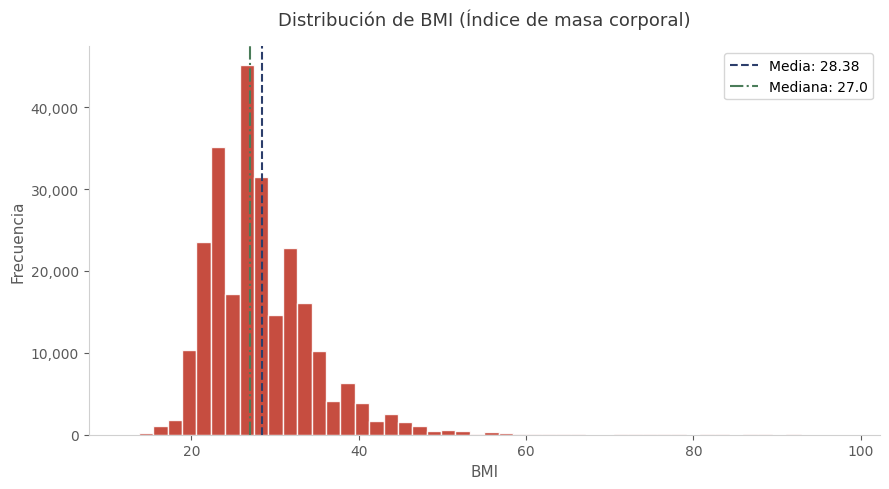

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["BMI"], bins=50, color=nude_palette[0], edgecolor="white", alpha=0.9)

# Líneas de media y mediana
ax.axvline(df["BMI"].mean(), color=nude_palette[1], linestyle="--", linewidth=1.5, label=f"Media: {df['BMI'].mean():.2f}")
ax.axvline(df["BMI"].median(), color="#4A7C59", linestyle="-.", linewidth=1.5, label=f"Mediana: {df['BMI'].median():.1f}")

ax.set_title("Distribución de BMI (Índice de masa corporal)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_xlabel("BMI", fontsize=11, color="#5a5a5a")
ax.set_ylabel("Frecuencia", fontsize=11, color="#5a5a5a")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10)
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()


El histograma confirma visualmente lo observado en el resumen estadístico. La distribución del BMI presenta una asimetría positiva (sesgo a la derecha), con la mayor concentración de valores ubicada entre 22 y 32, donde se encuentra el pico de la distribución.

#### ***3.4.2 MentHlth: Días con mala salud física***

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


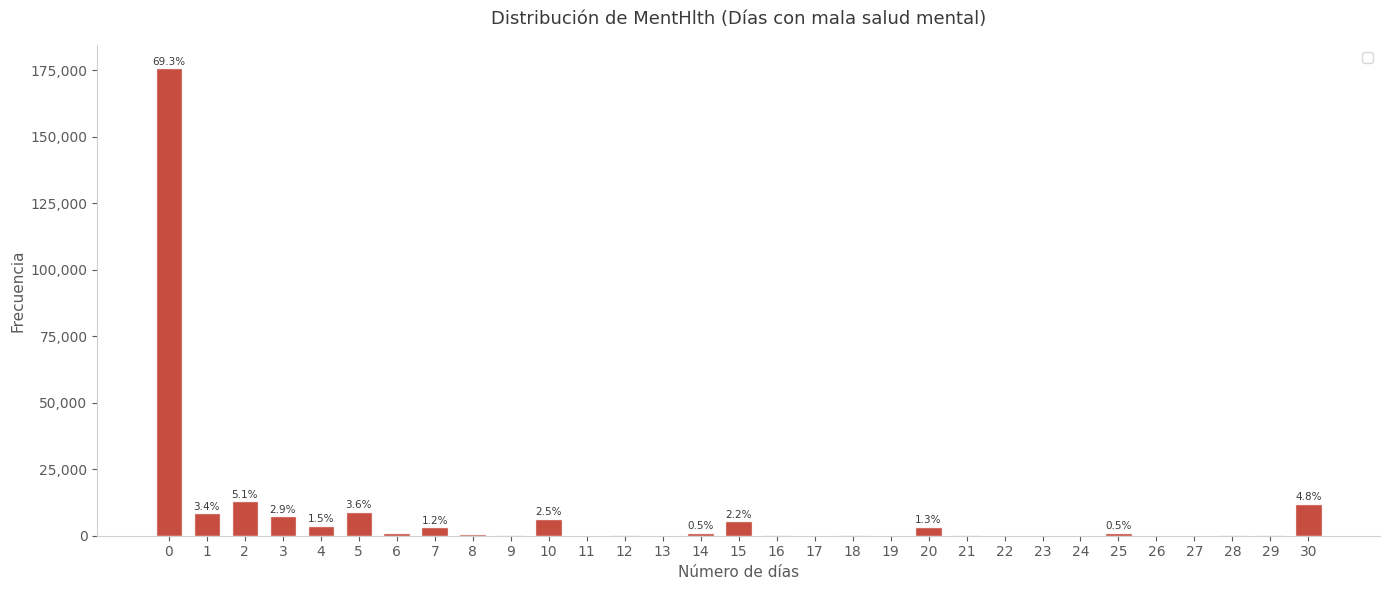

In [41]:
conteos_mh = df["MentHlth"].value_counts().sort_index()
porcentajes_mh = (conteos_mh / conteos_mh.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(conteos_mh.index, conteos_mh.values,
              color=nude_palette[0], edgecolor="white", alpha=0.9, width=0.7)

# Porcentaje encima de cada barra
for bar, pct in zip(bars, porcentajes_mh):
    if pct >= 0.5:  # solo muestra si el porcentaje es visible
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 500,
                f"{pct}%",
                ha="center", va="bottom", fontsize=7.5, color="#3a3a3a")



ax.set_title("Distribución de MentHlth (Días con mala salud mental)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_xlabel("Número de días", fontsize=11, color="#5a5a5a")
ax.set_ylabel("Frecuencia", fontsize=11, color="#5a5a5a")
ax.set_xticks(range(0, 31))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10)
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

El gráfico confirma de forma contundente la distribución extremadamente asimétrica de MentHlth. El 69.3% de los encuestados reportó 0 días de mala salud mental, siendo esta barra completamente dominante sobre el resto. A partir del día 1 la frecuencia cae drásticamente, con pequeños repuntes notables en los días 2 (5.1%), 5 (3.6%), 10 (2.5%), 15 (2.2%), 20 (1.3%) y 30 (4.8%) — este último siendo el segundo valor más frecuente, lo que sugiere que muchos encuestados que sí reportaron días de mala salud mental tendieron a responder con el mes completo (30 días). 

#### ***3.4.3 PhysHlth: Días con mala salud fisica***

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


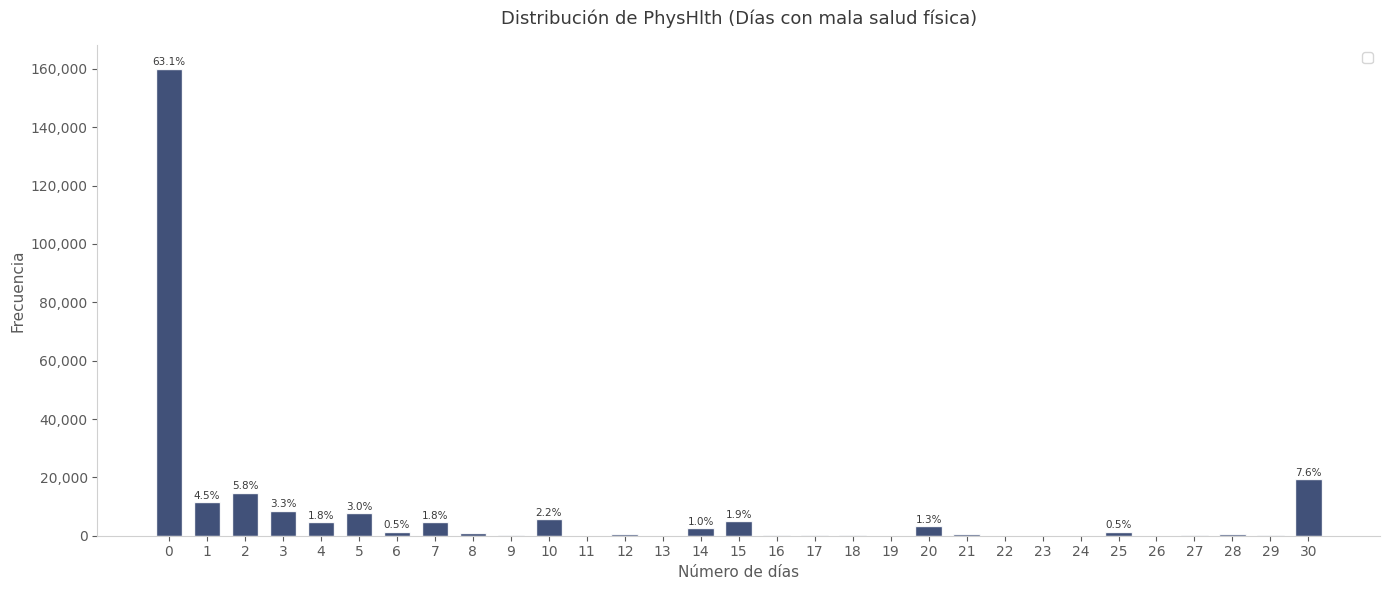

In [42]:
conteos_ph = df["PhysHlth"].value_counts().sort_index()
porcentajes_ph = (conteos_ph / conteos_ph.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(conteos_ph.index, conteos_ph.values,
              color=nude_palette[1], edgecolor="white", alpha=0.9, width=0.7)

# Porcentaje encima de cada barra
for bar, pct in zip(bars, porcentajes_ph):
    if pct >= 0.5:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 500,
                f"{pct}%",
                ha="center", va="bottom", fontsize=7.5, color="#3a3a3a")



ax.set_title("Distribución de PhysHlth (Días con mala salud física)", fontsize=13, pad=15, color="#3a3a3a")
ax.set_xlabel("Número de días", fontsize=11, color="#5a5a5a")
ax.set_ylabel("Frecuencia", fontsize=11, color="#5a5a5a")
ax.set_xticks(range(0, 31))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10)
ax.tick_params(colors="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")

plt.tight_layout()
plt.show()

El 63.1% de los encuestados reportó 0 días de mala salud física, una proporción menor que en salud mental (69.3%), lo que sugiere que la afectación física es ligeramente más prevalente en la muestra. Al igual que MentHlth, se observan repuntes en números redondos como los días 2 (5.8%), 5 (3.0%), 7 (1.8%), 10 (2.2%) y 20 (1.3%), confirmando el patrón de respuesta redondeada típico del autoreporte. El valor más llamativo es el día 30 con un 7.6%, superando incluso al observado en MentHlth (4.8%), lo que indica que una proporción considerable de encuestados experimentó mala salud física durante el mes completo 

## ***4. Análisis Bivariado***

Para el análisis bivariado se examina la relación entre cada variable predictora y la variable objetivo `HeartDiseaseorAttack`. La métrica de asociación varía según el tipo estadístico de la variable:

- **Variables binarias y ordinales → Chi-cuadrado + V de Cramér**: la prueba χ² evalúa si la asociación es estadísticamente significativa; la V de Cramér cuantifica su magnitud en un rango [0, 1].
- **Variables continuas → Mann-Whitney U + correlación de Pearson |r|**: dado el sesgo pronunciado de BMI, MentHlth y PhysHlth, la prueba no paramétrica de Mann-Whitney es más robusta que la t de Student.

In [43]:
from scipy.stats import chi2_contingency, mannwhitneyu

target        = 'HeartDiseaseorAttack'
binary_vars   = ['HighBP','HighChol','CholCheck','Smoker','Stroke',
                 'PhysActivity','Fruits','Veggies','HvyAlcoholConsump',
                 'AnyHealthcare','NoDocbcCost','DiffWalk','Sex']
ordinal_vars  = ['GenHlth','Age','Education','Income','Diabetes']
continuous_vars = ['BMI','MentHlth','PhysHlth']

riesgo_color = "#C0392B"
bajo_color   = "#2C3E6B"


### ***4.1 Correlación global con la variable objetivo***

Como punto de partida se presenta el ranking de correlación de Pearson de todas las variables con `HeartDiseaseorAttack`. Esta métrica ofrece una visión rápida de la dirección y fuerza relativa de cada asociación, para luego hacer un análisis más personalizado por cada tipo de variable.

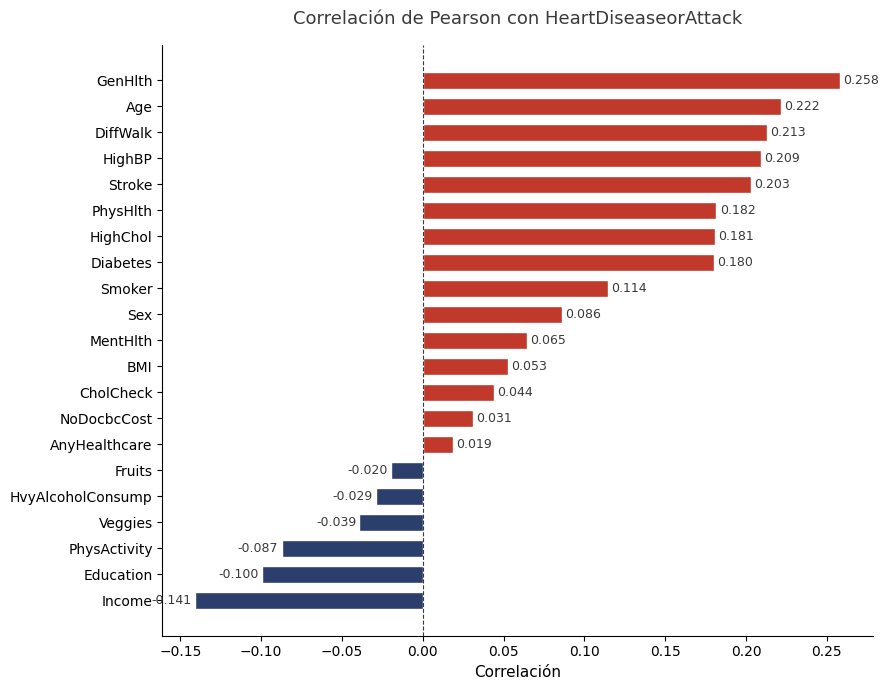

In [44]:
corr_target = df.corr()[target].drop(target).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [riesgo_color if v > 0 else bajo_color for v in corr_target.values]
bars   = ax.barh(corr_target.index[::-1], corr_target.values[::-1],
                 color=colors[::-1], edgecolor="white", height=0.65)

ax.axvline(0, color="#3a3a3a", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, corr_target.values[::-1]):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9, color="#3a3a3a")

ax.set_title("Correlación de Pearson con HeartDiseaseorAttack",
             fontsize=13, pad=15, color="#3a3a3a")
ax.set_xlabel("Correlación", fontsize=11)
ax.tick_params(axis="y", labelsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


Las correlaciones más altas son **GenHlth** (0.258), **Age** (0.222), **DiffWalk** (0.213), **HighBP** (0.209) y **Stroke** (0.203). Las correlaciones negativas más relevantes son **Income** (−0.141), **Education** (−0.100) y **PhysActivity** (−0.087), indicando que mayor ingreso, educación y actividad física se asocian a menor riesgo.

### ***4.2 Variables binarias***

#### ***4.2.1 HighBP***

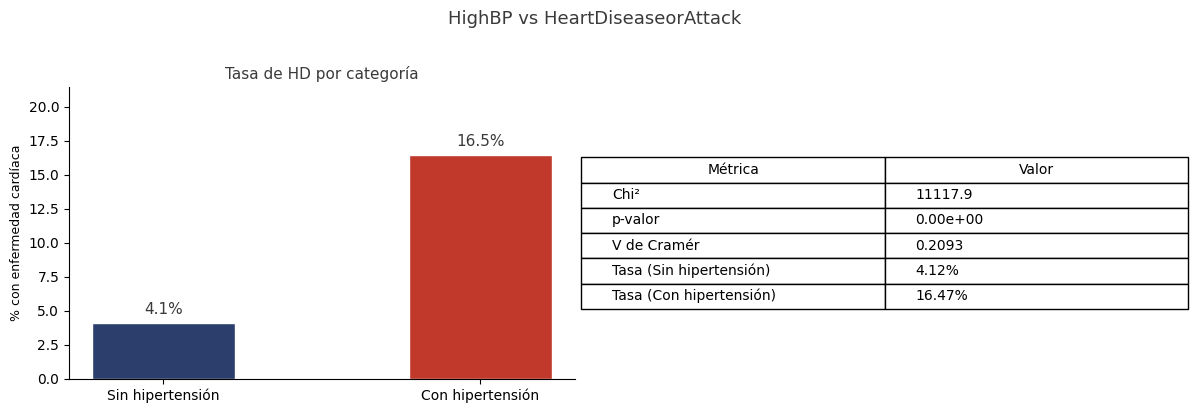

In [45]:
# HighBP — bivariado
ct_highbp = pd.crosstab(df["HighBP"], df[target])
chi2_highbp, p_highbp, _, _ = chi2_contingency(ct_highbp)
n = ct_highbp.values.sum()
cramer_highbp = np.sqrt(chi2_highbp / (n * (min(ct_highbp.shape) - 1)))

tasa_highbp = df.groupby("HighBP")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Sin hipertensión', 'Con hipertensión'], tasa_highbp.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_highbp.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_highbp.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Sin hipertensión)", f"Tasa (Con hipertensión)"],
    "Valor"   : [f"{chi2_highbp:.1f}", f"{p_highbp:.2e}",
                 f"{cramer_highbp:.4f}", f"{tasa_highbp.values[0]:.2f}%",
                 f"{tasa_highbp.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"HighBP vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


La hipertensión **cuadruplica** la tasa de enfermedad cardíaca (16.47% vs 4.12%). Con una V de Cramér de 0.2093, es la segunda variable binaria con mayor asociación. La presión arterial elevada daña directamente las paredes arteriales, acelerando la aterosclerosis.

#### ***4.2.2 HighChol***

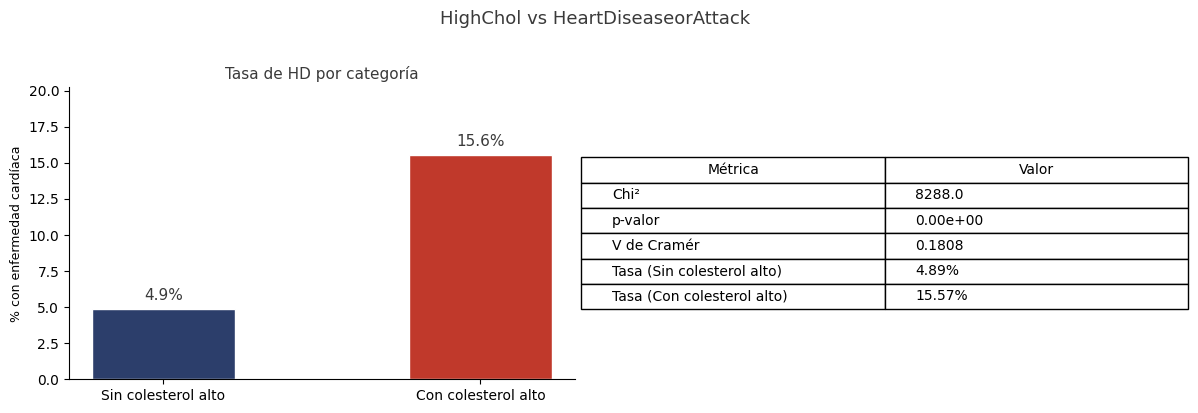

In [46]:
# HighChol — bivariado
ct_highchol = pd.crosstab(df["HighChol"], df[target])
chi2_highchol, p_highchol, _, _ = chi2_contingency(ct_highchol)
n = ct_highchol.values.sum()
cramer_highchol = np.sqrt(chi2_highchol / (n * (min(ct_highchol.shape) - 1)))

tasa_highchol = df.groupby("HighChol")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Sin colesterol alto', 'Con colesterol alto'], tasa_highchol.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_highchol.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_highchol.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Sin colesterol alto)", f"Tasa (Con colesterol alto)"],
    "Valor"   : [f"{chi2_highchol:.1f}", f"{p_highchol:.2e}",
                 f"{cramer_highchol:.4f}", f"{tasa_highchol.values[0]:.2f}%",
                 f"{tasa_highchol.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"HighChol vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


El colesterol alto **triplica** la tasa de HD (15.57% vs 4.89%), con V=0.1808. El exceso de LDL promueve la formación de placas en las arterias coronarias, mecanismo central en la patogénesis de la enfermedad cardíaca.

#### ***4.2.3 CholCheck***

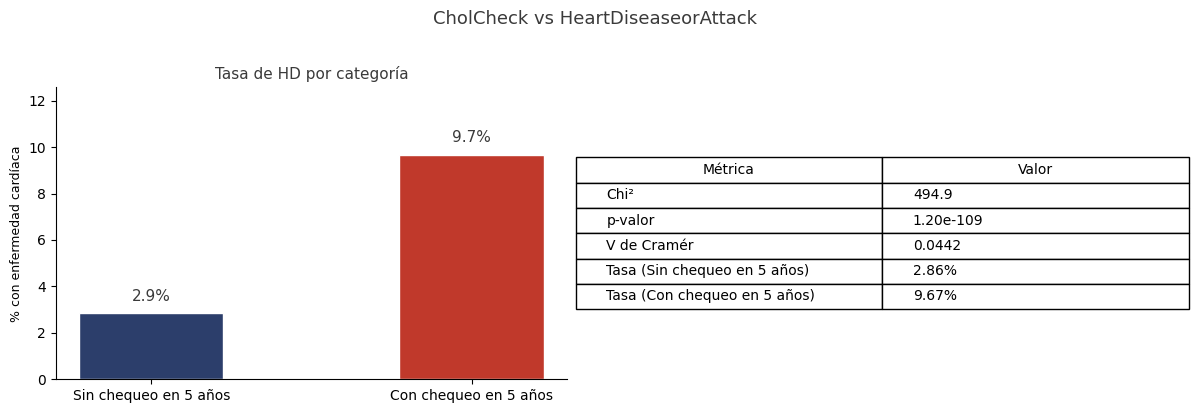

In [47]:
# CholCheck — bivariado
ct_cholcheck = pd.crosstab(df["CholCheck"], df[target])
chi2_cholcheck, p_cholcheck, _, _ = chi2_contingency(ct_cholcheck)
n = ct_cholcheck.values.sum()
cramer_cholcheck = np.sqrt(chi2_cholcheck / (n * (min(ct_cholcheck.shape) - 1)))

tasa_cholcheck = df.groupby("CholCheck")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Sin chequeo en 5 años', 'Con chequeo en 5 años'], tasa_cholcheck.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_cholcheck.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_cholcheck.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Sin chequeo en 5 años)", f"Tasa (Con chequeo en 5 años)"],
    "Valor"   : [f"{chi2_cholcheck:.1f}", f"{p_cholcheck:.2e}",
                 f"{cramer_cholcheck:.4f}", f"{tasa_cholcheck.values[0]:.2f}%",
                 f"{tasa_cholcheck.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"CholCheck vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


Quienes se chequearon el colesterol presentan mayor tasa (9.67% vs 2.86%), lo que refleja un sesgo de detección: las personas con más factores de riesgo acuden más al médico y reciben diagnósticos. La V de Cramér es baja (0.0442), indicando asociación débil en magnitud.

#### ***4.2.4 Smoker***

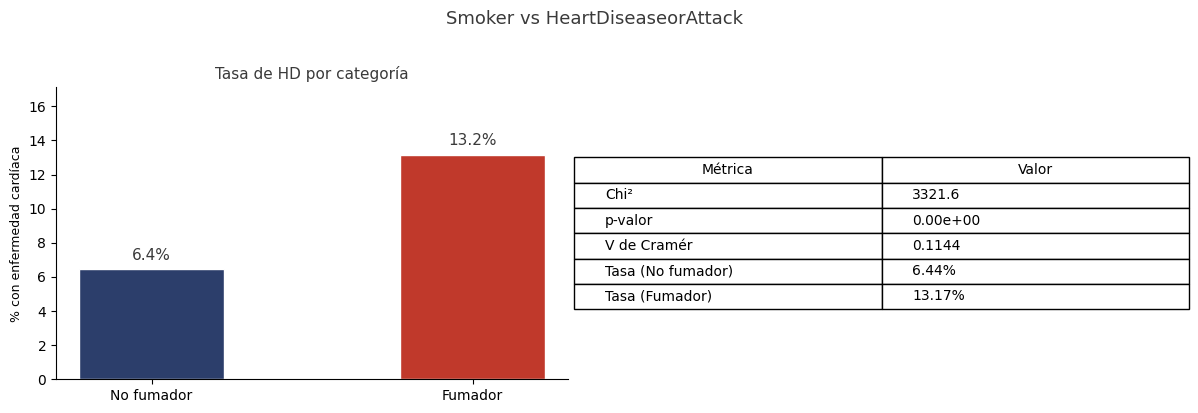

In [48]:
# Smoker — bivariado
ct_smoker = pd.crosstab(df["Smoker"], df[target])
chi2_smoker, p_smoker, _, _ = chi2_contingency(ct_smoker)
n = ct_smoker.values.sum()
cramer_smoker = np.sqrt(chi2_smoker / (n * (min(ct_smoker.shape) - 1)))

tasa_smoker = df.groupby("Smoker")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['No fumador', 'Fumador'], tasa_smoker.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_smoker.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_smoker.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (No fumador)", f"Tasa (Fumador)"],
    "Valor"   : [f"{chi2_smoker:.1f}", f"{p_smoker:.2e}",
                 f"{cramer_smoker:.4f}", f"{tasa_smoker.values[0]:.2f}%",
                 f"{tasa_smoker.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"Smoker vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


Los fumadores **duplican** la tasa de HD (13.17% vs 6.44%), con V=0.1144. El tabaquismo genera estrés oxidativo, disfunción endotelial e inflamación crónica, todos mecanismos directos de daño cardiovascular.

#### ***4.2.5 Stroke***

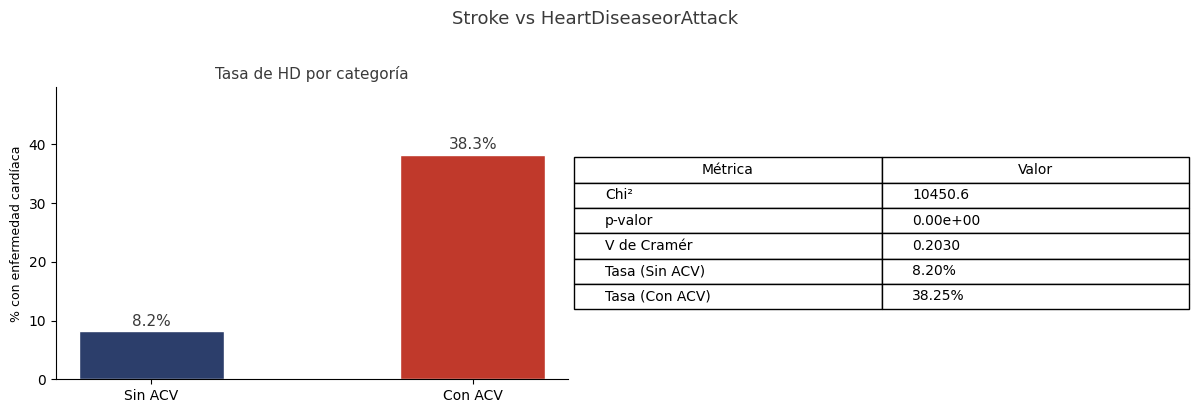

In [49]:
# Stroke — bivariado
ct_stroke = pd.crosstab(df["Stroke"], df[target])
chi2_stroke, p_stroke, _, _ = chi2_contingency(ct_stroke)
n = ct_stroke.values.sum()
cramer_stroke = np.sqrt(chi2_stroke / (n * (min(ct_stroke.shape) - 1)))

tasa_stroke = df.groupby("Stroke")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Sin ACV', 'Con ACV'], tasa_stroke.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_stroke.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_stroke.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Sin ACV)", f"Tasa (Con ACV)"],
    "Valor"   : [f"{chi2_stroke:.1f}", f"{p_stroke:.2e}",
                 f"{cramer_stroke:.4f}", f"{tasa_stroke.values[0]:.2f}%",
                 f"{tasa_stroke.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"Stroke vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


El antecedente de ACV tiene la **tasa absoluta más alta** entre las variables binarias (38.25%), con V=0.2030. ACV y enfermedad cardíaca comparten los mismos factores de riesgo subyacentes; su coexistencia señala un perfil de riesgo cardiovascular severo.

#### ***4.2.6 PhysActivity***

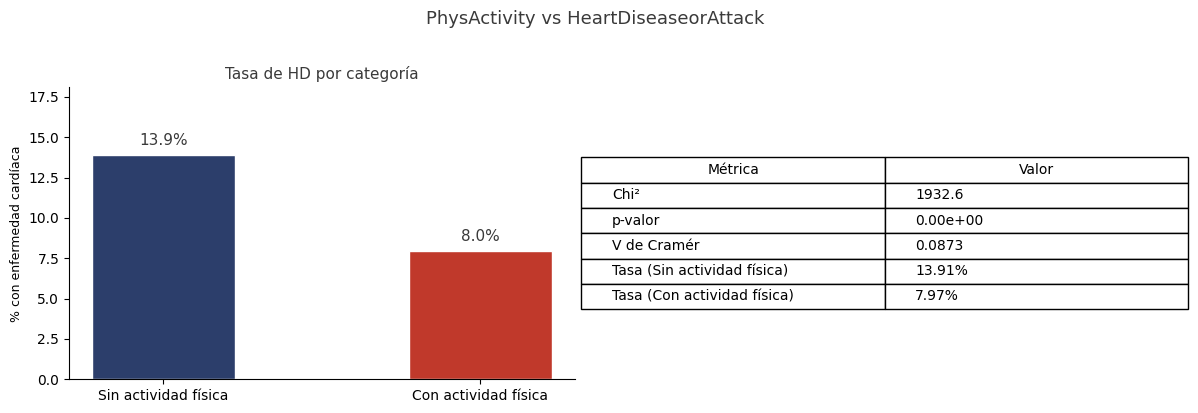

In [50]:
# PhysActivity — bivariado
ct_physactivity = pd.crosstab(df["PhysActivity"], df[target])
chi2_physactivity, p_physactivity, _, _ = chi2_contingency(ct_physactivity)
n = ct_physactivity.values.sum()
cramer_physactivity = np.sqrt(chi2_physactivity / (n * (min(ct_physactivity.shape) - 1)))

tasa_physactivity = df.groupby("PhysActivity")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Sin actividad física', 'Con actividad física'], tasa_physactivity.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_physactivity.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_physactivity.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Sin actividad física)", f"Tasa (Con actividad física)"],
    "Valor"   : [f"{chi2_physactivity:.1f}", f"{p_physactivity:.2e}",
                 f"{cramer_physactivity:.4f}", f"{tasa_physactivity.values[0]:.2f}%",
                 f"{tasa_physactivity.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"PhysActivity vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


La inactividad física **casi duplica** la tasa de HD (13.91% vs 7.97%), con V=0.0873. El sedentarismo favorece la obesidad, la hipertensión y la dislipidemia, factores de riesgo cardiovascular clásicos.

#### ***4.2.7 Fruits***

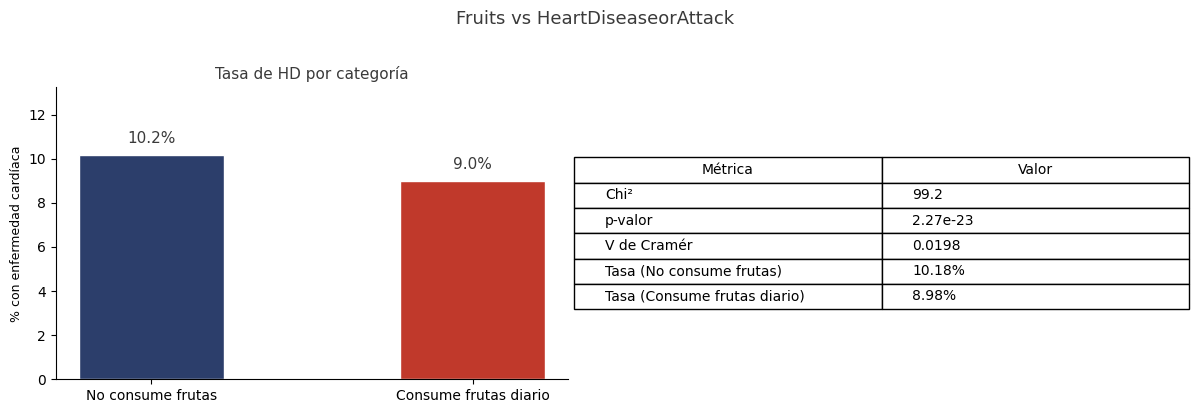

In [51]:
# Fruits — bivariado
ct_fruits = pd.crosstab(df["Fruits"], df[target])
chi2_fruits, p_fruits, _, _ = chi2_contingency(ct_fruits)
n = ct_fruits.values.sum()
cramer_fruits = np.sqrt(chi2_fruits / (n * (min(ct_fruits.shape) - 1)))

tasa_fruits = df.groupby("Fruits")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['No consume frutas', 'Consume frutas diario'], tasa_fruits.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_fruits.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_fruits.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (No consume frutas)", f"Tasa (Consume frutas diario)"],
    "Valor"   : [f"{chi2_fruits:.1f}", f"{p_fruits:.2e}",
                 f"{cramer_fruits:.4f}", f"{tasa_fruits.values[0]:.2f}%",
                 f"{tasa_fruits.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"Fruits vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


El consumo de frutas muestra una asociación muy débil (V=0.0198). La diferencia de tasas es marginal (10.18% vs 8.98%), sugiriendo que esta variable por sí sola aporta escaso poder discriminatorio respecto al riesgo cardíaco.

#### ***4.2.8 Veggies***

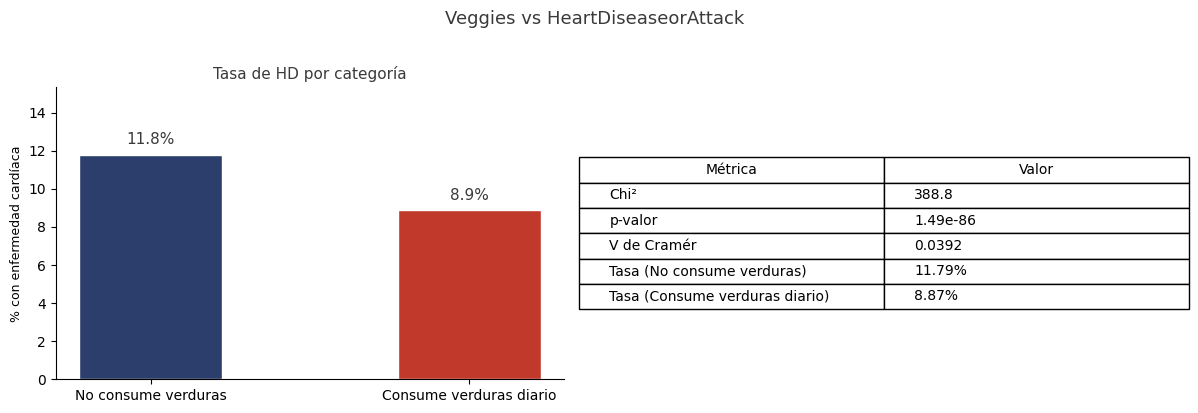

In [52]:
# Veggies — bivariado
ct_veggies = pd.crosstab(df["Veggies"], df[target])
chi2_veggies, p_veggies, _, _ = chi2_contingency(ct_veggies)
n = ct_veggies.values.sum()
cramer_veggies = np.sqrt(chi2_veggies / (n * (min(ct_veggies.shape) - 1)))

tasa_veggies = df.groupby("Veggies")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['No consume verduras', 'Consume verduras diario'], tasa_veggies.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_veggies.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_veggies.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (No consume verduras)", f"Tasa (Consume verduras diario)"],
    "Valor"   : [f"{chi2_veggies:.1f}", f"{p_veggies:.2e}",
                 f"{cramer_veggies:.4f}", f"{tasa_veggies.values[0]:.2f}%",
                 f"{tasa_veggies.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"Veggies vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


Consumir verduras diariamente se asocia a una tasa ligeramente menor (8.87% vs 11.79%). La asociación es estadísticamente significativa pero de magnitud baja (V=0.0392), consistente con la evidencia de que los efectos dietéticos aislados son modestos.

#### ***4.2.9 HvyAlcoholConsump***

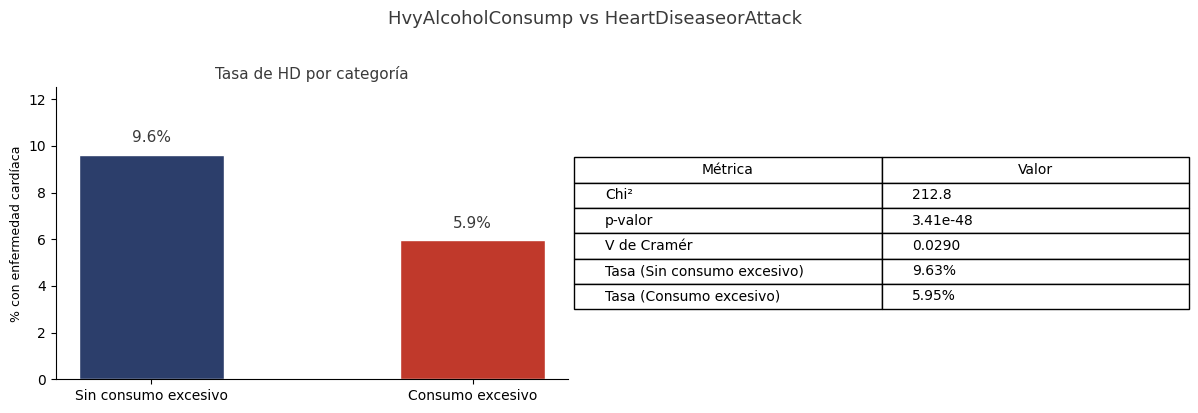

In [53]:
# HvyAlcoholConsump — bivariado
ct_hvyalcoholconsump = pd.crosstab(df["HvyAlcoholConsump"], df[target])
chi2_hvyalcoholconsump, p_hvyalcoholconsump, _, _ = chi2_contingency(ct_hvyalcoholconsump)
n = ct_hvyalcoholconsump.values.sum()
cramer_hvyalcoholconsump = np.sqrt(chi2_hvyalcoholconsump / (n * (min(ct_hvyalcoholconsump.shape) - 1)))

tasa_hvyalcoholconsump = df.groupby("HvyAlcoholConsump")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Sin consumo excesivo', 'Consumo excesivo'], tasa_hvyalcoholconsump.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_hvyalcoholconsump.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_hvyalcoholconsump.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Sin consumo excesivo)", f"Tasa (Consumo excesivo)"],
    "Valor"   : [f"{chi2_hvyalcoholconsump:.1f}", f"{p_hvyalcoholconsump:.2e}",
                 f"{cramer_hvyalcoholconsump:.4f}", f"{tasa_hvyalcoholconsump.values[0]:.2f}%",
                 f"{tasa_hvyalcoholconsump.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"HvyAlcoholConsump vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


El consumo excesivo de alcohol presenta una tasa **menor** de HD (5.95% vs 9.63%), con V=0.0290. Esta asociación inversa puede reflejar el sesgo del 'bebedor enfermo': las personas con enfermedad cardíaca ya diagnosticada tienden a reducir o eliminar el consumo de alcohol.

#### ***4.2.10 AnyHealthcare***

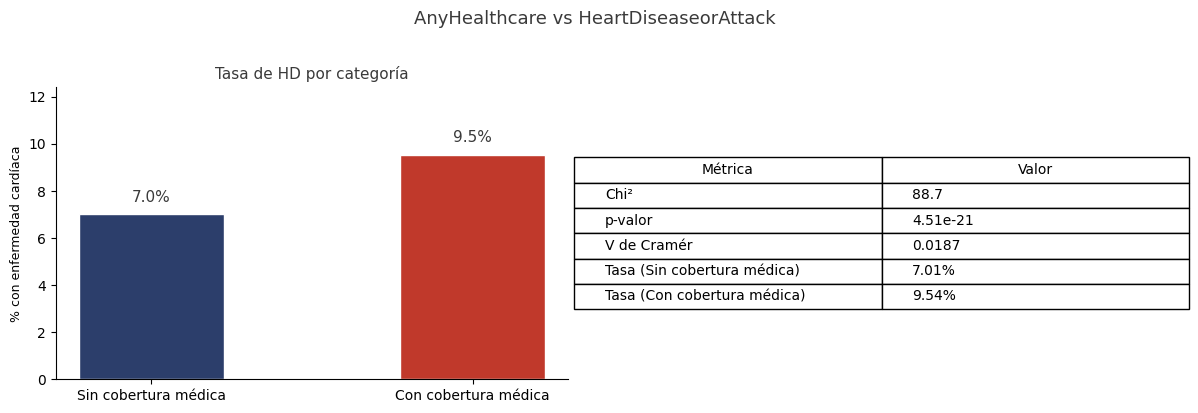

In [54]:
# AnyHealthcare — bivariado
ct_anyhealthcare = pd.crosstab(df["AnyHealthcare"], df[target])
chi2_anyhealthcare, p_anyhealthcare, _, _ = chi2_contingency(ct_anyhealthcare)
n = ct_anyhealthcare.values.sum()
cramer_anyhealthcare = np.sqrt(chi2_anyhealthcare / (n * (min(ct_anyhealthcare.shape) - 1)))

tasa_anyhealthcare = df.groupby("AnyHealthcare")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Sin cobertura médica', 'Con cobertura médica'], tasa_anyhealthcare.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_anyhealthcare.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_anyhealthcare.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Sin cobertura médica)", f"Tasa (Con cobertura médica)"],
    "Valor"   : [f"{chi2_anyhealthcare:.1f}", f"{p_anyhealthcare:.2e}",
                 f"{cramer_anyhealthcare:.4f}", f"{tasa_anyhealthcare.values[0]:.2f}%",
                 f"{tasa_anyhealthcare.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"AnyHealthcare vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


Tener cobertura médica se asocia a una tasa ligeramente mayor (9.54% vs 7.01%), con la V más baja entre las binarias (0.0187). Nuevamente un sesgo de detección: quienes tienen acceso al sistema de salud reciben más diagnósticos.

#### ***4.2.11 NoDocbcCost***

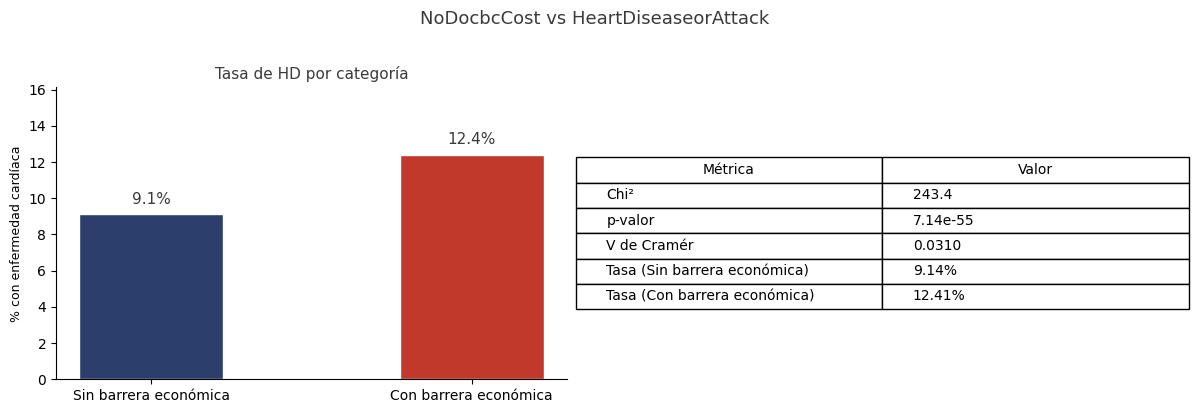

In [55]:
# NoDocbcCost — bivariado
ct_nodocbccost = pd.crosstab(df["NoDocbcCost"], df[target])
chi2_nodocbccost, p_nodocbccost, _, _ = chi2_contingency(ct_nodocbccost)
n = ct_nodocbccost.values.sum()
cramer_nodocbccost = np.sqrt(chi2_nodocbccost / (n * (min(ct_nodocbccost.shape) - 1)))

tasa_nodocbccost = df.groupby("NoDocbcCost")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Sin barrera económica', 'Con barrera económica'], tasa_nodocbccost.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_nodocbccost.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_nodocbccost.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Sin barrera económica)", f"Tasa (Con barrera económica)"],
    "Valor"   : [f"{chi2_nodocbccost:.1f}", f"{p_nodocbccost:.2e}",
                 f"{cramer_nodocbccost:.4f}", f"{tasa_nodocbccost.values[0]:.2f}%",
                 f"{tasa_nodocbccost.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"NoDocbcCost vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


La barrera económica para acceder al médico eleva la tasa de HD al 12.41% vs 9.14%, con V=0.0310. Aunque la magnitud es baja, refleja desigualdades en el acceso a atención preventiva oportuna.

#### ***4.2.12 DiffWalk***

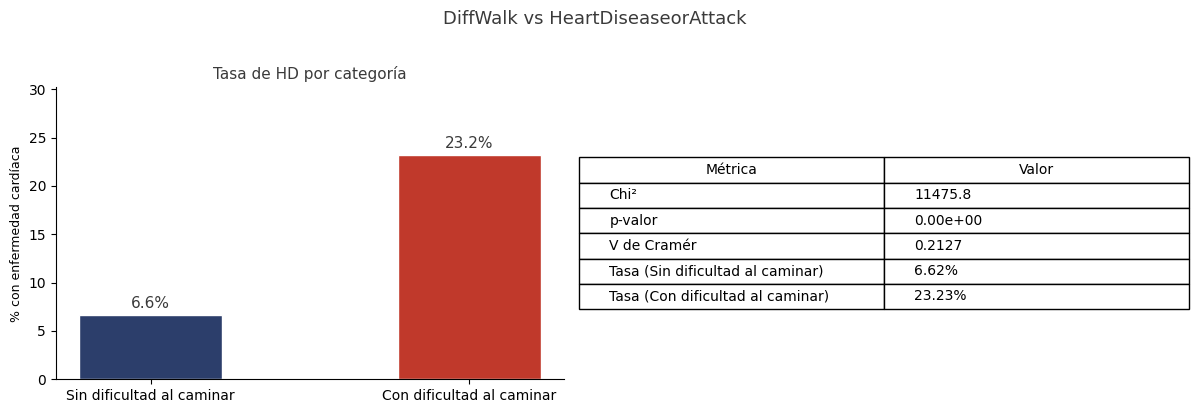

In [56]:
# DiffWalk — bivariado
ct_diffwalk = pd.crosstab(df["DiffWalk"], df[target])
chi2_diffwalk, p_diffwalk, _, _ = chi2_contingency(ct_diffwalk)
n = ct_diffwalk.values.sum()
cramer_diffwalk = np.sqrt(chi2_diffwalk / (n * (min(ct_diffwalk.shape) - 1)))

tasa_diffwalk = df.groupby("DiffWalk")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Sin dificultad al caminar', 'Con dificultad al caminar'], tasa_diffwalk.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_diffwalk.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_diffwalk.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Sin dificultad al caminar)", f"Tasa (Con dificultad al caminar)"],
    "Valor"   : [f"{chi2_diffwalk:.1f}", f"{p_diffwalk:.2e}",
                 f"{cramer_diffwalk:.4f}", f"{tasa_diffwalk.values[0]:.2f}%",
                 f"{tasa_diffwalk.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"DiffWalk vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


DiffWalk tiene la **mayor V de Cramér entre las variables binarias** (0.2127). Quienes reportan dificultad para caminar presentan una tasa de HD 3.5 veces mayor (23.23% vs 6.62%), actuando como marcador de deterioro funcional generalizado.

#### ***4.2.13 Sex***

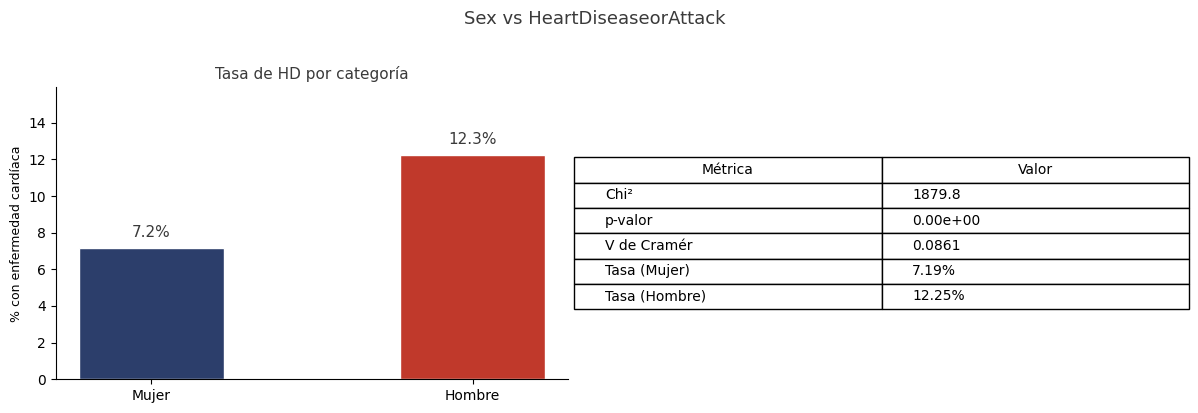

In [57]:
# Sex — bivariado
ct_sex = pd.crosstab(df["Sex"], df[target])
chi2_sex, p_sex, _, _ = chi2_contingency(ct_sex)
n = ct_sex.values.sum()
cramer_sex = np.sqrt(chi2_sex / (n * (min(ct_sex.shape) - 1)))

tasa_sex = df.groupby("Sex")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de tasas
bars = axes[0].bar(['Mujer', 'Hombre'], tasa_sex.values,
                   color=[bajo_color, riesgo_color], width=0.45, edgecolor="white")
for bar, val in zip(bars, tasa_sex.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=11, color="#3a3a3a")
axes[0].set_title("Tasa de HD por categoría", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
axes[0].set_ylim(0, max(tasa_sex.values) * 1.3)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica" : ["Chi²", "p-valor", "V de Cramér", f"Tasa (Mujer)", f"Tasa (Hombre)"],
    "Valor"   : [f"{chi2_sex:.1f}", f"{p_sex:.2e}",
                 f"{cramer_sex:.4f}", f"{tasa_sex.values[0]:.2f}%",
                 f"{tasa_sex.values[1]:.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"Sex vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


Los hombres presentan una tasa de HD casi el doble que las mujeres (12.25% vs 7.19%), con V=0.0861. La diferencia por sexo es consistente con la evidencia epidemiológica que señala mayor riesgo cardiovascular masculino en edades medias.

### ***4.3 Variables ordinales***

#### ***4.3.1 GenHlth***

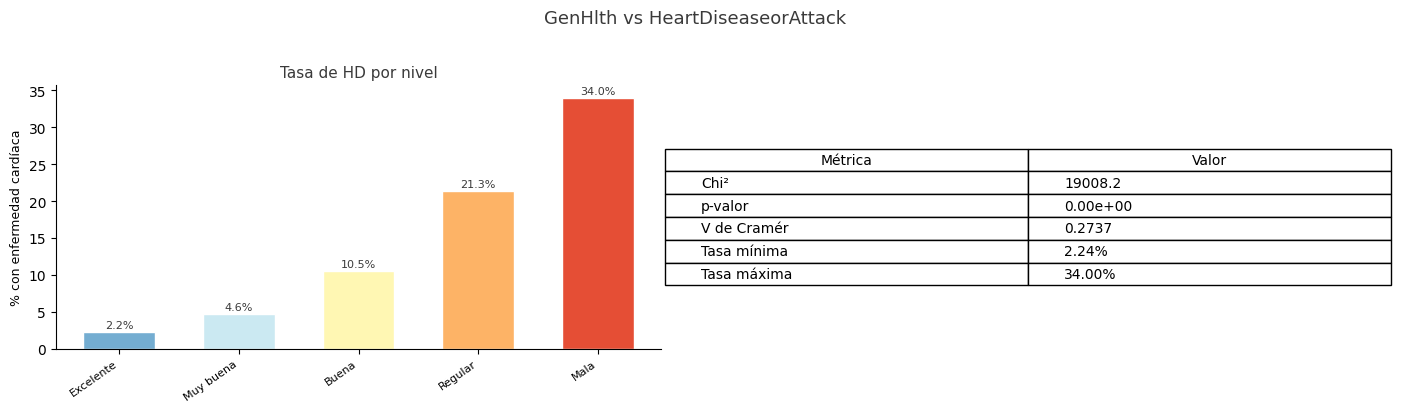

In [58]:
# GenHlth — bivariado
ct_genhlth = pd.crosstab(df["GenHlth"], df[target])
chi2_genhlth, p_genhlth, _, _ = chi2_contingency(ct_genhlth)
n = ct_genhlth.values.sum()
cramer_genhlth = np.sqrt(chi2_genhlth / (n * (min(ct_genhlth.shape) - 1)))

tasa_genhlth = df.groupby("GenHlth")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico de tasas por nivel
colors_ord = plt.cm.RdYlBu_r(np.linspace(0.2, 0.85, len(tasa_genhlth)))
bars = axes[0].bar(range(len(tasa_genhlth)), tasa_genhlth.values,
                   color=colors_ord, edgecolor="white", width=0.6)
axes[0].set_xticks(range(len(tasa_genhlth)))
axes[0].set_xticklabels(['Excelente', 'Muy buena', 'Buena', 'Regular', 'Mala'], rotation=35, ha="right", fontsize=8)
for bar, val in zip(bars, tasa_genhlth.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#3a3a3a")
axes[0].set_title("Tasa de HD por nivel", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica": ["Chi²", "p-valor", "V de Cramér", "Tasa mínima", "Tasa máxima"],
    "Valor"  : [f"{chi2_genhlth:.1f}", f"{p_genhlth:.2e}",
                f"{cramer_genhlth:.4f}",
                f"{tasa_genhlth.min():.2f}%",
                f"{tasa_genhlth.max():.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"GenHlth vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


**GenHlth es el predictor individual más fuerte del dataset** (V=0.2737). La tasa de HD sigue un gradiente perfectamente monótono desde 2.24% ('Excelente') hasta 34.0% ('Mala'), casi una relación lineal. La autopercepción de salud captura de forma integral el estado clínico del individuo.

#### ***4.3.2 Age***

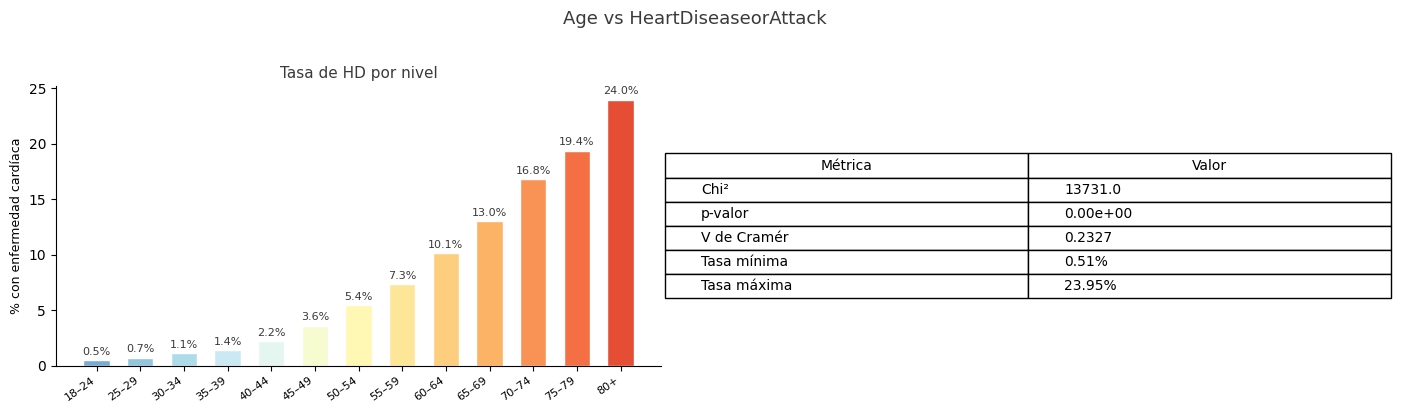

In [59]:
# Age — bivariado
ct_age = pd.crosstab(df["Age"], df[target])
chi2_age, p_age, _, _ = chi2_contingency(ct_age)
n = ct_age.values.sum()
cramer_age = np.sqrt(chi2_age / (n * (min(ct_age.shape) - 1)))

tasa_age = df.groupby("Age")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico de tasas por nivel
colors_ord = plt.cm.RdYlBu_r(np.linspace(0.2, 0.85, len(tasa_age)))
bars = axes[0].bar(range(len(tasa_age)), tasa_age.values,
                   color=colors_ord, edgecolor="white", width=0.6)
axes[0].set_xticks(range(len(tasa_age)))
axes[0].set_xticklabels(['18–24', '25–29', '30–34', '35–39', '40–44', '45–49', '50–54', '55–59', '60–64', '65–69', '70–74', '75–79', '80+'], rotation=35, ha="right", fontsize=8)
for bar, val in zip(bars, tasa_age.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#3a3a3a")
axes[0].set_title("Tasa de HD por nivel", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica": ["Chi²", "p-valor", "V de Cramér", "Tasa mínima", "Tasa máxima"],
    "Valor"  : [f"{chi2_age:.1f}", f"{p_age:.2e}",
                f"{cramer_age:.4f}",
                f"{tasa_age.min():.2f}%",
                f"{tasa_age.max():.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"Age vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


La edad (V=0.2327) muestra un gradiente monótono: la tasa de HD escala de 0.51% en el grupo 18–24 hasta 23.95% en mayores de 80 años. El envejecimiento acumula exposición a factores de riesgo y deterioro vascular progresivo.

#### ***4.3.3 Education***

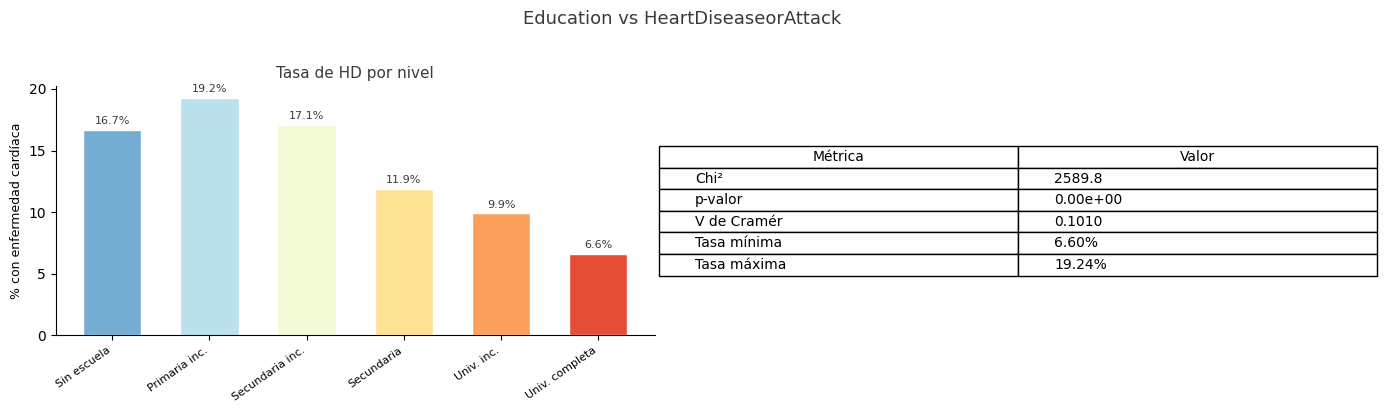

In [60]:
# Education — bivariado
ct_education = pd.crosstab(df["Education"], df[target])
chi2_education, p_education, _, _ = chi2_contingency(ct_education)
n = ct_education.values.sum()
cramer_education = np.sqrt(chi2_education / (n * (min(ct_education.shape) - 1)))

tasa_education = df.groupby("Education")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico de tasas por nivel
colors_ord = plt.cm.RdYlBu_r(np.linspace(0.2, 0.85, len(tasa_education)))
bars = axes[0].bar(range(len(tasa_education)), tasa_education.values,
                   color=colors_ord, edgecolor="white", width=0.6)
axes[0].set_xticks(range(len(tasa_education)))
axes[0].set_xticklabels(['Sin escuela', 'Primaria inc.', 'Secundaria inc.', 'Secundaria', 'Univ. inc.', 'Univ. completa'], rotation=35, ha="right", fontsize=8)
for bar, val in zip(bars, tasa_education.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#3a3a3a")
axes[0].set_title("Tasa de HD por nivel", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica": ["Chi²", "p-valor", "V de Cramér", "Tasa mínima", "Tasa máxima"],
    "Valor"  : [f"{chi2_education:.1f}", f"{p_education:.2e}",
                f"{cramer_education:.4f}",
                f"{tasa_education.min():.2f}%",
                f"{tasa_education.max():.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"Education vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


La educación muestra un **gradiente inverso** (V=0.1010): a mayor nivel educativo, menor tasa de HD. Los grupos sin escolarización alcanzan tasas de 16–19%, mientras que los universitarios completos llegan a 6.6%, evidenciando el rol de la educación como determinante social de la salud.

#### ***4.3.4 Income***

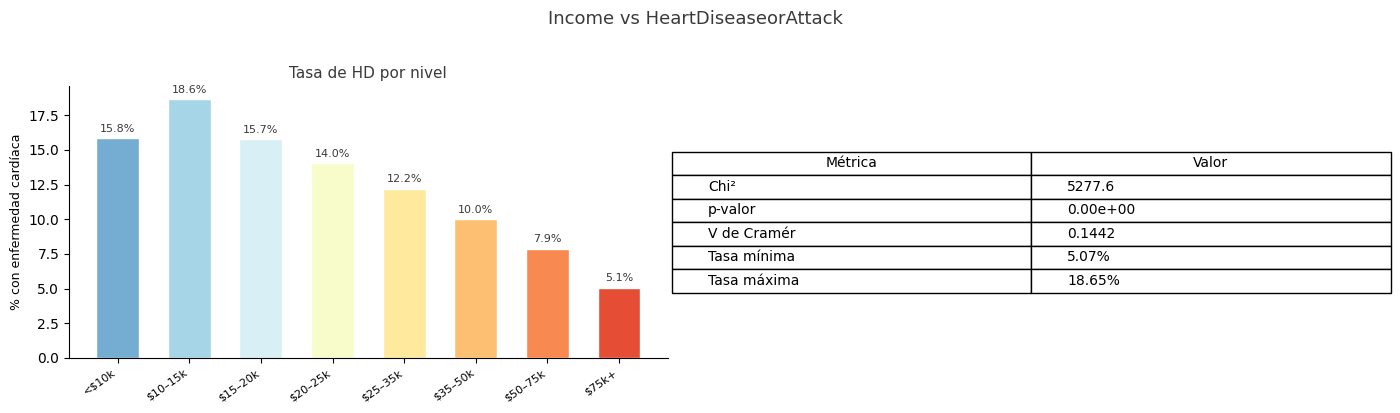

In [61]:
# Income — bivariado
ct_income = pd.crosstab(df["Income"], df[target])
chi2_income, p_income, _, _ = chi2_contingency(ct_income)
n = ct_income.values.sum()
cramer_income = np.sqrt(chi2_income / (n * (min(ct_income.shape) - 1)))

tasa_income = df.groupby("Income")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico de tasas por nivel
colors_ord = plt.cm.RdYlBu_r(np.linspace(0.2, 0.85, len(tasa_income)))
bars = axes[0].bar(range(len(tasa_income)), tasa_income.values,
                   color=colors_ord, edgecolor="white", width=0.6)
axes[0].set_xticks(range(len(tasa_income)))
axes[0].set_xticklabels(['<$10k', '$10–15k', '$15–20k', '$20–25k', '$25–35k', '$35–50k', '$50–75k', '$75k+'], rotation=35, ha="right", fontsize=8)
for bar, val in zip(bars, tasa_income.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#3a3a3a")
axes[0].set_title("Tasa de HD por nivel", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica": ["Chi²", "p-valor", "V de Cramér", "Tasa mínima", "Tasa máxima"],
    "Valor"  : [f"{chi2_income:.1f}", f"{p_income:.2e}",
                f"{cramer_income:.4f}",
                f"{tasa_income.min():.2f}%",
                f"{tasa_income.max():.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"Income vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


El ingreso presenta el **gradiente inverso más claro entre las ordinales** (V=0.1442): la tasa cae de 18.65% en el tramo $10–15k hasta 5.07% en ingresos superiores a $75k. El acceso a recursos económicos facilita atención médica preventiva, mejor alimentación y menor estrés crónico.

#### ***4.3.5 Diabetes***

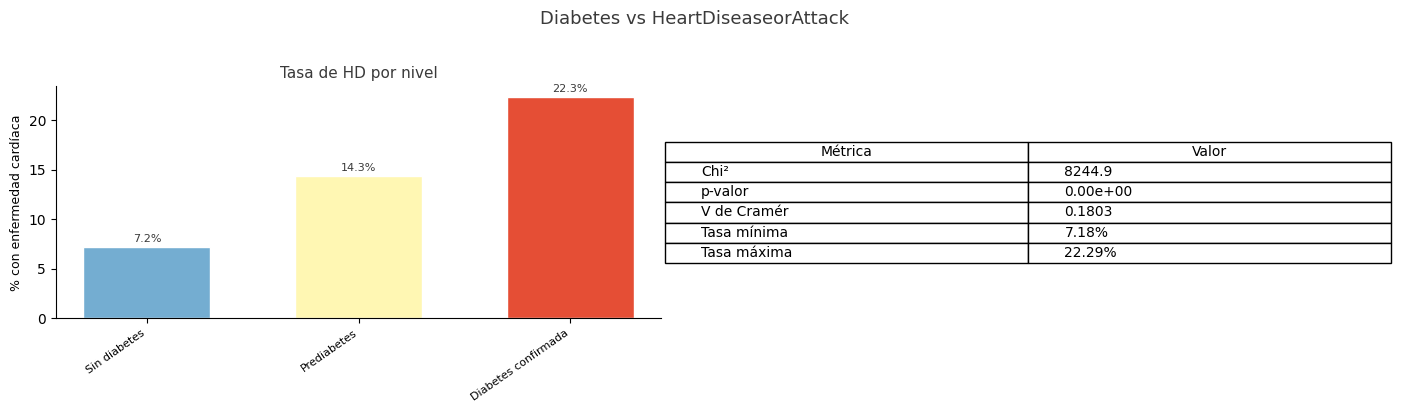

In [62]:
# Diabetes — bivariado
ct_diabetes = pd.crosstab(df["Diabetes"], df[target])
chi2_diabetes, p_diabetes, _, _ = chi2_contingency(ct_diabetes)
n = ct_diabetes.values.sum()
cramer_diabetes = np.sqrt(chi2_diabetes / (n * (min(ct_diabetes.shape) - 1)))

tasa_diabetes = df.groupby("Diabetes")[target].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico de tasas por nivel
colors_ord = plt.cm.RdYlBu_r(np.linspace(0.2, 0.85, len(tasa_diabetes)))
bars = axes[0].bar(range(len(tasa_diabetes)), tasa_diabetes.values,
                   color=colors_ord, edgecolor="white", width=0.6)
axes[0].set_xticks(range(len(tasa_diabetes)))
axes[0].set_xticklabels(['Sin diabetes', 'Prediabetes', 'Diabetes confirmada'], rotation=35, ha="right", fontsize=8)
for bar, val in zip(bars, tasa_diabetes.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#3a3a3a")
axes[0].set_title("Tasa de HD por nivel", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("% con enfermedad cardíaca", fontsize=9)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica": ["Chi²", "p-valor", "V de Cramér", "Tasa mínima", "Tasa máxima"],
    "Valor"  : [f"{chi2_diabetes:.1f}", f"{p_diabetes:.2e}",
                f"{cramer_diabetes:.4f}",
                f"{tasa_diabetes.min():.2f}%",
                f"{tasa_diabetes.max():.2f}%"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

fig.suptitle(f"Diabetes vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


La diabetes muestra un gradiente escalonado claro (V=0.1803): sin diabetes 7.18%, prediabetes 14.34% y diabetes confirmada 22.29%, **triplicando el riesgo basal**. La hiperglucemia crónica daña directamente el endotelio vascular y favorece la aterosclerosis acelerada.

### ***4.4 Variables continuas***

#### ***4.4.1 BMI***

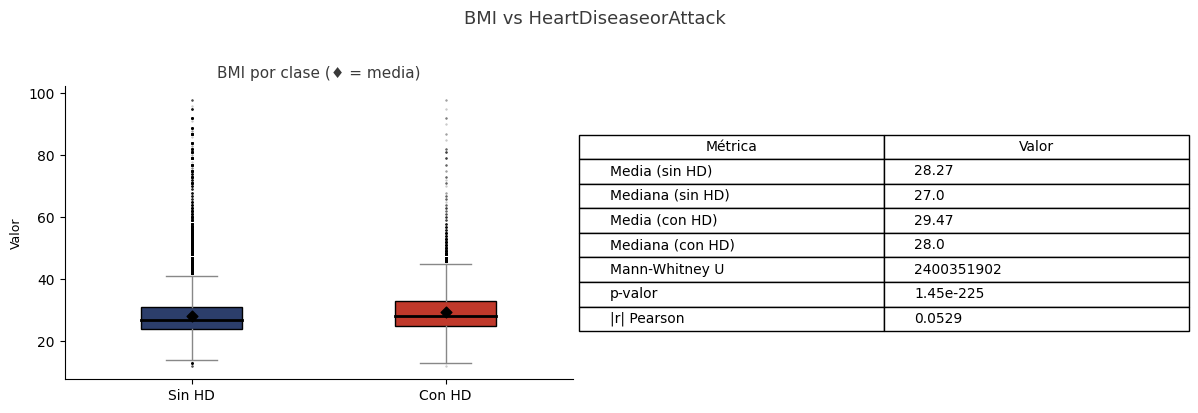

In [63]:
# BMI — bivariado
g0_bmi = df[df[target]==0]["BMI"]
g1_bmi = df[df[target]==1]["BMI"]
stat_bmi, p_bmi = mannwhitneyu(g0_bmi, g1_bmi, alternative='two-sided')
r_bmi = abs(df[["BMI", target]].corr().loc["BMI", target])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot comparativo
bp = axes[0].boxplot([g0_bmi, g1_bmi],
                     labels=["Sin HD", "Con HD"],
                     patch_artist=True, widths=0.4,
                     medianprops=dict(color="black", linewidth=2),
                     whiskerprops=dict(color="#888"),
                     capprops=dict(color="#888"),
                     flierprops=dict(marker=".", markersize=1.2, alpha=0.25, color="#bbb"))
bp["boxes"][0].set_facecolor(bajo_color)
bp["boxes"][1].set_facecolor(riesgo_color)
for j, d in enumerate([g0_bmi, g1_bmi], 1):
    axes[0].scatter(j, d.mean(), color="black", zorder=5, s=30, marker="D")
axes[0].set_title(f"BMI por clase (♦ = media)", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("Valor", fontsize=9)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica": ["Media (sin HD)", "Mediana (sin HD)", "Media (con HD)", "Mediana (con HD)",
                "Mann-Whitney U", "p-valor", "|r| Pearson"],
    "Valor"  : [f"{g0_bmi.mean():.2f}", f"{g0_bmi.median():.1f}",
                f"{g1_bmi.mean():.2f}", f"{g1_bmi.median():.1f}",
                f"{stat_bmi:.0f}", f"{p_bmi:.2e}",
                f"{r_bmi:.4f}"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.55)

fig.suptitle(f"BMI vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


Aunque la diferencia de medias es modesta (29.47 vs 28.27), la prueba Mann-Whitney es altamente significativa. El |r| de Pearson es bajo (0.0529), lo que indica que BMI por sí solo tiene poder discriminatorio limitado, aunque contribuye en modelos multivariados junto con otros factores de riesgo metabólico.

#### ***4.4.2 MentHlth***

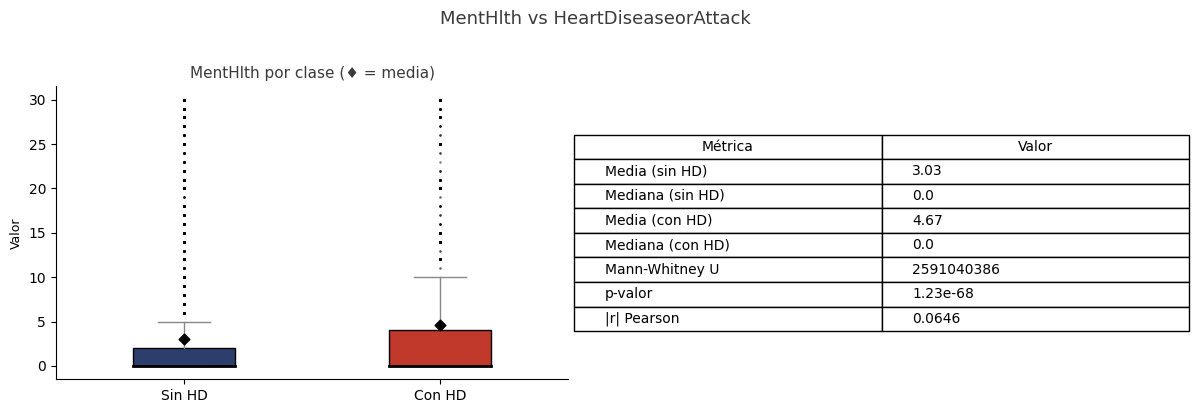

In [64]:
# MentHlth — bivariado
g0_menthlth = df[df[target]==0]["MentHlth"]
g1_menthlth = df[df[target]==1]["MentHlth"]
stat_menthlth, p_menthlth = mannwhitneyu(g0_menthlth, g1_menthlth, alternative='two-sided')
r_menthlth = abs(df[["MentHlth", target]].corr().loc["MentHlth", target])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot comparativo
bp = axes[0].boxplot([g0_menthlth, g1_menthlth],
                     labels=["Sin HD", "Con HD"],
                     patch_artist=True, widths=0.4,
                     medianprops=dict(color="black", linewidth=2),
                     whiskerprops=dict(color="#888"),
                     capprops=dict(color="#888"),
                     flierprops=dict(marker=".", markersize=1.2, alpha=0.25, color="#bbb"))
bp["boxes"][0].set_facecolor(bajo_color)
bp["boxes"][1].set_facecolor(riesgo_color)
for j, d in enumerate([g0_menthlth, g1_menthlth], 1):
    axes[0].scatter(j, d.mean(), color="black", zorder=5, s=30, marker="D")
axes[0].set_title(f"MentHlth por clase (♦ = media)", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("Valor", fontsize=9)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica": ["Media (sin HD)", "Mediana (sin HD)", "Media (con HD)", "Mediana (con HD)",
                "Mann-Whitney U", "p-valor", "|r| Pearson"],
    "Valor"  : [f"{g0_menthlth.mean():.2f}", f"{g0_menthlth.median():.1f}",
                f"{g1_menthlth.mean():.2f}", f"{g1_menthlth.median():.1f}",
                f"{stat_menthlth:.0f}", f"{p_menthlth:.2e}",
                f"{r_menthlth:.4f}"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.55)

fig.suptitle(f"MentHlth vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


Las personas con enfermedad cardíaca reportan en promedio 1.6 días más de mala salud mental (4.67 vs 3.03). Ambos grupos tienen mediana 0, pero el grupo enfermo tiene colas más pesadas. La asociación es significativa aunque de magnitud baja (|r|=0.0646), reflejando la relación bidireccional entre salud mental y cardiovascular.

#### ***4.4.3 PhysHlth***

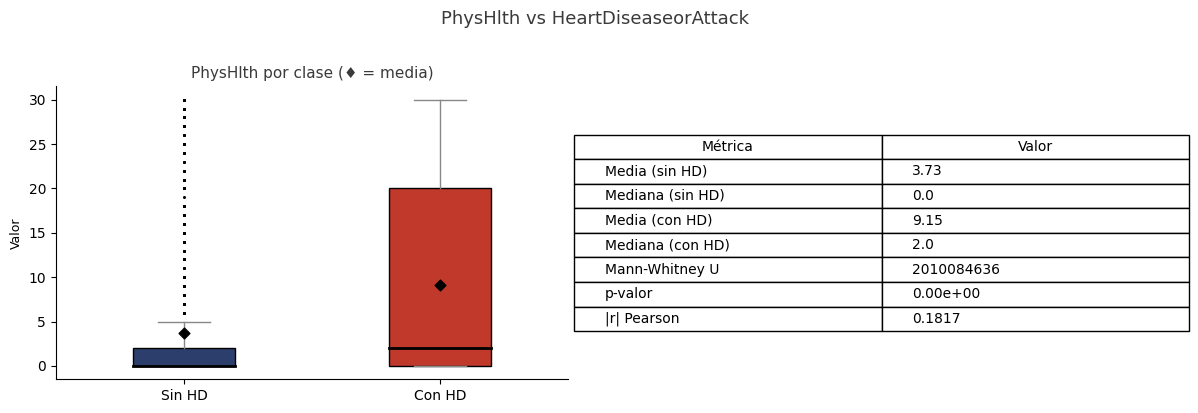

In [65]:
# PhysHlth — bivariado
g0_physhlth = df[df[target]==0]["PhysHlth"]
g1_physhlth = df[df[target]==1]["PhysHlth"]
stat_physhlth, p_physhlth = mannwhitneyu(g0_physhlth, g1_physhlth, alternative='two-sided')
r_physhlth = abs(df[["PhysHlth", target]].corr().loc["PhysHlth", target])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot comparativo
bp = axes[0].boxplot([g0_physhlth, g1_physhlth],
                     labels=["Sin HD", "Con HD"],
                     patch_artist=True, widths=0.4,
                     medianprops=dict(color="black", linewidth=2),
                     whiskerprops=dict(color="#888"),
                     capprops=dict(color="#888"),
                     flierprops=dict(marker=".", markersize=1.2, alpha=0.25, color="#bbb"))
bp["boxes"][0].set_facecolor(bajo_color)
bp["boxes"][1].set_facecolor(riesgo_color)
for j, d in enumerate([g0_physhlth, g1_physhlth], 1):
    axes[0].scatter(j, d.mean(), color="black", zorder=5, s=30, marker="D")
axes[0].set_title(f"PhysHlth por clase (♦ = media)", fontsize=11, color="#3a3a3a")
axes[0].set_ylabel("Valor", fontsize=9)
sns.despine(ax=axes[0])

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica": ["Media (sin HD)", "Mediana (sin HD)", "Media (con HD)", "Mediana (con HD)",
                "Mann-Whitney U", "p-valor", "|r| Pearson"],
    "Valor"  : [f"{g0_physhlth.mean():.2f}", f"{g0_physhlth.median():.1f}",
                f"{g1_physhlth.mean():.2f}", f"{g1_physhlth.median():.1f}",
                f"{stat_physhlth:.0f}", f"{p_physhlth:.2e}",
                f"{r_physhlth:.4f}"]
})
axes[1].axis("off")
tbl = axes[1].table(cellText=metricas.values, colLabels=metricas.columns,
                    loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.55)

fig.suptitle(f"PhysHlth vs HeartDiseaseorAttack", fontsize=13, color="#3a3a3a", y=1.02)
plt.tight_layout()
plt.show()


**PhysHlth es la variable continua con mayor asociación** (|r|=0.1817). Las personas con HD reportan en promedio 9.15 días de mala salud física vs 3.73 en el grupo sano — una diferencia de 5.4 días. La mediana del grupo enfermo sube a 2.0 (vs 0.0), confirmando que la mala salud física es notoriamente más persistente en quienes padecen enfermedad cardíaca.

### ***4.5 Interacciones entre factores de riesgo***

Se exploran combinaciones de los factores con mayor V de Cramér para detectar efectos sinérgicos sobre la tasa de enfermedad cardíaca.

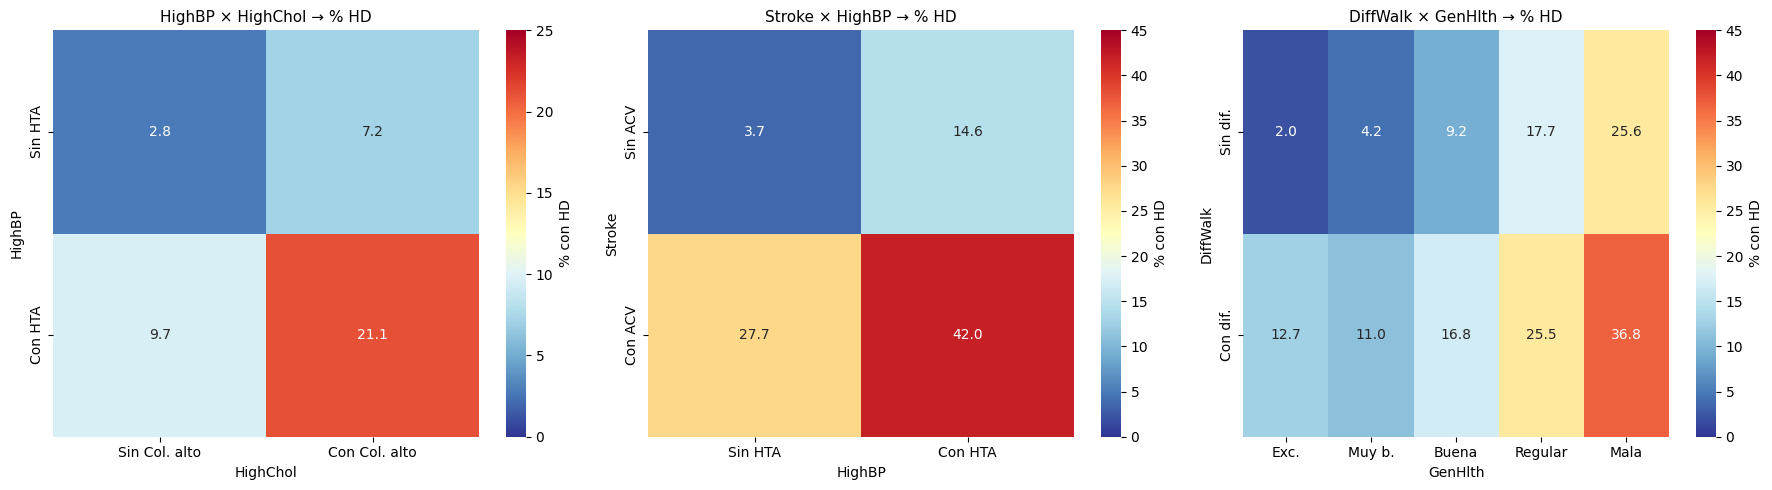

In [66]:
# Heatmap: HighBP x HighChol → tasa HD
pivot_bp_chol = df.pivot_table(values=target, index="HighBP",
                               columns="HighChol", aggfunc="mean") * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) HighBP x HighChol
sns.heatmap(pivot_bp_chol, annot=True, fmt=".1f", cmap="RdYlBu_r",
            vmin=0, vmax=25, ax=axes[0],
            xticklabels=["Sin Col. alto","Con Col. alto"],
            yticklabels=["Sin HTA","Con HTA"],
            cbar_kws={"label":"% con HD"})
axes[0].set_title("HighBP × HighChol → % HD", fontsize=11)

# 2) Stroke x HighBP → tasa HD
pivot_st_bp = df.pivot_table(values=target, index="Stroke",
                             columns="HighBP", aggfunc="mean") * 100
sns.heatmap(pivot_st_bp, annot=True, fmt=".1f", cmap="RdYlBu_r",
            vmin=0, vmax=45, ax=axes[1],
            xticklabels=["Sin HTA","Con HTA"],
            yticklabels=["Sin ACV","Con ACV"],
            cbar_kws={"label":"% con HD"})
axes[1].set_title("Stroke × HighBP → % HD", fontsize=11)

# 3) DiffWalk x GenHlth → tasa HD
pivot_dw_gh = df.pivot_table(values=target, index="DiffWalk",
                             columns="GenHlth", aggfunc="mean") * 100
sns.heatmap(pivot_dw_gh, annot=True, fmt=".1f", cmap="RdYlBu_r",
            vmin=0, vmax=45, ax=axes[2],
            xticklabels=["Exc.","Muy b.","Buena","Regular","Mala"],
            yticklabels=["Sin dif.","Con dif."],
            cbar_kws={"label":"% con HD"})
axes[2].set_title("DiffWalk × GenHlth → % HD", fontsize=11)

plt.tight_layout()
plt.show()


Las interacciones revelan efectos sinérgicos notables:

- **HighBP × HighChol**: La concurrencia de hipertensión y colesterol alto eleva la tasa al **21.1%**, frente al 2.8% cuando ninguno de los dos está presente — una diferencia de 7.5 veces. Este efecto multiplicativo supera la simple suma de los efectos individuales.  
- **Stroke × HighBP**: Cuando coexisten antecedente de ACV e hipertensión, la tasa alcanza el **42.0%**, lo que convierte a esta combinación en la de mayor riesgo detectada en el análisis.  
- **DiffWalk × GenHlth**: Las personas con dificultad para caminar y salud autopercibida "Mala" alcanzan una tasa del **36.8%**, confirmando que la combinación de limitación funcional y percepción negativa de salud es un marcador de riesgo muy elevado.

### ***4.6 Ranking de importancia de variables (síntesis bivariada)***

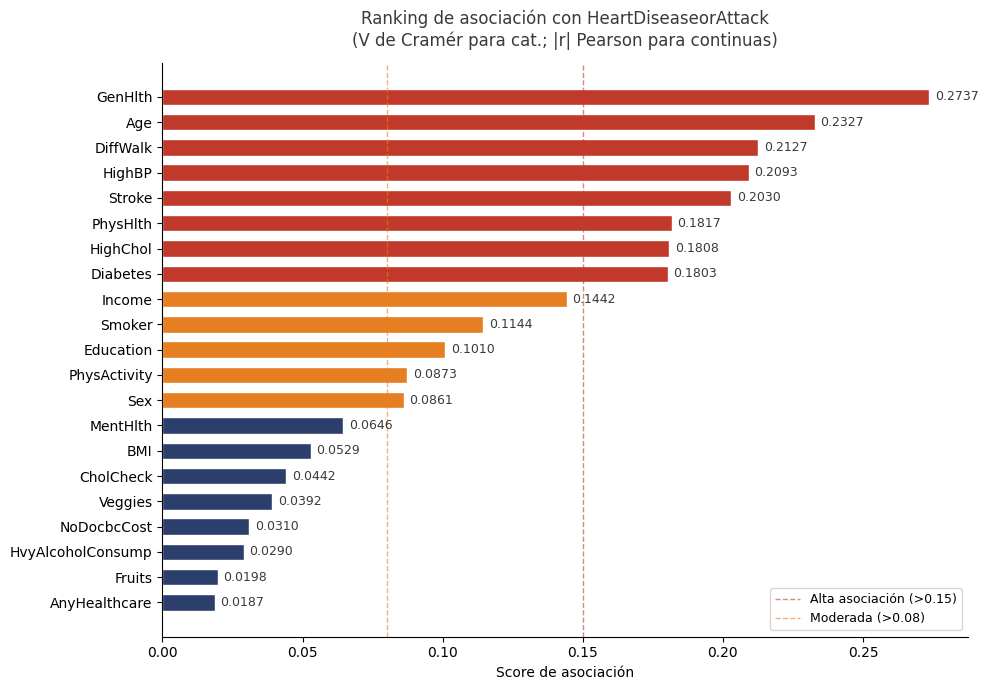

In [67]:
# Consolidar V de Cramér / correlación absoluta
all_vars = binary_vars + ordinal_vars + continuous_vars
scores = []

for v in binary_vars + ordinal_vars:
    ct = pd.crosstab(df[v], df[target])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    cramer = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    scores.append({"Variable": v, "Métrica": "V de Cramér", "Score": round(cramer, 4)})

for v in continuous_vars:
    r = abs(df[[v, target]].corr().loc[v, target])
    scores.append({"Variable": v, "Métrica": "|Pearson r|", "Score": round(r, 4)})

df_scores = pd.DataFrame(scores).sort_values("Score", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_rank = [nude_palette[0] if s > 0.15 else (
               "#E67E22" if s > 0.08 else nude_palette[1]) 
               for s in df_scores["Score"]]

bars = ax.barh(df_scores["Variable"][::-1], df_scores["Score"][::-1],
               color=colors_rank[::-1], edgecolor="white", height=0.65)

for bar, val in zip(bars, df_scores["Score"][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, color="#3a3a3a")

ax.axvline(0.15, color=nude_palette[0], linestyle="--", linewidth=1, alpha=0.6, label="Alta asociación (>0.15)")
ax.axvline(0.08, color="#E67E22", linestyle="--", linewidth=1, alpha=0.6, label="Moderada (>0.08)")
ax.legend(fontsize=9)
ax.set_title("Ranking de asociación con HeartDiseaseorAttack\n(V de Cramér para cat.; |r| Pearson para continuas)",
             fontsize=12, pad=12, color="#3a3a3a")
ax.set_xlabel("Score de asociación", fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


El ranking confirma que las **6 variables con mayor poder discriminatorio** son todas categóricas u ordinales:

| Posición | Variable | Score | Naturaleza |
|----------|----------|-------|------------|
| 1 | GenHlth | 0.2737 | Ordinal (autopercepción salud) |
| 2 | Age | 0.2327 | Ordinal (edad) |
| 3 | DiffWalk | 0.2127 | Binaria (limitación funcional) |
| 4 | HighBP | 0.2093 | Binaria (hipertensión) |
| 5 | Stroke | 0.2030 | Binaria (ACV previo) |
| 6 | HighChol | 0.1808 | Binaria (colesterol alto) |

Las variables continuas (BMI, MentHlth, PhysHlth) presentan correlaciones absolutas menores, aunque PhysHlth muestra la diferencia de medias más pronunciada entre grupos. Las variables de estilo de vida protector (Fruits, Veggies, HvyAlcoholConsump) tienen las asociaciones más débiles.

## ***5. Hallazgos Principales***

El análisis exploratorio sobre el dataset BRFSS 2015 permite extraer los siguientes hallazgos en relación con el objetivo general:


### ***5.1 Factores con mayor asociación con la enfermedad cardíaca***

**Factores clínicos y funcionales (alta magnitud):**
- La **autopercepción de salud general** (GenHlth, V=0.274) es el predictor individual más fuerte: la tasa de HD escala de forma casi lineal desde 2.2% ("Excelente") hasta 34.0% ("Mala").  
- La **edad** (V=0.233) confirma el efecto acumulativo del envejecimiento: cada grupo etario superior eleva la tasa de manera monotónica (0.5% a 24.0%).  
- La **dificultad para caminar** (DiffWalk, V=0.213) actúa como marcador de deterioro funcional: quienes la reportan tienen 3.5 veces más riesgo.  
- La **hipertensión arterial** (HighBP, V=0.209) cuadruplica el riesgo (16.5% vs 4.1%).  
- El **antecedente de ACV** (Stroke, V=0.203) presenta la tasa absoluta más alta entre las variables binarias (38.3%).  
- La **diabetes** (Diabetes, V=0.180) muestra un gradiente de riesgo triplicado entre sin diabetes y diabetes confirmada.

**Factores conductuales (magnitud moderada):**
- El **tabaquismo** (Smoker, V=0.114) duplica el riesgo (13.2% vs 6.4%).  
- La **inactividad física** (PhysActivity, V=0.087) se asocia a una tasa 1.75 veces mayor que en personas activas.  
- El **sexo** (Sex, V=0.086) muestra que los hombres tienen una tasa de HD del 12.3% frente al 7.2% en mujeres.

**Determinantes socioeconómicos (gradientes inversos):**
- A mayor **ingreso** y **nivel educativo**, menor tasa de enfermedad cardíaca, evidenciando inequidades en salud cardiovascular.


### ***5.2 Interacciones sinérgicas***

Las combinaciones de factores revelan efectos multiplicativos que superan los efectos individuales. La coexistencia de hipertensión y colesterol alto (HighBP × HighChol) eleva la tasa de enfermedad cardíaca al 21.1%, frente al 2.8% cuando ninguno está presente, una diferencia de 7.5 veces que evidencia un efecto claramente sinérgico. Aún más pronunciada es la combinación de ACV e hipertensión (Stroke × HighBP), que alcanza una tasa del 42.0%, la más alta registrada en todo el análisis bivariado. Por su parte, la combinación de dificultad para caminar y salud autopercibida "Mala" (DiffWalk × GenHlth) produce una tasa del 36.8%, confirmando que la limitación funcional asociada a una percepción negativa del estado de salud constituye uno de los perfiles de mayor riesgo cardiovascular en la muestra. En conjunto, estas interacciones refuerzan la naturaleza multifactorial de la enfermedad cardíaca y anticipan que los modelos predictivos se beneficiarán del uso de algoritmos capaces de capturar relaciones no lineales entre variables.

### ***5.3 Consideraciones para el modelado***

1. **Desbalance de clases** (90.6% vs 9.4%): Se requieren estrategias como SMOTE, class_weight o umbralización personalizada.  
2. **Variables prioritarias**: GenHlth, Age, DiffWalk, HighBP, Stroke y HighChol deben ser incluidas como features obligatorias.  
3. **Distribuciones asimétricas**: MentHlth, PhysHlth y BMI requieren transformación o uso de modelos robustos a outliers.  
4. **Variables con baja utilidad individual**: Fruits, AnyHealthcare y HvyAlcoholConsump presentan V de Cramér < 0.03 y podrían evaluarse para reducción dimensional.


## ***6. Modelado y selección de clasificador***

Tras completar el análisis exploratorio de datos, se procedió a la construcción y evaluación comparativa de cinco modelos de clasificación supervisada para predecir la presencia de enfermedad cardíaca: Regresión Logística, Random Forest, K-Nearest Neighbors, Linear SVC y XGBoost. Dado el marcado desbalance de clases del dataset (90.6% vs 9.4%), se aplicaron estrategias de compensación en cada modelo: class_weight="balanced" para los modelos de sklearn y scale_pos_weight=9.62 para XGBoost. El proceso se implementó mediante pipelines que integran preprocesamiento y clasificador en un único objeto, aplicando MinMaxScaler exclusivamente a las variables continuas y dejando pasar sin transformación las variables binarias y ordinales. 

La búsqueda de hiperparámetros se realizó con GridSearchCV de 5 folds estratificados, optimizando el Recall como métrica principal dado que en un contexto médico el error más costoso es no detectar a un paciente enfermo. Adicionalmente se evaluó el ajuste de umbral de decisión (threshold tuning) para analizar el trade-off entre Recall y Precision en el modelo ganador. Todos los modelos fueron evaluados en el conjunto de test con Accuracy, Precision, Recall, F1 y AUC-ROC.

scale_pos_weight para XGBoost: 9.62
Entrenando LogisticRegression...
  Recall: 0.7991 | F1: 0.376 | AUC: 0.8459
Entrenando RandomForest...
  Recall: 0.8157 | F1: 0.3574 | AUC: 0.8373
Entrenando KNeighbors...


  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


  Recall: 0.1846 | F1: 0.2269 | AUC: 0.669
Entrenando LinearSVC...
  Recall: 0.1241 | F1: 0.2008 | AUC: 0.846
Entrenando XGBoost...
  Recall: 0.8209 | F1: 0.3686 | AUC: 0.8483

── Ranking comparativo ──


Modelo,Accuracy,Precision,Recall,F1,AUC-ROC,Mejor Recall CV
XGBoost,0.735100,0.237600,0.820900,0.368600,0.848300,0.819700
RandomForest,0.723700,0.228800,0.815700,0.357400,0.837300,0.810200
LogisticRegression,0.750200,0.245800,0.799100,0.376000,0.845900,0.796000
KNeighbors,0.881500,0.294400,0.184600,0.226900,0.669000,0.194700
LinearSVC,0.907000,0.526200,0.124100,0.200800,0.846000,0.129400



Mejor modelo: XGBoost
Mejores hiperparámetros: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 1.0}


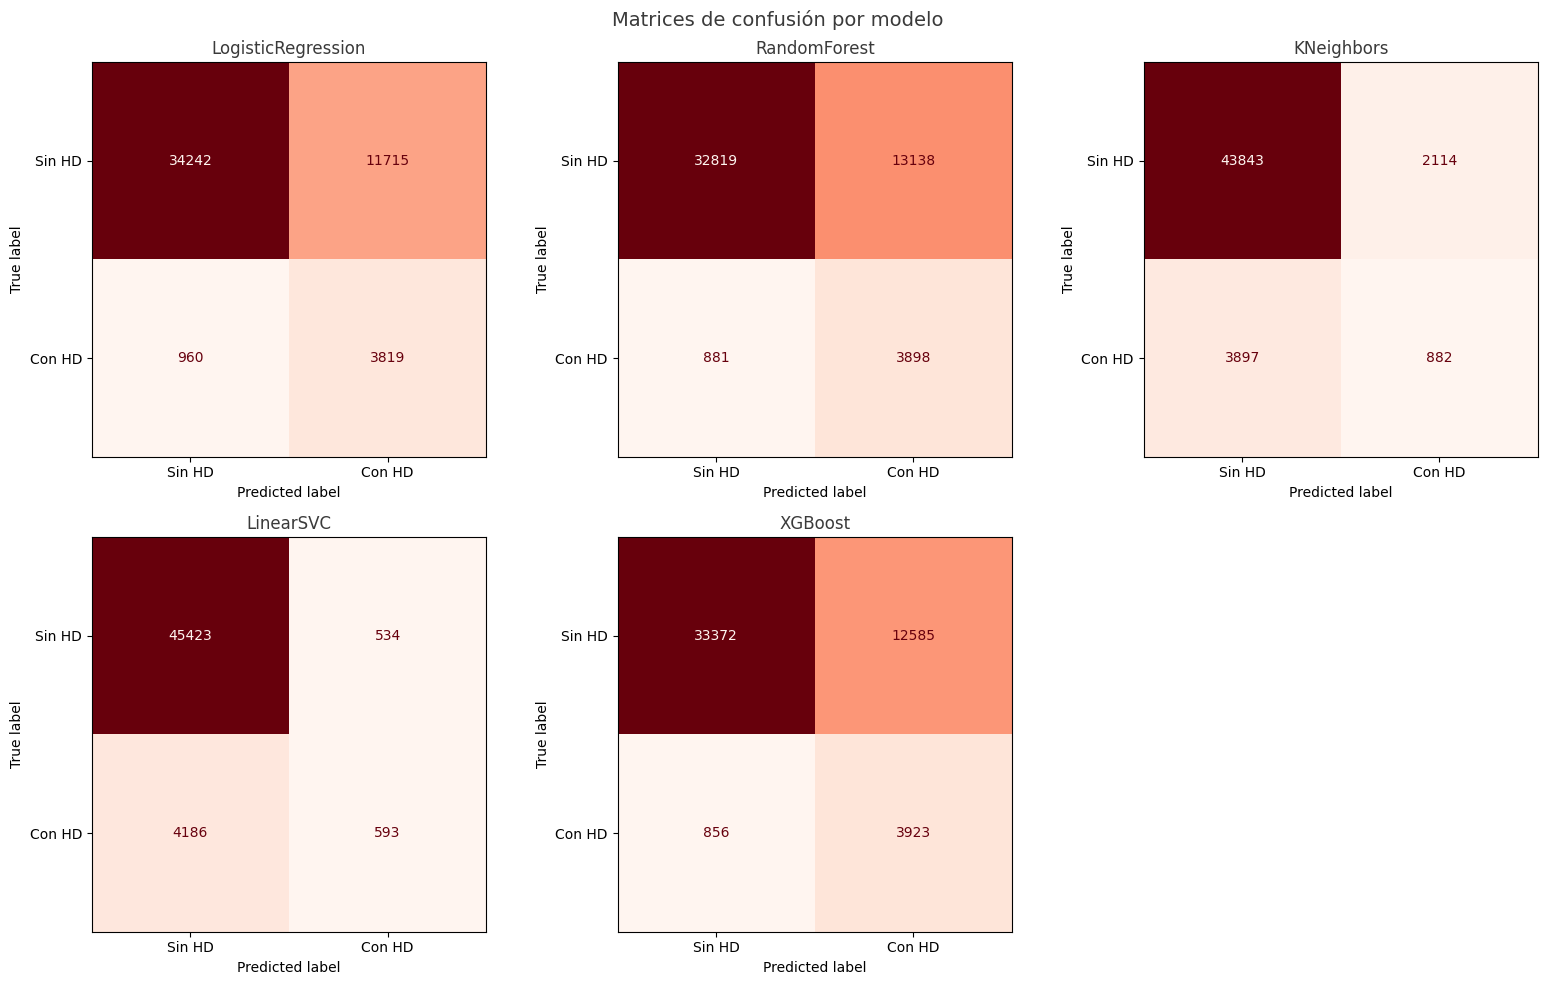

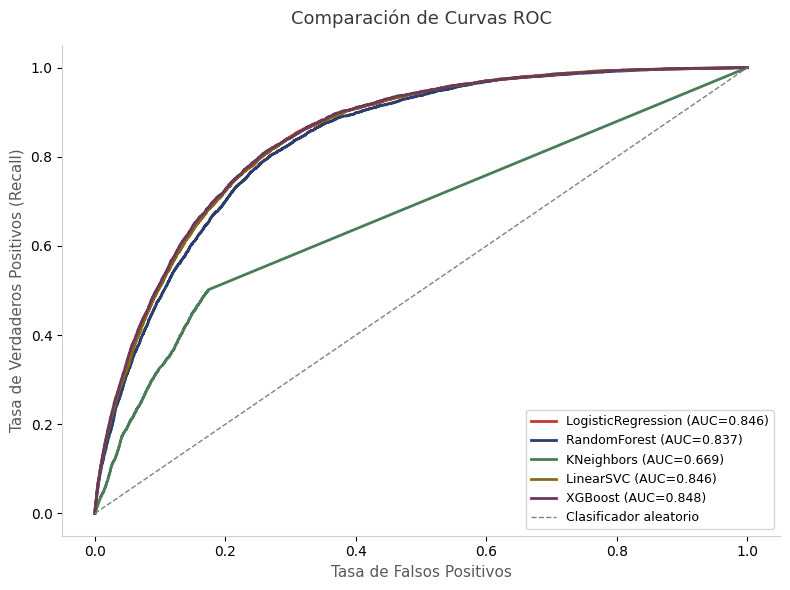

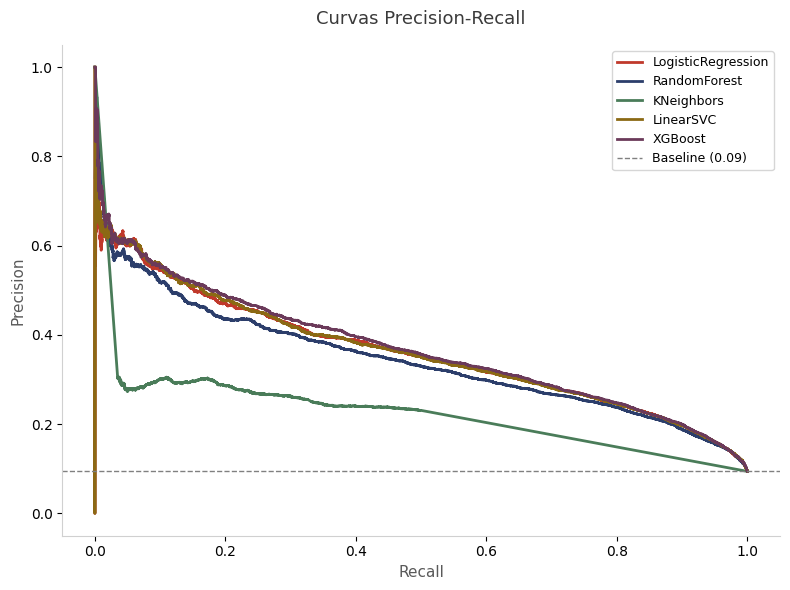


Umbral óptimo (mejor F1): 0.69


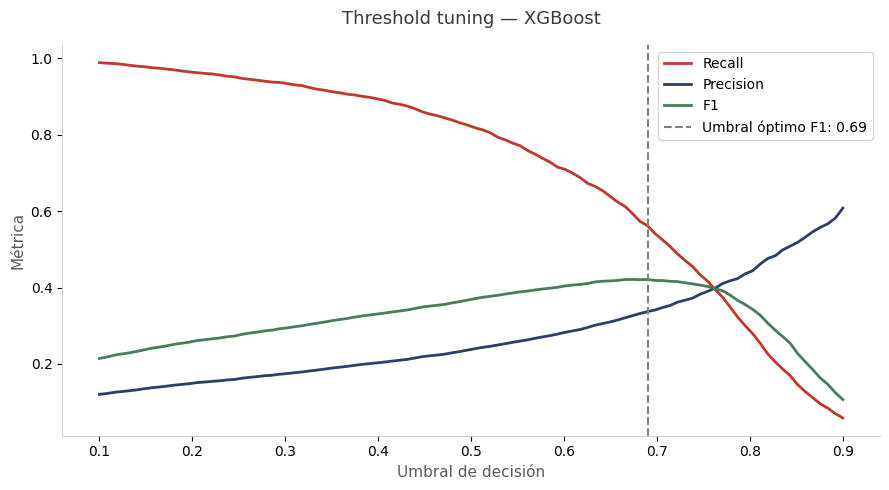


Evaluación con umbral óptimo (0.69):
  Recall    : 0.5616
  Precision : 0.3370
  F1        : 0.4212
  AUC-ROC   : 0.8483


In [ ]:
# =============================
# Librerías básicas
# =============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================
# Preprocesamiento y pipelines
# =============================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# =============================
# Modelos
# =============================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier

# =============================
# Métricas y evaluación
# =============================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)
#  1. Separar variables 
X = df.drop(columns="HeartDiseaseorAttack")
y = df["HeartDiseaseorAttack"]

num_cols = ["BMI", "MentHlth", "PhysHlth"]
ord_cols = ["GenHlth", "Age", "Education", "Income", "Diabetes"]
bin_cols = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
            "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
            "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"]

#  2. Split estratificado 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  3. Preprocesador corregido 
# MinMaxScaler solo a continuas, ordinales y binarias pasan sin escalar
preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), num_cols),
    ("ord", "passthrough",  ord_cols),
    ("bin", "passthrough",  bin_cols)
])

#  4. scale_pos_weight para XGBoost
negativos = (y_train == 0).sum()
positivos  = (y_train == 1).sum()
scale      = negativos / positivos
print(f"scale_pos_weight para XGBoost: {scale:.2f}")

#  5. Función de entrenamiento 
def train_pipeline(X_train, y_train, model, param_grid):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model)
    ])
    grid = GridSearchCV(
        pipe, param_grid,
        cv=5,
        scoring="recall",
        n_jobs=1,
        verbose=0
    )
    grid.fit(X_train, y_train)
    return grid

#  6. Definición de modelos 
modelos = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000, class_weight="balanced"),
        {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__solver": ["lbfgs", "liblinear"]
        }
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42, class_weight="balanced"),
        {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 5, 10],
            "clf__min_samples_split": [2, 5]
        }
    ),
    "KNeighbors": (
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 11],
            "clf__weights": ["uniform", "distance"]
        }
    ),
    "LinearSVC": (
        CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=2000)),
        {
            "clf__estimator__C": [0.01, 0.1, 1, 10]
        }
    ),
    "XGBoost": (
        XGBClassifier(
            random_state=42,
            scale_pos_weight=scale,
            eval_metric="logloss",
            verbosity=0
        ),
        {
            "clf__n_estimators":  [100, 200],
            "clf__max_depth":     [3, 5],
            "clf__learning_rate": [0.05, 0.1],
            "clf__subsample":     [0.8, 1.0]
        }
    )
}

#  7. Entrenamiento y evaluación 
resultados = []
grids_entrenados = {}

for nombre, (modelo, param_grid) in modelos.items():
    print(f"Entrenando {nombre}...")
    grid = train_pipeline(X_train, y_train, modelo, param_grid)
    grids_entrenados[nombre] = grid

    y_pred  = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo":          nombre,
        "Accuracy":        round(accuracy_score(y_test, y_pred), 4),
        "Precision":       round(precision_score(y_test, y_pred), 4),
        "Recall":          round(recall_score(y_test, y_pred), 4),
        "F1":              round(f1_score(y_test, y_pred), 4),
        "AUC-ROC":         round(roc_auc_score(y_test, y_proba), 4),
        "Mejor Recall CV": round(grid.best_score_, 4)
    })
    print(f"  Recall: {resultados[-1]['Recall']} | F1: {resultados[-1]['F1']} | AUC: {resultados[-1]['AUC-ROC']}")

#  8. Ranking comparativo 
df_resultados = pd.DataFrame(resultados).sort_values("Recall", ascending=False).reset_index(drop=True)
df_resultados.index += 1
print("\n── Ranking comparativo ──")
display(df_resultados.style.hide(axis="index"))

# 9. Mejor modelo
mejor_nombre = df_resultados.iloc[0]["Modelo"]
mejor_grid   = grids_entrenados[mejor_nombre]
print(f"\nMejor modelo: {mejor_nombre}")
print(f"Mejores hiperparámetros: {mejor_grid.best_params_}")

#  10. Matrices de confusión 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (nombre, grid) in enumerate(grids_entrenados.items()):
    y_pred = grid.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Sin HD", "Con HD"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Reds")
    axes[i].set_title(nombre, fontsize=12, color="#3a3a3a")

axes[-1].set_visible(False)
plt.suptitle("Matrices de confusión por modelo", fontsize=14, color="#3a3a3a")
plt.tight_layout()
plt.show()

#  11. Curvas ROC comparativas 
fig, ax = plt.subplots(figsize=(8, 6))

colores_roc = [nude_palette[0], nude_palette[1], "#4A7C59", "#8B6914", "#6B3A5A"]

for (nombre, grid), color in zip(grids_entrenados.items(), colores_roc):
    y_proba = grid.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{nombre} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos", fontsize=11, color="#5a5a5a")
ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)", fontsize=11, color="#5a5a5a")
ax.set_title("Comparación de Curvas ROC", fontsize=13, pad=15, color="#3a3a3a")
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")
plt.tight_layout()
plt.show()

# 12. Curvas Precision-Recall comparativas 
fig, ax = plt.subplots(figsize=(8, 6))

for (nombre, grid), color in zip(grids_entrenados.items(), colores_roc):
    y_proba = grid.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ax.plot(recall, precision, lw=2, color=color, label=nombre)

ax.axhline(y=positivos/(negativos+positivos), color="gray",
           linestyle="--", lw=1, label=f"Baseline ({positivos/(negativos+positivos):.2f})")
ax.set_xlabel("Recall", fontsize=11, color="#5a5a5a")
ax.set_ylabel("Precision", fontsize=11, color="#5a5a5a")
ax.set_title("Curvas Precision-Recall", fontsize=13, pad=15, color="#3a3a3a")
ax.legend(loc="upper right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")
plt.tight_layout()
plt.show()

# 13. Threshold tuning del mejor modelo 
y_scores = mejor_grid.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.1, 0.9, 100)
recalls_t, precisions_t, f1s_t = [], [], []

for t in thresholds:
    y_pred_t = (y_scores >= t).astype(int)
    recalls_t.append(recall_score(y_test, y_pred_t))
    precisions_t.append(precision_score(y_test, y_pred_t, zero_division=0))
    f1s_t.append(f1_score(y_test, y_pred_t, zero_division=0))

# umbral con mejor F1
best_t = thresholds[np.argmax(f1s_t)]
print(f"\nUmbral óptimo (mejor F1): {best_t:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, recalls_t,    color=nude_palette[0], lw=2, label="Recall")
ax.plot(thresholds, precisions_t, color=nude_palette[1], lw=2, label="Precision")
ax.plot(thresholds, f1s_t,        color="#4A7C59",        lw=2, label="F1")
ax.axvline(best_t, color="gray", linestyle="--", lw=1.5, label=f"Umbral óptimo F1: {best_t:.2f}")
ax.set_xlabel("Umbral de decisión", fontsize=11, color="#5a5a5a")
ax.set_ylabel("Métrica", fontsize=11, color="#5a5a5a")
ax.set_title(f"Threshold tuning — {mejor_nombre}", fontsize=13, pad=15, color="#3a3a3a")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")
plt.tight_layout()
plt.show()

# evaluación con umbral óptimo
y_pred_opt = (y_scores >= best_t).astype(int)
print(f"\nEvaluación con umbral óptimo ({best_t:.2f}):")
print(f"  Recall    : {recall_score(y_test, y_pred_opt):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_opt):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_opt):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_test, y_scores):.4f}")

La comparación de los cinco modelos confirma a XGBoost como el clasificador ganador, con el mejor Recall (0.8209), el mejor AUC-ROC (0.8483) y el mejor Recall en validación cruzada (0.8197), lo que indica que su rendimiento es consistente y no depende del conjunto de test específico. Random Forest quedó en segundo lugar con un Recall de 0.8157, muy cercano al XGBoost, mientras que Logistic Regression obtuvo un F1 ligeramente superior (0.3760) pero un Recall menor (0.7991). KNeighbors y LinearSVC fueron descartados por sus Recalls inaceptablemente bajos (0.1846 y 0.1260 respectivamente), comportándose en la práctica como modelos que ignoran la mayoría de los casos positivos, tal como se confirma visualmente en sus matrices de confusión donde KNeighbors detectó apenas 882 enfermos y LinearSVC 602 de los casi 4.800 casos reales.

Las curvas ROC y Precision-Recall refuerzan esta decisión. En la curva ROC, XGBoost, Logistic Regression y LinearSVC se separan claramente de KNeighbors, con AUCs superiores a 0.84. En la curva Precision-Recall, XGBoost y Logistic Regression dominan consistentemente por encima de la línea base de 0.09, confirmando que ambos modelos aportan valor real frente a un clasificador aleatorio.

Finalmente, el threshold tuning sobre XGBoost reveló que el umbral óptimo para F1 es 0.69, donde el F1 mejora de 0.3686 a 0.4212 y la Precision casi se duplica de 0.2376 a 0.3370, pero a costa de reducir el Recall a 0.5616. Dado que el objetivo del análisis es la detección preventiva de enfermedad cardíaca, donde no detectar un caso positivo tiene consecuencias clínicas graves, se mantuvo el umbral por defecto de 0.50, preservando el Recall de 0.8209 como criterio prioritario.

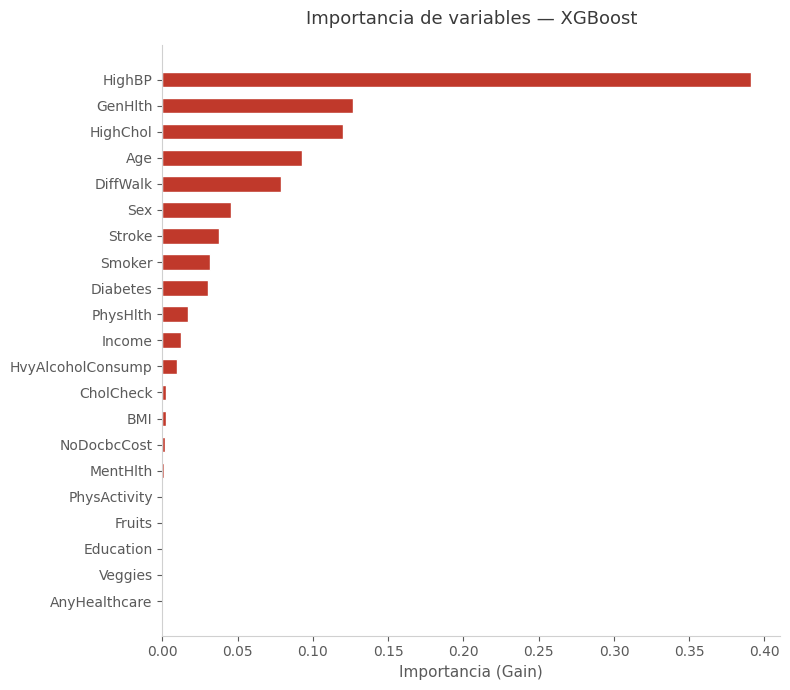

Variable,Importancia
HighBP,0.390786
GenHlth,0.126870
HighChol,0.120088
Age,0.092528
DiffWalk,0.078705
Sex,0.045233
Stroke,0.037250
Smoker,0.031567
Diabetes,0.029956
PhysHlth,0.017219


In [69]:
#  6. Importancia de variables
xgb_model = mejor_grid.best_estimator_.named_steps["clf"]
feature_names = num_cols + ord_cols + bin_cols
importancias = pd.DataFrame({
    "Variable":    feature_names,
    "Importancia": xgb_model.feature_importances_
}).sort_values("Importancia", ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importancias["Variable"], importancias["Importancia"],
        color=nude_palette[0], edgecolor="white", height=0.6)
ax.set_title("Importancia de variables — XGBoost", fontsize=13,
             pad=15, color="#3a3a3a")
ax.set_xlabel("Importancia (Gain)", fontsize=11, color="#5a5a5a")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")
ax.tick_params(colors="#5a5a5a")
plt.tight_layout()
plt.show()

# Tabla importancias ordenada de mayor a menor
display(importancias.sort_values("Importancia", ascending=False)
        .reset_index(drop=True).style.hide(axis="index"))

Con el objetivo de evaluar si era posible construir un modelo más parsimonioso sin sacrificar capacidad predictiva, se analizó la importancia de variables reportada por el modelo XGBoost entrenado con las 21 variables del dataset. Los resultados revelaron que cinco variables presentaban importancia exactamente igual a cero — Veggies, PhysActivity, Fruits, Education y AnyHealthcare — lo que indica que el algoritmo no las utilizó en ningún árbol de decisión durante el entrenamiento. Un segundo grupo conformado por CholCheck, BMI, NoDocbcCost y MentHlth presentó importancias menores a 0.003, contribuyendo de forma marginal al poder predictivo del modelo. 

Para verificar si estas variables podían eliminarse sin costo, se entrenaron tres versiones del XGBoost: el modelo completo con 21 variables, un modelo reducido A con 16 variables (eliminando las de importancia cero) y un modelo reducido B con las 12 variables de mayor importancia

In [70]:
#  Versión A: sin variables con importancia = 0 
vars_cero = ["Veggies", "PhysActivity", "Fruits", "Education", "AnyHealthcare"]
X_A = X.drop(columns=vars_cero)

#  Versión B: solo top 12 variables (importancia >= 0.01) 
top_vars = ["HighBP", "GenHlth", "HighChol", "Age", "DiffWalk",
            "Sex", "Stroke", "Smoker", "Diabetes", "PhysHlth",
            "Income", "HvyAlcoholConsump"]
X_B = X[top_vars]

# Función para entrenar y evaluar XGBoost con cualquier X 
def evaluar_xgb(X_input, nombre):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_input, y, test_size=0.2, random_state=42, stratify=y
    )

    negativos = (y_tr == 0).sum()
    positivos  = (y_tr == 1).sum()
    scale      = negativos / positivos

    # preprocesador adaptado a las columnas disponibles
    num_disponibles = [c for c in num_cols if c in X_input.columns]
    resto           = [c for c in X_input.columns if c not in num_disponibles]

    pre = ColumnTransformer([
        ("num", MinMaxScaler(), num_disponibles),
        ("resto", "passthrough", resto)
    ])

    pipe = Pipeline([
        ("preprocessor", pre),
        ("clf", XGBClassifier(
            random_state=42,
            scale_pos_weight=scale,
            eval_metric="logloss",
            verbosity=0,
            learning_rate=0.05,
            max_depth=3,
            n_estimators=100,
            subsample=1.0
        ))
    ])

    pipe.fit(X_tr, y_tr)
    y_pred  = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]

    print(f"\n{nombre} ({X_input.shape[1]} variables)")
    print(f"  Recall    : {recall_score(y_te, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_te, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_te, y_pred):.4f}")
    print(f"  AUC-ROC   : {roc_auc_score(y_te, y_proba):.4f}")

    return {
        "Modelo":    nombre,
        "Variables": X_input.shape[1],
        "Recall":    round(recall_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "F1":        round(f1_score(y_te, y_pred), 4),
        "AUC-ROC":   round(roc_auc_score(y_te, y_proba), 4)
    }

#  Comparación
resultados_reduccion = []
resultados_reduccion.append(evaluar_xgb(X,   "XGBoost completo (21 vars)"))
resultados_reduccion.append(evaluar_xgb(X_A, "XGBoost reducido A (16 vars)"))
resultados_reduccion.append(evaluar_xgb(X_B, "XGBoost reducido B (12 vars)"))

df_reduccion = pd.DataFrame(resultados_reduccion)
print("\n── Comparación de versiones ──")
display(df_reduccion.style.hide(axis="index"))


XGBoost completo (21 vars) (21 variables)
  Recall    : 0.8209
  Precision : 0.2376
  F1        : 0.3686
  AUC-ROC   : 0.8483

XGBoost reducido A (16 vars) (16 variables)
  Recall    : 0.8209
  Precision : 0.2376
  F1        : 0.3686
  AUC-ROC   : 0.8483

XGBoost reducido B (12 vars) (12 variables)
  Recall    : 0.8223
  Precision : 0.2376
  F1        : 0.3687
  AUC-ROC   : 0.8482

── Comparación de versiones ──


Modelo,Variables,Recall,Precision,F1,AUC-ROC
XGBoost completo (21 vars),21,0.820900,0.237600,0.368600,0.848300
XGBoost reducido A (16 vars),16,0.820900,0.237600,0.368600,0.848300
XGBoost reducido B (12 vars),12,0.822300,0.237600,0.368700,0.848200


La comparación de métricas mostró resultados prácticamente idénticos en las tres versiones — Recall de 0.8209, 0.8209 y 0.8223 respectivamente, y AUC-ROC de 0.8483, 0.8483 y 0.8482 — confirmando que las 9 variables eliminadas no aportaban información predictiva relevante. En consecuencia, se seleccionó el modelo reducido B como modelo final, por ser el más simple, interpretable y eficiente, manteniendo únicamente las doce variables con mayor capacidad discriminatoria: HighBP, GenHlth, HighChol, Age, DiffWalk, Sex, Stroke, Smoker, Diabetes, PhysHlth, Income y HvyAlcoholConsump.

## ***7. Análisis final: XGBoost***

MÉTRICAS FINALES — XGBoost 12 variables
Accuracy  : 0.7347
Precision : 0.2376
Recall    : 0.8223
F1        : 0.3687
AUC-ROC   : 0.8482

REPORTE DE CLASIFICACIÓN
                         precision    recall  f1-score   support

Sin enfermedad cardíaca       0.98      0.73      0.83     45957
Con enfermedad cardíaca       0.24      0.82      0.37      4779

               accuracy                           0.73     50736
              macro avg       0.61      0.77      0.60     50736
           weighted avg       0.91      0.73      0.79     50736



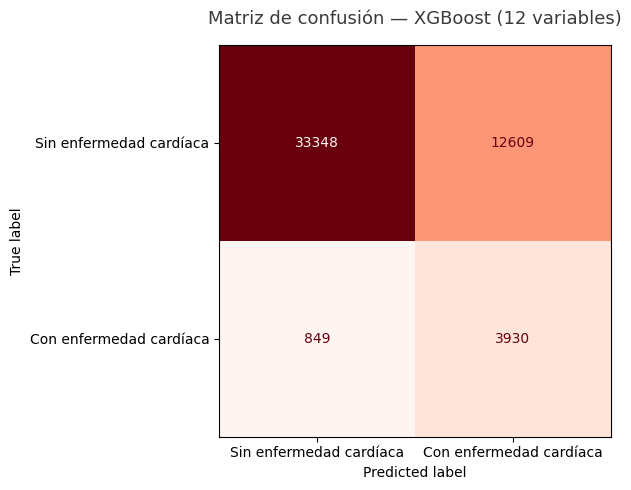


Desglose matriz de confusión:
  Verdaderos negativos (TN): 33,348
  Falsos positivos     (FP): 12,609
  Falsos negativos     (FN): 849
  Verdaderos positivos (TP): 3,930


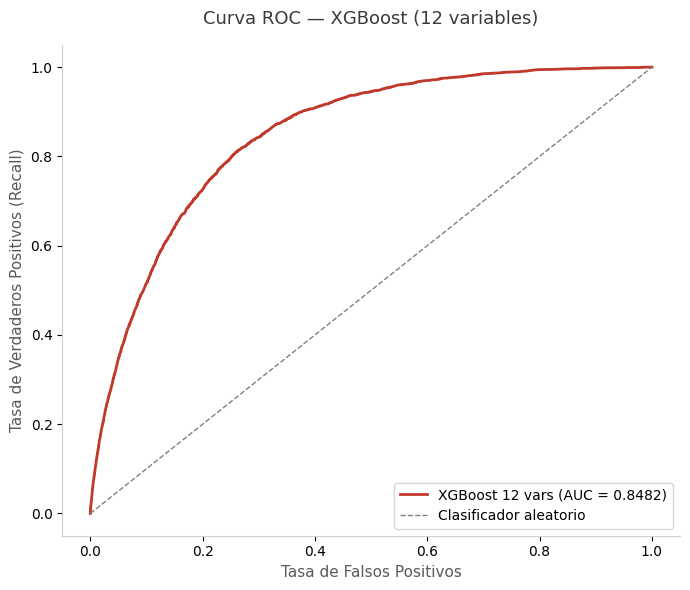

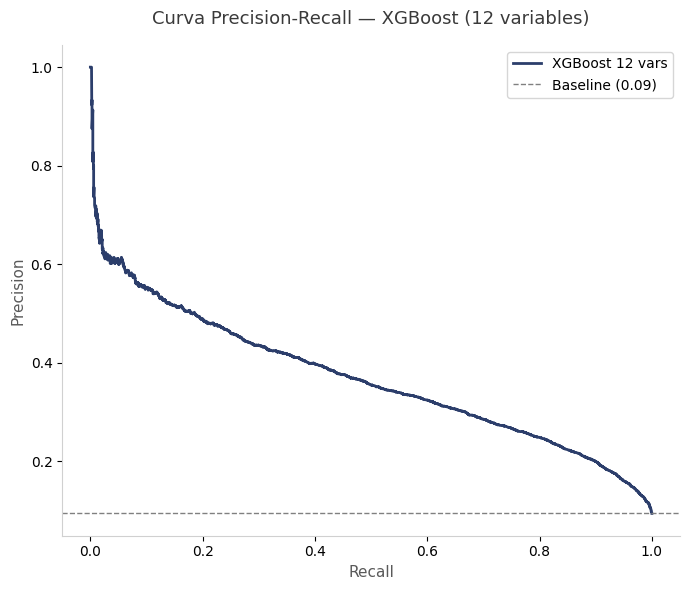

In [71]:
#  7. Análisis final: XGBoost con 12 variables
top_vars = ["HighBP", "GenHlth", "HighChol", "Age", "DiffWalk",
            "Sex", "Stroke", "Smoker", "Diabetes", "PhysHlth",
            "Income", "HvyAlcoholConsump"]

X_final = X[top_vars]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

negativos_f = (y_train_f == 0).sum()
positivos_f  = (y_train_f == 1).sum()
scale_f      = negativos_f / positivos_f

num_final = ["PhysHlth"]
resto_final = [c for c in top_vars if c not in num_final]

preprocessor_final = ColumnTransformer([
    ("num", MinMaxScaler(), num_final),
    ("resto", "passthrough", resto_final)
])

modelo_final = Pipeline([
    ("preprocessor", preprocessor_final),
    ("clf", XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_f,
        eval_metric="logloss",
        verbosity=0,
        learning_rate=0.05,
        max_depth=3,
        n_estimators=100,
        subsample=1.0
    ))
])

modelo_final.fit(X_train_f, y_train_f)
y_pred_f  = modelo_final.predict(X_test_f)
y_proba_f = modelo_final.predict_proba(X_test_f)[:, 1]

#  Métricas
print("MÉTRICAS FINALES — XGBoost 12 variables")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test_f, y_pred_f):.4f}")
print(f"Precision : {precision_score(y_test_f, y_pred_f):.4f}")
print(f"Recall    : {recall_score(y_test_f, y_pred_f):.4f}")
print(f"F1        : {f1_score(y_test_f, y_pred_f):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test_f, y_proba_f):.4f}")

print("\nREPORTE DE CLASIFICACIÓN")
print("=" * 50)
print(classification_report(y_test_f, y_pred_f,
                             target_names=["Sin enfermedad cardíaca",
                                           "Con enfermedad cardíaca"]))

# Matriz de confusión 
fig, ax = plt.subplots(figsize=(6, 5))
cm_f = confusion_matrix(y_test_f, y_pred_f)
disp = ConfusionMatrixDisplay(cm_f,
                               display_labels=["Sin enfermedad cardíaca",
                                               "Con enfermedad cardíaca"])
disp.plot(ax=ax, colorbar=False, cmap="Reds")
ax.set_title("Matriz de confusión — XGBoost (12 variables)",
             fontsize=13, pad=15, color="#3a3a3a")
plt.tight_layout()
plt.show()

tn_f, fp_f, fn_f, tp_f = cm_f.ravel()
print(f"\nDesglose matriz de confusión:")
print(f"  Verdaderos negativos (TN): {tn_f:,}")
print(f"  Falsos positivos     (FP): {fp_f:,}")
print(f"  Falsos negativos     (FN): {fn_f:,}")
print(f"  Verdaderos positivos (TP): {tp_f:,}")

# Curva ROC 
fig, ax = plt.subplots(figsize=(7, 6))
fpr_f, tpr_f, _ = roc_curve(y_test_f, y_proba_f)
auc_f = roc_auc_score(y_test_f, y_proba_f)
ax.plot(fpr_f, tpr_f, color=nude_palette[0], lw=2,
        label=f"XGBoost 12 vars (AUC = {auc_f:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1,
        label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos", fontsize=11, color="#5a5a5a")
ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)", fontsize=11, color="#5a5a5a")
ax.set_title("Curva ROC — XGBoost (12 variables)",
             fontsize=13, pad=15, color="#3a3a3a")
ax.legend(loc="lower right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")
plt.tight_layout()
plt.show()

# Curva Precision-Recall
fig, ax = plt.subplots(figsize=(7, 6))
precision_c, recall_c, _ = precision_recall_curve(y_test_f, y_proba_f)
ax.plot(recall_c, precision_c, color=nude_palette[1], lw=2,
        label="XGBoost 12 vars")
ax.axhline(y=positivos_f/(negativos_f+positivos_f), color="gray",
           linestyle="--", lw=1,
           label=f"Baseline ({positivos_f/(negativos_f+positivos_f):.2f})")
ax.set_xlabel("Recall", fontsize=11, color="#5a5a5a")
ax.set_ylabel("Precision", fontsize=11, color="#5a5a5a")
ax.set_title("Curva Precision-Recall — XGBoost (12 variables)",
             fontsize=13, pad=15, color="#3a3a3a")
ax.legend(loc="upper right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")
plt.tight_layout()
plt.show()


El modelo XGBoost entrenado con las 12 variables de mayor importancia confirma que la reducción de variables no sacrifica capacidad predictiva. Con un Recall de 0.8223, el modelo detectó 3.930 de los 4.779 casos positivos en el conjunto de test, dejando sin identificar apenas 849 casos — 7 menos que el modelo completo con 21 variables. El AUC-ROC de 0.8482 es prácticamente idéntico al del modelo completo (0.8483), y la Precision se mantiene en 0.2376. De los 50.736 registros del conjunto de test, el modelo clasificó correctamente 33.348 personas sanas y 3.930 enfermas, generando 12.609 falsos positivos y 849 falsos negativos. Este resultado es especialmente relevante desde el punto de vista clínico y operativo: un sistema de triaje preventivo basado en solo 12 preguntas de encuesta telefónica logra detectar más de 8 de cada 10 personas con enfermedad cardíaca, sin necesidad de exámenes de laboratorio ni procedimientos costosos. La variable con mayor importancia es HighBP (hipertensión arterial), seguida por GenHlth (autopercepción de salud), HighChol (colesterol alto) y Age (edad), resultado consistente con los hallazgos del análisis exploratorio y con la evidencia clínica existente sobre los principales factores de riesgo cardiovascular.


## ***Referencias bibliográficas***


American Heart Association. (2024). Increasing number of Americans under 55 dying of severe heart attacks, study finds. Journal of the American Heart Association. https://www.ahajournals.org

Centers for Disease Control and Prevention. (2015). Behavioral Risk Factor Surveillance System (BRFSS) 2015 survey data. U.S. Department of Health and Human Services. https://www.cdc.gov/brfss

Teboul, A. (2021). Heart disease health indicators dataset [Dataset]. Kaggle. https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset

Texas Heart Institute. (s.f.). Ataque cardíaco. https://www.texasheart.org/heart-health/heart-information-center/topics/ataque-cardiaco/

National Heart, Lung, and Blood Institute. (s.f.). Heart disease risk factors. U.S. Department of Health and Human Services. https://www.nhlbi.nih.gov

Centers for Disease Control and Prevention. (2024). About BRFSS. U.S. Department of Health and Human Services. https://www.cdc.gov/brfss/about/index.htm

IBM. (s.f.). Exploratory data analysis. IBM Think. https://www.ibm.com/mx-es/think/topics/exploratory-data-analysis

MSD Manuals. (s.f.). Insuficiencia cardíaca. https://www.msdmanuals.com/es/hogar/trastornos-del-corazón

IBM. (s.f.). Exploratory data analysis. IBM Think. https://www.ibm.com/mx-es/think/topics/exploratory-data-analysis

MSD Manuals. (s.f.). Insuficiencia cardíaca. https://www.msdmanuals.com/es/hogar/trastornos-del-corazón

IBM. (s.f.). ¿Qué es el algoritmo de k vecinos más cercanos (KNN)? https://www.ibm.com/mx-es/think/topics/knn

IBM. (s.f.). ¿Qué es un random forest? https://www.ibm.com/mx-es/think/topics/random-forest

IBM. (s.f.). ¿Qué es una máquina de vectores de soporte (SVM)? https://www.ibm.com/es-es/think/topics/support-vector-machine

IBM. (s.f.). ¿Qué es la regresión logística? https://www.ibm.com/es-es/think/topics/logistic-regression

IBM. (s.f.). ¿Qué es XGBoost? https://www.ibm.com/es-es/think/topics/xgboost

Aprende Machine Learning. (s.f.). Clasificación con datos desbalanceados. https://www.aprendemachinelearning.com/clasificacion-con-datos-desbalanceados/

GeeksforGeeks. (2025). Validación cruzada K-fold estratificada. https://www.geeksforgeeks.org/stratified-k-fold-cross-validation/

IBM. (s.f.). ¿Qué es un pipeline de machine learning? https://www.ibm.com/es-es/think/topics/machine-learning-pipeline

DataCamp. (2024). AUC y la curva ROC en aprendizaje automático. https://www.datacamp.com/tutorial/auc

IBM. (2026). Threshold tuning. https://www.ibm.com/docs/en/omegamon-for-storage